In [1]:
# --- Google Colab setup (Option B: run on Colab's cloud GPU) ---
# Clones the repo, makes dpd_ml_project importable, and installs missing deps.
# Runs only on Colab; automatically skipped on a local machine.
try:
    import google.colab  # noqa: F401 
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import sys
    import subprocess

    REPO_URL = "https://github.com/ashaulski/Model_based_ml.git"
    REPO_DIR = "/content/Model_based_ml"

    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL], check=True)

    # Locate the folder that contains the dpd_ml_project package.
    pkg_src = next(
        (p for p in (os.path.join(REPO_DIR, "code", "src"), os.path.join(REPO_DIR, "src"))
         if os.path.isdir(os.path.join(p, "dpd_ml_project"))),
        None,
    )
    if pkg_src is None:
        for root, dirs, _ in os.walk(REPO_DIR):
            if "dpd_ml_project" in dirs:
                pkg_src = root
                break
    if pkg_src is None:
        raise RuntimeError("Could not find the dpd_ml_project package in the cloned repo.")

    if pkg_src not in sys.path:
        sys.path.insert(0, pkg_src)
    # Work from the package parent so relative paths like runs/ and tests/results/ resolve.
    os.chdir(os.path.dirname(pkg_src))

    # Colab ships torch/numpy/scipy/pandas/matplotlib; add the rest.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "mplcursors", "torchinfo"], check=True)

    import dpd_ml_project
    print("dpd_ml_project loaded from:", dpd_ml_project.__file__)
    print("Working directory:", os.getcwd())
else:
    print("Not running on Colab; skipping Colab setup.")


dpd_ml_project loaded from: /content/Model_based_ml/src/dpd_ml_project/__init__.py
Working directory: /content/Model_based_ml


## DPD ML based    



# Imports

In [2]:
import csv
import os
import copy
import pickle
import types
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Report-safe plotting defaults: figures are reduced when embedded in the PDF.
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.titlepad": 12,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,
    "figure.titlesize": 20,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.25,
})
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from scipy.signal import welch, lfilter
random.seed(1234)

def select_device():
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        print(f"Using GPU: {gpu_name}")
        return torch.device("cuda")

    print(
        "CUDA is not available to PyTorch. "
        f"torch={torch.__version__}, cuda_build={torch.version.cuda}. Falling back to CPU."
    )
    return torch.device("cpu")

device = select_device()
try:
    from torchinfo import summary
except ModuleNotFoundError:
    summary = None
from dataclasses import dataclass
from typing import ClassVar
from typing import Literal
import mplcursors
from pathlib import Path
from datetime import datetime
import time
random.seed(1234)
np.random.seed(1234)
_ = torch.manual_seed(1234)






Using GPU: NVIDIA L4


## Configuration parameters


In [3]:
def _build_data_carriers(pilot_carriers: list[int]) -> list[int]:
    """Return OFDM data carriers excluding DC and pilot tones."""
    return [k for k in range(-26, 27) if k != 0 and k not in pilot_carriers]

@dataclass
class Config:
    """Main configuration class for DPD pipeline and analysis."""
    tx_sample_rate: float = 20e6
    dpd_sample_rate: float = tx_sample_rate*8  # 160 MHz
    signal_rms_dbp: float = -15.0  # backoff to ~15 dB below saturation
    FFT_SIZE: ClassVar[int] = 64*8 # 512
    CP_LEN: ClassVar[int] = 64*8//4  # 128 samples
    PILOT_CARRIERS: ClassVar[list[int]] = [-21, -7, 7, 21]
    PILOT_VALUES: ClassVar[list[int]] = [1, 1, 1, -1]
    DATA_CARRIERS: ClassVar[list[int]] = _build_data_carriers(PILOT_CARRIERS)
    Ka: int = 5  # polynmial order
    La: int = 3    # memory depth
    Kb: int = 3  # negative lagging polynomial order
    Lb: int = 3    # negative lagging memory depth
    Mb: int = 1    # negative lagging order
    Kc: int = 3  # positive lagging polynomial order
    Lc: int = 3    # positive lagging memory depth
    Mc: int = 1    # positive lagging order
    Ncoeff: int = Ka*La + Kb*Lb*Mb + Kc*Lc*Mc  # total number of DPD coefficients
    start_data_index = np.max([La, Lb + Mb, Lc - Mc])
    # Every valid row of one 640-sample OFDM symbol (512 samples + 128-sample CP).
    Nvec_cal_mat: int = FFT_SIZE + CP_LEN - int(start_data_index)  # 636 rows after GMP memory warm-up
    iterations_per_sym: int = 200  # number of iterations per OFDM symbol (for tracking)
    RLS_FORGETTING_FACTOR: ClassVar[float] = 0.998  # classical reference value

## signal generator

In [4]:
# try:
#     # from dpd_ml_project import config
# except ModuleNotFoundError:
import types
config = types.SimpleNamespace(Config=Config)



_FFT_SIZE = config.Config.FFT_SIZE
_CP_LEN = config.Config.CP_LEN
_PILOT_CARRIERS = config.Config.PILOT_CARRIERS
_PILOT_VALUES = config.Config.PILOT_VALUES
_DATA_CARRIERS = config.Config.DATA_CARRIERS


def _bpsk_map(bits: np.ndarray) -> np.ndarray:
    bits = np.asarray(bits, dtype=int)
    return np.where(bits == 0, 1 + 0j, -1 + 0j).astype(complex)


def _data_subcarriers() -> list[int]:
    used = [k for k in range(-26, 27) if k != 0]
    return [k for k in used if k not in _PILOT_CARRIERS]


def _carrier_to_index(k: int) -> int:
    return k % _FFT_SIZE



def gen_lsig(
    bypass: bool = False,
    signal_rms_dbp: float = config.Config.signal_rms_dbp,
    repeat_bits_every_call: bool = False,
    bits_seed: int = 0,
) -> np.ndarray:
    """Generate one custom OFDM-like symbol with BPSK data (640 samples with CP).

    If repeat_bits_every_call=True, the same random bit pattern is generated on each
    function call using bits_seed. If False, a fresh random bit pattern is generated.
    """
    _ = bypass  # source module keeps same behavior; flag kept for unified API

    # This is random BPSK test data, not an encoded IEEE 802.11 L-SIG field.
    if repeat_bits_every_call:
        rng = np.random.default_rng(bits_seed)
        random_bits = rng.integers(0, 2, size=48)
    else:
        random_bits = np.random.randint(0, 2, size=48)
    data_symbols = _bpsk_map(random_bits)

    # place data and pilots in the frequency domain
    xf = np.zeros(_FFT_SIZE, dtype=complex)
    for carrier, sym in zip(_DATA_CARRIERS, data_symbols):
        xf[_carrier_to_index(carrier)] = sym
    for carrier, pilot in zip(_PILOT_CARRIERS, _PILOT_VALUES):
        xf[_carrier_to_index(carrier)] = complex(pilot, 0.0)

    # IFFT to time domain
    x_time = np.fft.ifft(np.asarray(xf, dtype=np.complex128), norm="ortho")
    # add cyclic prefix
    cp = x_time[-_CP_LEN:]
    x_time_w_cp = np.concatenate((cp, x_time))

    # --- Normalize input power ---
    x_time_w_cp = x_time_w_cp / (np.sqrt(np.mean(np.abs(x_time_w_cp)**2)) + 1e-12)
    rms_db = 10 * np.log10(np.mean(np.abs(x_time_w_cp)**2) + 1e-12)
    x_time_w_cp = x_time_w_cp * 10**(signal_rms_dbp/20)

    return x_time_w_cp

## AWGN

In [5]:
def apply_awgn(tx_iq: np.ndarray, snr_db: float = 70, bypass: bool = False) -> np.ndarray:
    """
    Additive White Gaussian Noise (AWGN) channel model.
    
    Parameters:
        tx_iq : list of complex (baseband IQ)
        snr_db: signal-to-noise ratio in dB (default 70)
    
    Returns:
        y : complex numpy array (AWGN channel output)
    """

    
    tx_iq = np.asarray(tx_iq, dtype=complex).reshape(-1)

    if bypass:
        return tx_iq.copy()

    signal_rms_db = 10 * np.log10(np.mean(np.abs(tx_iq)**2));

    noise_rms_db = signal_rms_db - snr_db
    noise = 10**(noise_rms_db/20) * (np.random.randn(len(tx_iq)) + 1j * np.random.randn(len(tx_iq)))
    y = tx_iq + noise

    return y

## PA model

In [6]:
def pa_memory_delay_samples(fs=None) -> int:
    """Canonical integer delay used by both NumPy and PyTorch PA models."""
    fs = config.Config.dpd_sample_rate if fs is None else float(fs)
    return int(fs * 1e-9)


def apply_pa_model(x: np.ndarray, fs=None, bypass: bool = False) -> np.ndarray:
    """
    Behavioral PA model approximating Skyworks SKY85355-class FEM.
    
    Parameters:
        tx_iq : list of complex (baseband IQ)
        fs: sampling frequency (Hz), defaults to Config.dpd_sample_rate (160 MHz)
    
    Returns:
        y : complex numpy array (PA output)
    """

    
    fs = config.Config.dpd_sample_rate if fs is None else float(fs)
    x = np.asarray(x, dtype=complex).reshape(-1)

    if bypass:
        return x.copy()

    snr_db = 70
    

    # --- AM-AM: Rapp model (typical WLAN PA compression) ---
    # Smooth saturation, no hard clipping
    p = 3.0             # smoothness factor
    A_sat = 1.0         # saturation amplitude
    r = np.abs(x)

    am_am = r / (1 + (r / A_sat)**(2 * p))**(1 / (2 * p))

    # --- AM-PM: mild phase distortion in the behavioral PA ---
    # few degrees near compression
    phi_max = np.deg2rad(8)   # max ~8 deg
    am_pm = phi_max * (r / A_sat)**2 / (1 + (r / A_sat)**3)

    # Apply AM-AM + AM-PM
    y = am_am * np.exp(1j * (np.angle(x) + am_pm))

    # --- Memory effects (weak, thermal/bias dynamics) ---
    # Simple IIR envelope memory
    env = np.abs(y)
    alpha = 0.98  # strong memory (slow thermal effect)
    env_mem = lfilter([1-alpha], [1, -alpha], env)

    # Gain droop with memory (supply/bias compression)
    k_mem = 0.15
    y = y * (1 - k_mem * env_mem)

    # --- Optional: mild spectral regrowth shaping ---
    # add small cubic memory polynomial term
    beta = 0.08
    delay = pa_memory_delay_samples(fs)  # 0 samples at 160 MHz with the canonical truncation rule

    if delay > 0:
        x_del = np.concatenate([np.zeros(delay, dtype=complex), x[:-delay]])
        y += beta * x_del * np.abs(x_del)**2

    return y


## GMP predistortion

In [7]:
def apply_predistortion(
    tx_iq: np.ndarray,
    coeffs: np.ndarray,
    bypass: bool = False,
    active_basis_indices: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Apply a GMP predistortion model."""
    _Ka = config.Config.Ka
    _La = config.Config.La
    _Kb = config.Config.Kb
    _Lb = config.Config.Lb
    _Mb = config.Config.Mb
    _Kc = config.Config.Kc
    _Lc = config.Config.Lc
    _Mc = config.Config.Mc
    _num_coeffs = config.Config.Ncoeff

    tx_iq = np.asarray(tx_iq, dtype=complex).reshape(-1)
    coeffs = np.asarray(coeffs, dtype=complex).reshape(-1)
    resolved_indices = active_basis_indices
    if resolved_indices is None:
        resolved_indices = globals().get("RLS_ACTIVE_BASIS_INDICES", None)
    if resolved_indices is None:
        resolved_indices = np.arange(_num_coeffs, dtype=int)
    resolved_indices = np.asarray(resolved_indices, dtype=int).reshape(-1)
    resolved_indices = resolved_indices[(resolved_indices >= 0) & (resolved_indices < _num_coeffs)]
    if resolved_indices.size == 0:
        resolved_indices = np.arange(_num_coeffs, dtype=int)
    active_set = set(int(index) for index in resolved_indices.tolist())

    if coeffs.size == resolved_indices.size:
        active_coeffs = coeffs
    elif coeffs.size == _num_coeffs:
        active_coeffs = coeffs[resolved_indices]
    else:
        raise ValueError(
            f"Coefficient length {coeffs.size} is incompatible with active basis size {resolved_indices.size}."
        )

    _num_samples = len(tx_iq)
    y_ordered = np.zeros((_num_samples, _num_coeffs), dtype=complex)

    if bypass:
        return tx_iq.copy(), y_ordered

    for indx_x in range(len(tx_iq)):
        for k in range(_Ka):
            for l in range(_La):
                basis_index = k * _La + l
                if basis_index not in active_set:
                    continue
                x_current = tx_iq[indx_x - l] if indx_x - l >= 0 else 0j
                y_ordered[indx_x][basis_index] = x_current * abs(x_current) ** k

    for indx_x in range(len(tx_iq)):
        for k in range(_Kb):
            for l in range(_Lb):
                for m in range(1, _Mb + 1):
                    basis_index = _Ka * _La + k * (_Lb * _Mb) + l * _Mb + (m - 1)
                    if basis_index not in active_set:
                        continue
                    x_current = tx_iq[indx_x - l] if indx_x - l >= 0 else 0j
                    x_current_cross = tx_iq[indx_x - l - m] if indx_x - l - m >= 0 else 0j
                    y_ordered[indx_x][basis_index] = x_current * abs(x_current_cross) ** (k + 1)

    for indx_x in range(len(tx_iq)):
        for k in range(_Kc):
            for l in range(_Lc):
                for m in range(1, _Mc + 1):
                    basis_index = _Ka * _La + _Kb * _Lb * _Mb + k * (_Lc * _Mc) + l * _Mc + (m - 1)
                    if basis_index not in active_set:
                        continue
                    x_current = tx_iq[indx_x - l] if indx_x - l >= 0 else 0j
                    cross_idx = indx_x - l + m
                    x_current_cross = tx_iq[cross_idx] if 0 <= cross_idx < len(tx_iq) else 0j
                    y_ordered[indx_x][basis_index] = x_current * abs(x_current_cross) ** (k + 1)

    if resolved_indices.size == _num_coeffs and np.array_equal(resolved_indices, np.arange(_num_coeffs)):
        y_out = y_ordered @ active_coeffs
    else:
        y_out = y_ordered[:, resolved_indices] @ active_coeffs

    return y_out, y_ordered


def assert_gmp_basis_full_rank(num_samples=512, seed=20260723):
    """Verify that every configured complex GMP coefficient has an independent basis column."""
    rng = np.random.default_rng(seed)
    signal = rng.standard_normal(num_samples) + 1j * rng.standard_normal(num_samples)
    signal *= 0.3 / np.sqrt(np.mean(np.abs(signal) ** 2))
    _, basis = apply_predistortion(signal, np.ones(config.Config.Ncoeff, dtype=complex), bypass=False)
    active_basis = basis[config.Config.start_data_index:]
    rank = int(np.linalg.matrix_rank(active_basis))
    if rank != config.Config.Ncoeff:
        raise AssertionError(f"GMP basis rank {rank} does not match {config.Config.Ncoeff} configured coefficients.")
    return {"complex_coefficients": int(config.Config.Ncoeff), "basis_rank": rank}


GMP_BASIS_REPORT = assert_gmp_basis_full_rank()
print("GMP basis check passed: %(basis_rank)d/%(complex_coefficients)d independent complex terms" % GMP_BASIS_REPORT)


GMP basis check passed: 33/33 independent complex terms


## traditional calibration

# Kalman

In [8]:
def estimate_coefficients_kal(
    calibrator,  # Calibrator instance
    tx_prd_out: np.ndarray,
    y_ordered: np.ndarray,
) -> np.ndarray:
    """Estimate DPD coefficients using Kalman filter.
    
    Accesses P_kal from the Calibrator instance to maintain state across iterations.

    Args:
        tx_prd_out: Predistorted signal output.
        y_ordered: polynomial's monomials structured from RF output signal 
        calibrator: Calibrator instance (has access to self.P_kal).

    Returns:
        List of complex coefficients.
    """
   
    start_data_index = config.Config.start_data_index
    tx_prd_out = np.asarray(tx_prd_out, dtype=complex).reshape(-1)
    y_ordered = np.asarray(y_ordered, dtype=complex)

    # scalar Kalman filter update
    for n in range(len(tx_prd_out) - start_data_index):

        phi = np.array(y_ordered[start_data_index + n], dtype=complex)        
        phi = phi.reshape(-1, 1)  # column vector
        x = tx_prd_out[start_data_index + n]  # scalar

        # prediction step (no process noise, so prediction is just previous state)
        theta_pred = np.asarray(calibrator.coeffs, dtype=complex).reshape(-1, 1)  # column vector
        P_pred = calibrator.P_kal + calibrator.Q_kal  # predicted covariance is previous covariance plus process noise

        # Kalman gain
        denom = phi.conj().T @ P_pred @ phi + calibrator.R_kal  # scalar
        K = P_pred @ phi / denom  # column vector (Mx1)

        # update step
        innovation = x - (phi.conj().T @ theta_pred).item()  # scalar
        theta_upd = theta_pred + K * innovation  # column vector (Mx1)
        P_upd = (np.eye(len(K)) - K @ phi.conj().T) @ P_pred  # updated covariance

        # store updated state and covariance back in calibrator
        calibrator.coeffs = theta_upd.reshape(-1)
        calibrator.P_kal = P_upd

    return calibrator.coeffs

# LS

In [9]:
try:
    from dpd_ml_project.cal import calibrator
except ModuleNotFoundError:
    calibrator = None

def estimate_coefficients_ls(
    calibrator,  # Calibrator instance        
    rf_out: np.ndarray,
    tx_prd_out: np.ndarray,
    y_ordered: np.ndarray,
) -> "calibrator.Calibrator":
    """Estimate DPD coefficients using batch least-squares method.
    
    Args:
        rf_out: RF output signal.
        tx_prd_out: Predistorted signal output.
        y_ordered: polynomial's monomials structured from RF output signal 


    Returns:
        Updated (or unchanged) Calibrator instance.
    """
    Ka = config.Config.Ka
    La = config.Config.La
    Kb = config.Config.Kb
    Lb = config.Config.Lb
    Mb = config.Config.Mb
    Kc = config.Config.Kc
    Lc = config.Config.Lc
    Mc = config.Config.Mc
    Ncoeff = config.Config.Ncoeff    
    Nvec_cal_mat = config.Config.Nvec_cal_mat

    rf_out = np.asarray(rf_out, dtype=complex).reshape(-1)
    tx_prd_out = np.asarray(tx_prd_out, dtype=complex).reshape(-1)
    y_ordered = np.asarray(y_ordered, dtype=complex)

    Y = np.zeros((Nvec_cal_mat, Ncoeff), dtype=complex)

    start_data_index = np.max([La, Lb + Mb, Lc - Mc])
    available_rows = min(len(rf_out), len(tx_prd_out), y_ordered.shape[0]) - int(start_data_index)
    if available_rows < Nvec_cal_mat:
        raise ValueError(f"LS requires {Nvec_cal_mat} valid rows from one full OFDM symbol; only {available_rows} are available.")

    # non lagging polynomial terms
    vec_index = -1
    for indx_x in range(start_data_index, Nvec_cal_mat+start_data_index):
        vec_index += 1
        coeff_index = -1
        for k in range(Ka):
            for l in range(La):
                coeff_index += 1
                x_current = rf_out[indx_x - l] if indx_x - l >= 0 else 0j
                Y[vec_index, coeff_index] = x_current * abs(x_current) ** (k)

    # negative lagging polynomial terms
    vec_index = -1
    locked_coeff_index = coeff_index
    for indx_x in range(start_data_index, Nvec_cal_mat+start_data_index):
        vec_index += 1
        coeff_index = locked_coeff_index
        for k in range(Kb):
            for l in range(Lb):
                for m in range(1, Mb+1):
                    coeff_index += 1
                    x_current = rf_out[indx_x - l] if indx_x - l >= 0 else 0j
                    x_current_cross = rf_out[indx_x - l - m] if indx_x - l - m >= 0 else 0j
                    Y[vec_index, coeff_index] = x_current * abs(x_current_cross) ** (k + 1)

    # positive lagging polynomial terms
    vec_index = -1
    locked_coeff_index = coeff_index
    for indx_x in range(start_data_index, Nvec_cal_mat+start_data_index):
        vec_index += 1
        coeff_index = locked_coeff_index
        for k in range(Kc):
            for l in range(Lc):
                for m in range(1, Mc+1):
                    coeff_index += 1
                    x_current = rf_out[indx_x - l] if indx_x - l >= 0 else 0j
                    cross_idx = indx_x - l + m
                    x_current_cross = rf_out[cross_idx] if 0 <= cross_idx < len(rf_out) else 0j
                    Y[vec_index, coeff_index] = x_current * abs(x_current_cross) ** (k + 1)

    y_ordered = y_ordered[start_data_index:start_data_index+Nvec_cal_mat]
    X = tx_prd_out[start_data_index:start_data_index+Nvec_cal_mat]
    W = np.linalg.pinv(y_ordered) @ X
    calibrator.coeffs = np.asarray(W, dtype=complex).reshape(-1)
    
    return calibrator

# RLS

In [10]:
try:
    from dpd_ml_project.cal import calibrator
except ModuleNotFoundError:
    calibrator = None


def estimate_coefficients_rls(
    calibrator,  # Calibrator instance
    tx_prd_out: np.ndarray,
    y_ordered: np.ndarray,
) -> "calibrator.Calibrator":
    """Estimate DPD coefficients using recursive least-squares method.
    
    Args:
        calibrator: Calibrator instance.
        tx_prd_out: Predistorted signal output.
        y_ordered: polynomial's monomials structured from RF output signal 
    Returns:
        Updated (or unchanged) Calibrator instance.
    """
    start_data_index = config.Config.start_data_index
    tx_prd_out = np.asarray(tx_prd_out, dtype=complex).reshape(-1)
    y_ordered = np.asarray(y_ordered, dtype=complex)
    active_basis_indices = getattr(calibrator, "active_basis_indices", None)
    if active_basis_indices is None:
        active_basis_indices = globals().get("RLS_ACTIVE_BASIS_INDICES", None)
    if active_basis_indices is None:
        active_basis_indices = np.arange(config.Config.Ncoeff, dtype=int)
    active_basis_indices = np.asarray(active_basis_indices, dtype=int).reshape(-1)
    omega_n = np.asarray(calibrator.coeffs, dtype=complex).reshape(-1, 1)

    # scalar RLS update
    for n in range(len(tx_prd_out) - start_data_index):
    # for n in range(100):
        lambda_pm1 = calibrator.lambda_rls**-1
        u_full = np.asarray(y_ordered[start_data_index + n], dtype=complex).reshape(-1)
        u = np.asarray(u_full[active_basis_indices], dtype=complex).reshape(1, -1)
        gamma_n = 1/(1+ lambda_pm1 * u @ calibrator.P_rls @ u.conj().T)
        g_n = lambda_pm1 * gamma_n * calibrator.P_rls @ u.conj().T
        e_n = tx_prd_out[start_data_index + n] - u @ omega_n
        omega_n = omega_n + g_n * e_n
        calibrator.P_rls = lambda_pm1 * calibrator.P_rls - g_n @ g_n.conj().T / gamma_n
        calibrator.cost_rls = calibrator.lambda_rls * calibrator.cost_rls + gamma_n * np.abs(e_n)**2

    calibrator.coeffs = omega_n.reshape(-1)
    calibrator.active_basis_indices = active_basis_indices
    return calibrator

# calibration update

In [11]:
class Calibrator:
    """Stateful DPD coefficient estimator."""

    def __init__(self, mode: Literal["ls", "rls", "kal"] = "ls", active_basis_indices=None) -> None:
        cfg = config.Config()
        Ka = cfg.Ka
        La = cfg.La
        Kb = cfg.Kb
        Lb = cfg.Lb
        Mb = cfg.Mb
        Kc = cfg.Kc
        Lc = cfg.Lc
        Mc = cfg.Mc
        num_a_coeffs = Ka * La
        num_b_coeffs = Kb * Lb * Mb
        num_c_coeffs = Kc * Lc * Mc
        self.Nvec_cal_mat = config.Config.Nvec_cal_mat      # Number of vectors used for calibration matrix
        self.mode: Literal["ls", "rls", "kal"] = mode
        if active_basis_indices is None:
            active_basis_indices = globals().get("RLS_ACTIVE_BASIS_INDICES", None)
        if active_basis_indices is None:
            active_basis_indices = np.arange(config.Config.Ncoeff, dtype=int)
        self.active_basis_indices = np.asarray(active_basis_indices, dtype=int).reshape(-1)
        # Classical reference initialization: omega[-1] = 0 and P[-1] = I.
        self.coeffs: np.ndarray = np.zeros((len(self.active_basis_indices),), dtype=complex)
        # Kalman filter initialization
        self.P_kal = np.eye(len(self.active_basis_indices))  # Kalman covariance matrix, persists across iterations
        self.R_kal = 1e-6   # Kalman measurement noise covariance
        self.Q_kal = 1e-6 * np.eye(len(self.active_basis_indices))  # Kalman process noise covariance
        # RLS initialization
        self.P_rls = np.eye(len(self.active_basis_indices))  # RLS covariance matrix
        self.lambda_rls = config.Config.RLS_FORGETTING_FACTOR  # 0.998 in the classical reference
        self.cost_rls = 0.0  # RLS cost, persists across iterations
        self.e_rls = 0.0  # RLS error, persists across iterations
        self.g_rls = np.zeros((len(self.active_basis_indices), 1), dtype=complex)  # RLS gain vector, persists across iterations


    def update(
        self,
        tx_prd_out: np.ndarray | None = None,
        tx_pod_out: np.ndarray | None = None,
        rf_out: np.ndarray | None = None,
        y_ordered: np.ndarray | None = None,
        bypass: bool = False
    ) -> "Calibrator":
        """Estimate or update DPD coefficients and store them.

        Args:
            tx_prd_out: Predistorted signal output.
            tx_pod_out: Post-distorted signal output.
            rf_out: RF output signal.
            y_ordered: Structured monomials from RF output.
            bypass: Skip the update and return self.
        """
        if bypass:
            return self

        if self.mode == "ls":
            self = estimate_coefficients_ls(self, rf_out, tx_prd_out, y_ordered)
        elif self.mode == "rls":
            self = estimate_coefficients_rls(self, tx_prd_out, y_ordered)
        elif self.mode == "kal":
            self = estimate_coefficients_kal(self, tx_prd_out, y_ordered)
        return self

## Single Iteration

In [12]:
from dataclasses import dataclass, field

try:
    # from dpd_ml_project.cal.calibrator import Calibrator
    from dpd_ml_project.channel.pa_model import apply_pa_model
    from dpd_ml_project.channel.awgn import apply_awgn
    # from dpd_ml_project.dpd.dpd import apply_predistortion_gmp
    from dpd_ml_project.metrics.evm import compute_evm
    from dpd_ml_project.metrics.mask import check_relative_mask
    from dpd_ml_project.siggen.SigGen import gen_lsig
except ModuleNotFoundError:
    def compute_evm(reference, measured, bypass=False):
        if bypass:
            return 0.0
        reference = np.asarray(reference, dtype=complex).reshape(-1)
        measured = np.asarray(measured, dtype=complex).reshape(-1)
        n = min(reference.size, measured.size)
        if n == 0:
            return float('nan')
        reference = reference[:n]
        measured = measured[:n]
        error = measured - reference
        ref_rms = np.sqrt(np.mean(np.abs(reference) ** 2))
        err_rms = np.sqrt(np.mean(np.abs(error) ** 2))
        if ref_rms <= 1e-12:
            return float('nan')
        return 20.0 * np.log10(max(err_rms / ref_rms, 1e-12))

    def check_relative_mask(measured, bypass=False):
        if bypass:
            return True
        measured = np.asarray(measured, dtype=complex).reshape(-1)
        if measured.size == 0:
            return False
        spectrum = np.fft.fftshift(np.fft.fft(measured))
        power = np.abs(spectrum) ** 2
        center = power.size // 2
        span = max(power.size // 8, 1)
        in_band = power[max(center - span, 0):min(center + span, power.size)]
        oob = np.concatenate([power[:max(center - span, 0)], power[min(center + span, power.size):]])
        if oob.size == 0 or in_band.size == 0:
            return True
        in_band_db = 10.0 * np.log10(np.mean(in_band) + 1e-12)
        oob_db = 10.0 * np.log10(np.mean(oob) + 1e-12)
        return (in_band_db - oob_db) >= 20.0

    gen_lsig = gen_lsig if 'gen_lsig' in globals() else None


@dataclass(slots=True)
class ModuleBypass:
    """Configure which modules are bypassed (pass-through)."""
    siggen: bool = True
    estimator: bool = True
    dprd: bool = True # predistortion
    dpod: bool = True # postdistortion    
    awgn: bool = True
    pa_model: bool = True
    capture: bool = True
    evm: bool = True
    mask: bool = True

@dataclass(slots=True)
class SetUpConfig:
    """Configuration for the entire DPD setup."""
    num_ofdm_sym: int = 10
    iterations_per_sym: int = 200
    initial_coeffs: np.ndarray | None = None
    snr_db: float = 70
    signal_rms_dbp: float = -10

@dataclass(slots=True)
class IterationConfig:
    """Configuration for a single DPD iteration.

    Attributes:
        bypass: Module bypass flags (default: all modules active).
        calibrator: Stateful calibrator instance (holds coefficients and
                    estimation mode across iterations).
    """
    bypass: ModuleBypass = field(default_factory=ModuleBypass)
    calibrator: Calibrator = field(default_factory=Calibrator)
    setup: SetUpConfig = field(default_factory=SetUpConfig)
    temperature_celsius: float = 25.0
    iteration_index: int = 0
    iterations_per_sym: int = 200  # number of iterations per OFDM symbol (for tracking)

@dataclass(slots=True)
class IterationResult:
    """Result of a single DPD iteration."""
    status: str = "not_started"
    evm_db: float = 0.0
    mask_pass: bool = False
    siggen_out: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    prd_in_iq: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    pa_in_iq: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    pa_out_iq: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    dpod_out_iq: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    cal_coeffs: np.ndarray = field(default_factory=lambda: np.array([], dtype=complex))
    calibrator_state: Calibrator = field(default_factory=Calibrator)



# -----------------------------------------------------------------------------
# Main iteration entry point
# -----------------------------------------------------------------------------
def run_iteration(config: IterationConfig | None = None) -> IterationResult:
    """Run one DPD iteration with hardcoded data flow.

    Data flow (fixed):
        siggen -> dpd -> pa_model -> capture ->
        -> calibrator -> metrics

    Args:
        config: Iteration configuration (bypass flags, calibration mode).
                Defaults to all modules active with LS estimation.

    Returns:
        IterationResult with status, EVM, mask pass, and IQ vectors.
    """
    cfg = config or IterationConfig()
    bp = cfg.bypass

    # --- Signal generation ---
    tx_iq = gen_lsig(bypass=bp.siggen, repeat_bits_every_call=False, bits_seed=123, signal_rms_dbp=cfg.setup.signal_rms_dbp)

    # --- Apply predistortion with current coefficients ---
    coeffs = np.asarray(cfg.calibrator.coeffs, dtype=complex).reshape(-1)
    tx_prd_out, _ = apply_predistortion(tx_iq, coeffs, bypass=bp.dprd, active_basis_indices=cfg.calibrator.active_basis_indices)

    # --- AWGN channel ---
    tx_pa_in_iq = apply_awgn(tx_prd_out, snr_db=cfg.setup.snr_db, bypass=bp.awgn)

    # --- PA / channel model ---
    rf_out = apply_pa_model(tx_pa_in_iq, bypass=bp.pa_model)

    # --- Apply post-distortion with current coefficients --- ---
    tx_pod_out, y_ordered = apply_predistortion(rf_out, coeffs, bypass=bp.dpod, active_basis_indices=cfg.calibrator.active_basis_indices)

    # --- Update calibrator (LS or RLS) --- 
    # Calibration uses the configured 160 MHz DPD-domain waveform.
    cfg.calibrator = cfg.calibrator.update(tx_prd_out, tx_pod_out, rf_out, y_ordered, bypass=bp.estimator)
    coeffs = np.asarray(cfg.calibrator.coeffs, dtype=complex).reshape(-1)

    # --- Metrics ---
    n = min(len(tx_iq), len(rf_out))
    evm = compute_evm(reference=tx_iq[:n], measured=rf_out[:n], bypass=bp.evm)
    mask_pass = check_relative_mask(measured=rf_out, bypass=bp.mask)

    status = "ok" if mask_pass else "needs_tuning"


    # # debug
    # ==============================================
    # x_prd, _ = apply_predistortion(tx_iq, cfg.calibrator.coeffs, bypass=False, active_basis_indices=cfg.calibrator.active_basis_indices)
    # Y_prd = apply_pa_model(x_prd, bypass=False)


    # plt.figure(figsize=(10, 5))
    # plt.subplot(1, 2, 1)
    # plt.plot(np.abs(tx_iq), label='Predistorted Input', color='blue')
    # plt.plot(np.abs(Y_prd), label='prd PA Output', color='orange')
    # plt.plot(np.abs(rf_out), label='PA Output', color='red')
    # plt.title('Magnitude Comparison')
    # plt.xlabel('Sample Index')
    # plt.ylabel('Magnitude')
    # plt.legend()
    # plt.subplot(1, 2, 2)
    # plt.plot(np.angle(tx_iq), label='Predistorted Input', color='blue')
    # plt.plot(np.angle(Y_prd), label='pfd PA Output', color='orange')
    # plt.plot(np.angle(rf_out), label='PA Output', color='red')
    # plt.title('Phase Comparison')
    # plt.xlabel('Sample Index')
    # plt.ylabel('Phase (radians)')
    # plt.legend()
    # plt.tight_layout()
    # # plt.show()
    # ==============================================

    return IterationResult(
        status=status,
        evm_db=evm,
        mask_pass=mask_pass,
        siggen_out=tx_iq,
        prd_in_iq=tx_iq,
        pa_in_iq=tx_pa_in_iq,
        pa_out_iq=rf_out,
        dpod_out_iq=tx_pod_out,
        cal_coeffs=coeffs.copy(),
        calibrator_state=cfg.calibrator,
    )


## Run simulation Analysis - review later TBD

In [13]:
@dataclass(slots=True)
class BypassAnalysisResult:
    spectrum_plot: Path
    evm_plot: Path
    evm_db: np.ndarray
    mean_evm_db: float


def run_analysis(
    pipeline_result,
    iteration_config: IterationConfig,
    output_dir: Path,
) -> BypassAnalysisResult:


    # definitions for plotting and analysis
    _FFT_SIZE = config.Config.FFT_SIZE
    _CP_LEN = config.Config.CP_LEN
    _DATA_CARRIERS = config.Config.DATA_CARRIERS
    _data_carriers_index = [_carrier_to_index(k) for k in _DATA_CARRIERS]
    _pa_in_start_idx = _CP_LEN//2  # start data index at half of CP


    # capture time domain signals
    siggen_out_no_cp = np.array(pipeline_result.siggen_out[_CP_LEN:])
    dprd_in_no_cp = np.array(pipeline_result.prd_in_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
    pa_in_no_cp = np.array(pipeline_result.pa_in_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
    pa_out_no_cp = np.array(pipeline_result.pa_out_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
    dpod_in_out_cp = np.array(pipeline_result.dpod_out_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])  # post-distorted signal (PA output)
 

    # visualize the signals in time domain
    fig0, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5), layout="constrained")
    ax1.plot(np.abs(dprd_in_no_cp), label='Predistorted Input', color='blue')
    ax1.plot(np.abs(pa_in_no_cp), label='PA Input', color='orange')
    ax1.plot(np.abs(pa_out_no_cp), label='PA Output', color='red')
    # ax1.plot(np.abs(dpod_in_out_cp), label='Post-Distorted Output', color='red')
    ax1.set_title('Magnitude Comparison')
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('Magnitude')
    ax1.legend()
    ax2.plot(np.angle(dprd_in_no_cp), label='Predistorted Input')
    ax2.plot(np.angle(pa_in_no_cp), label='PA Input')
    ax2.plot(np.angle(pa_out_no_cp), label='PA Output')
    # ax2.plot(np.angle(dpod_in_out_cp), label='Post-Distorted Output')
    ax2.set_title('Phase Comparison')
    ax2.set_xlabel('Sample Index')
    ax2.set_ylabel('Phase (radians)')
    ax2.legend()
    mplcursors.cursor(hover=True)
    td_plot = output_dir / f"time_domain_{iteration_config.iteration_index}.png"
    fig0.savefig(td_plot, dpi=180, bbox_inches="tight", pad_inches=0.25, facecolor="white")
    # plt.show()
    

    # convert to frequency domain
    # and calculate PSD
    siggen_out_fd = np.fft.fft(siggen_out_no_cp, n=_FFT_SIZE, norm="ortho")
    dprd_in_fd = np.fft.fft(dprd_in_no_cp, n=_FFT_SIZE, norm="ortho")
    pa_in_fd = np.fft.fft(pa_in_no_cp, n=_FFT_SIZE, norm="ortho")
    pa_out_fd = np.fft.fft(pa_out_no_cp, n=_FFT_SIZE, norm="ortho")
    evm_fd = np.fft.fft(dprd_in_no_cp-pa_out_no_cp, n=_FFT_SIZE, norm="ortho")  # error vector magnitude in frequency domain
    # Spectrum (dB) over all FFT bins
    eps = 1e-12
    siggen_fd_db = 20.0 * np.log10(np.abs(np.fft.fftshift(siggen_out_fd)) + eps)
    dprd_in_fd_db = 20.0 * np.log10(np.abs(np.fft.fftshift(dprd_in_fd)) + eps)
    pa_in_fd_db = 20.0 * np.log10(np.abs(np.fft.fftshift(pa_in_fd)) + eps)
    pa_out_fd_db = 20.0 * np.log10(np.abs(np.fft.fftshift(pa_out_fd)) + eps)
    evm_fd_db = 20.0 * np.log10(np.abs(evm_fd) + eps)
    bins_index = np.arange(-_FFT_SIZE // 2, _FFT_SIZE // 2)

    fig1, ax1 = plt.subplots(figsize=(12, 6), layout="constrained")
    ax1.plot(bins_index, siggen_fd_db, label="TX")
    ax1.plot(bins_index, dprd_in_fd_db, color="orange", label="TX at PD output")
    ax1.plot(bins_index, pa_out_fd_db, color="green", label="PA output")
    ax1.set_title("Spectrum (FFT bins)")
    ax1.set_xlabel("Subcarrier index (shifted)")
    ax1.set_ylabel("Magnitude (dB)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    spectrum_plot = output_dir / f"spectrum_{iteration_config.iteration_index}.png"
    mplcursors.cursor(hover=True)
    fig1.savefig(spectrum_plot, dpi=180, bbox_inches="tight", pad_inches=0.25, facecolor="white")
    # plt.close(fig1)

    # EVM magnitude per FFT bin (full-bandwidth; subcarrier remapping is not
    # valid for an upsampled signal whose length is not an integer multiple of
    # the original 64-point FFT size)

    fig2, ax2 = plt.subplots(figsize=(12, 6), layout="constrained")    
    ax2.plot(_DATA_CARRIERS, evm_fd_db[_data_carriers_index], color="red", label="EVM at used subcarriers")
    ax2.set_title(f"EVM [dB] at used subcarriers")
    ax2.set_xlabel("Subcarrier index")
    ax2.set_ylabel("EVM (dB)")
    ax2.grid(True, alpha=0.3)   
    evm_plot = output_dir / f"evm_{iteration_config.iteration_index}.png"
    mplcursors.cursor(hover=True)
    fig2.savefig(evm_plot, dpi=180, bbox_inches="tight", pad_inches=0.25, facecolor="white")

    return BypassAnalysisResult(
        spectrum_plot=spectrum_plot,
        evm_plot=evm_plot,
        evm_db=np.asarray(evm_fd_db[_data_carriers_index], dtype=float),
        mean_evm_db=10*np.log10(np.mean(10**(evm_fd_db[_data_carriers_index]/20)) + eps),
    )


# run analysis on entire set of iteration results
def run_analysis_all(
    pipeline_results,
    iteration_configs: IterationConfig,
    output_dir: Path,
) -> BypassAnalysisResult:


    # definitions for plotting and analysis
    _FFT_SIZE = config.Config.FFT_SIZE
    _CP_LEN = config.Config.CP_LEN
    _DATA_CARRIERS = config.Config.DATA_CARRIERS
    _data_carriers_index = [_carrier_to_index(k) for k in _DATA_CARRIERS]
    _pa_in_start_idx = _CP_LEN//2  # start data index at half of CP

    siggen_out_no_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)
    dprd_in_no_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)
    pa_in_no_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)
    pa_out_no_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)
    dpod_in_out_cp = np.empty((len(pipeline_results), _FFT_SIZE), dtype=complex)  # post-distorted signal (PA output)    


    # capture time domain signals
    for i, pipeline_result in enumerate(pipeline_results):
        siggen_out_no_cp[i,:] = np.array(pipeline_result.siggen_out[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
        dprd_in_no_cp[i,:] = np.array(pipeline_result.prd_in_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
        pa_in_no_cp[i,:] = np.array(pipeline_result.pa_in_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
        pa_out_no_cp[i,:] = np.array(pipeline_result.pa_out_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])
        dpod_in_out_cp[i,:] = np.array(pipeline_result.dpod_out_iq[_pa_in_start_idx:_pa_in_start_idx+_FFT_SIZE])  # post-distorted signal (PA output)
 




    # -------------------------------------
    # meters and plot section
    # -------------------------------------

    # plot frequency domain magnitude
    # test_data_rs  = test_data[:,:,_CP_LEN//2:_NFFT+_CP_LEN//2]
    # test_data_fd = np.fft.fftshift(np.fft.fft(test_data_rs,axis=2),axes=2)
    dprd_in_no_cp_fd = np.fft.fftshift(np.fft.fft(dprd_in_no_cp,axis=1),axes=1)
    dprd_in_magdb_fd = 20*np.log10((np.mean(np.abs(dprd_in_no_cp_fd),axis=0)))

    pa_out_no_cp_fd = np.fft.fftshift(np.fft.fft(pa_out_no_cp,axis=1),axes=1)
    pa_out_magdb_fd = 20*np.log10(np.abs(pa_out_no_cp_fd))
    # test_data_magdb_fd = 20*np.log10((np.mean(np.abs(test_data_fd),axis=0)))
    # rf_out_rs = rf_out.reshape(num_ofdm_sym,-1)[:,_CP_LEN//2:_NFFT+_CP_LEN//2]
    # rf_out_fd = np.fft.fftshift(np.fft.fft(rf_out_rs,axis=1),axes=1)
    # rf_out_magdb_fd = 20*np.log10(np.mean(np.abs(rf_out_fd),axis=0))

    plt.figure(figsize=(12, 6), layout="constrained")
    plt.plot(dprd_in_magdb_fd, label='Original signal', color='blue')
    plt.plot(pa_out_magdb_fd[0, :], label='PA Output without pre distortion', color='red')
    plt.plot(pa_out_magdb_fd[-1, :], label='PA Output with pre distortion', color='green')
    plt.title('Magnitude Comparison')
    plt.legend()
    # plt.savefig(RUN_OUTPUT_DIR / "frequency_domain_comparison.png", dpi=160)

    # # calculate inband MSE comparison
    # test_data_ib_fd_no_predistorsion = test_data_fd[:,:,_NFFT//2-32:_NFFT//2+32]
    # mse_ib_no_predistorsion = np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:]-test_data_ib_fd_no_predistorsion[:,1,:])**2,axis=0)
    # evm_ib_db_no_predistorsion = 10*np.log10(mse_ib_no_predistorsion/np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:])**2,axis=0))

    # mse_ib_with_predistorsion = np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:]-rf_out_fd[:,_NFFT//2-32:_NFFT//2+32])**2,axis=0)
    # evm_ib_db_with_predistorsion = 10*np.log10(mse_ib_with_predistorsion/np.mean(np.abs(test_data_ib_fd_no_predistorsion[:,0,:])**2,axis=0))

    # # calculate time domain MSE comparison
    # mse_td_no_predistorsion = np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2]-test_data_rs[:,1,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1))
    # mse_td_with_predistorsion = np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2]-rf_out_rs[:,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1))
    # evm_td_no_predistorsion = 10*np.log10(mse_td_no_predistorsion/np.mean(np.abs(test_data_rs[:,0,_CP_LEN//2:-_CP_LEN//2])**2,axis=(0,1)))
    # evm_td_with_predistorsion = 10*np.log10(mse_td_with_predistorsion/np.mean(np.abs(test_data_rs[:,0,64:-64])**2,axis=(0,1)))

    # print("EVM time domain no DPD: ", evm_td_no_predistorsion)
    # print("EVM time domain with DPD: ", evm_td_with_predistorsion)


    # plt.figure(figsize=(10, 5))
    # plt.plot(evm_ib_db_no_predistorsion, label='EVM Inband no DPD', color='blue')
    # plt.plot(evm_ib_db_with_predistorsion, label='EVM Inband with DPD', color='red')
    # plt.title('Inband MSE Comparison')
    # plt.legend()
    # plt.show()

## Run Eponential Weighted RLS

Saved LS summary to: /content/Model_based_ml/tests/results/test_cal_ls_only/run_summary.txt
Saved RLS summary to: /content/Model_based_ml/tests/results/test_cal_rls_only/run_summary.txt
Saved RLS/CNN scenario framework to: /content/Model_based_ml/runs/2026-08-27_08-50-54/rls_scenario_framework.txt


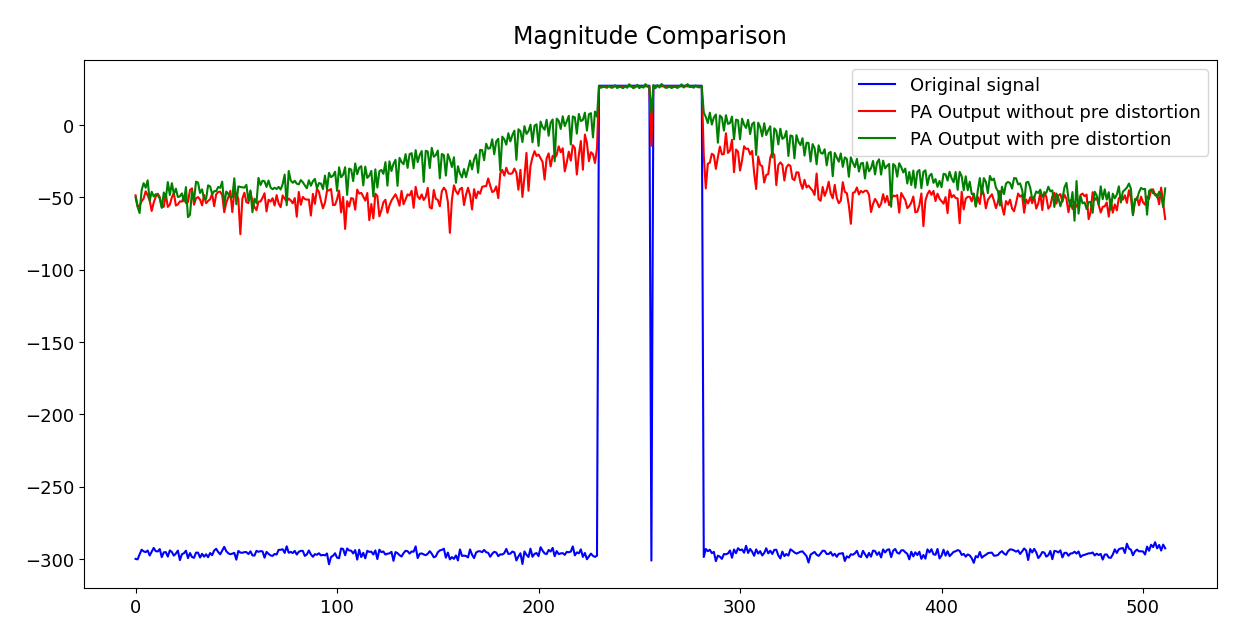

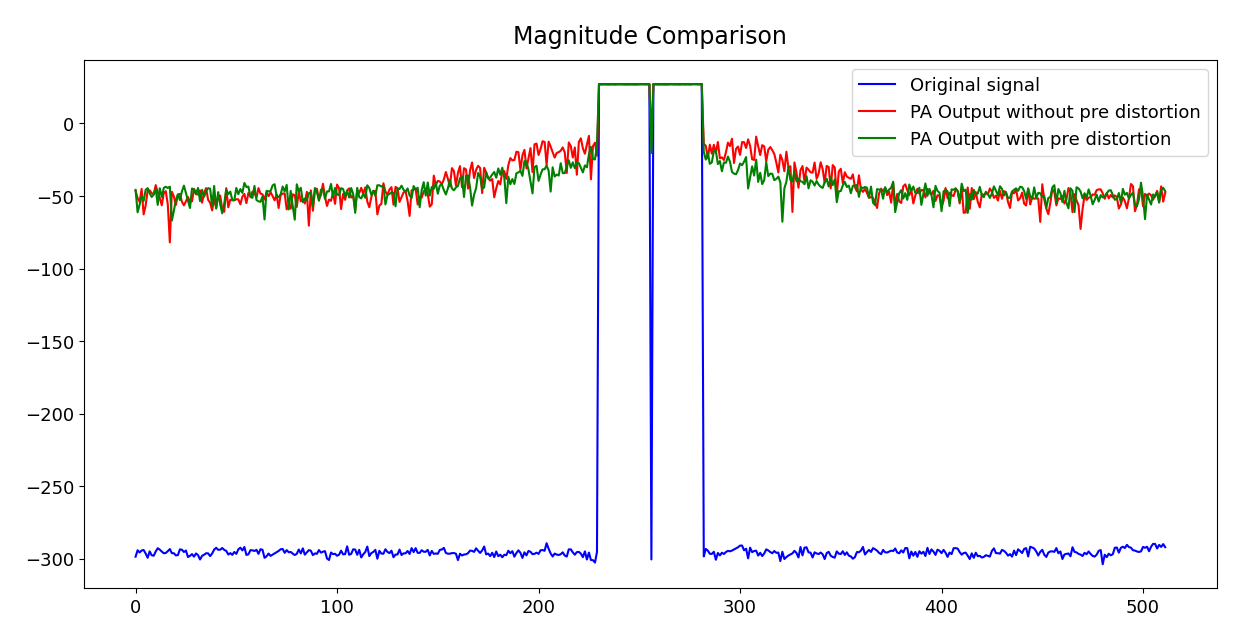

In [14]:
def run_classical_calibration(calibration_mode: str, test_name: str, active_basis_indices=None):
    previous_active_basis_indices = globals().get("RLS_ACTIVE_BASIS_INDICES", None)
    if active_basis_indices is not None:
        globals()["RLS_ACTIVE_BASIS_INDICES"] = np.asarray(active_basis_indices, dtype=int).reshape(-1)

    setup_config = SetUpConfig(
        num_ofdm_sym=10,
        iterations_per_sym=2500,
        initial_coeffs=None,
        snr_db=70,
        signal_rms_dbp=-10,
    )

    itrs_config = [IterationConfig() for _ in range(setup_config.num_ofdm_sym)]
    itrs_results = [IterationResult() for _ in range(setup_config.num_ofdm_sym)]

    for i in range(setup_config.num_ofdm_sym):
        itrs_config[i].setup = setup_config
        itrs_config[i].iteration_index = i
        itrs_config[i].bypass.estimator = False
        itrs_config[i].bypass.siggen = False
        itrs_config[i].bypass.pa_model = False
        itrs_config[i].bypass.awgn = False
        itrs_config[i].bypass.evm = False
        itrs_config[i].calibrator = Calibrator(mode=calibration_mode, active_basis_indices=active_basis_indices)
        itrs_config[i].calibrator.iterations_per_sym = SetUpConfig.iterations_per_sym
        if i == 0:
            itrs_config[i].calibrator.mode = calibration_mode
            itrs_config[i].bypass.dpod = False
        if i >= 1:
            # itrs_config[i].calibrator.mode = "kal"  # switch to Kalman for tracking after initial LS/RLS estimation
            itrs_config[i].calibrator.mode = calibration_mode
            itrs_config[i].bypass.dprd = False
            itrs_config[i].bypass.dpod = False

    for i in range(setup_config.num_ofdm_sym):
        if i >= 1:
            itrs_config[i].calibrator.coeffs = itrs_results[i - 1].cal_coeffs
        itrs_results[i] = run_iteration(itrs_config[i])

    output_dir = Path("tests") / "results" / test_name
    output_dir.mkdir(parents=True, exist_ok=True)
    run_analysis_all(itrs_results, itrs_config, output_dir=output_dir)

    fft_size = getattr(config.Config, "FFT_SIZE", 512)

    def _compute_mean_inband_evm_db_local(reference_fd, measured_fd):
        reference_fd = np.asarray(reference_fd)
        measured_fd = np.asarray(measured_fd)
        mse_ib = np.mean(np.abs(reference_fd - measured_fd) ** 2, axis=1)
        ref_power_ib = np.mean(np.abs(reference_fd) ** 2, axis=1)
        return 10 * np.log10(np.maximum(mse_ib / np.maximum(ref_power_ib, 1e-24), 1e-24))

    def _compute_acpr_db_local(waveform, main_half_bw_bins=32, adj_half_bw_bins=32, adj_offset_bins=96, n_fft=512, return_components=False):
        waveform = np.asarray(waveform)
        if waveform.ndim == 1:
            waveform = waveform.reshape(1, -1)
        elif waveform.ndim > 2:
            waveform = waveform.reshape(-1, waveform.shape[-1])
        if waveform.shape[1] >= n_fft:
            centered = waveform[:, :n_fft]
        else:
            pad_width = n_fft - waveform.shape[1]
            centered = np.pad(waveform, ((0, 0), (0, pad_width)), mode="constant")
        spectrum = np.fft.fftshift(np.fft.fft(centered, n=n_fft, axis=1), axes=1)
        power = np.mean(np.abs(spectrum) ** 2, axis=0)
        center = n_fft // 2
        main_slice = slice(center - main_half_bw_bins, center + main_half_bw_bins)
        upper_adj_slice = slice(center + adj_offset_bins - adj_half_bw_bins, center + adj_offset_bins + adj_half_bw_bins)
        lower_adj_slice = slice(center - adj_offset_bins - adj_half_bw_bins, center - adj_offset_bins + adj_half_bw_bins)
        main_power = np.sum(power[main_slice])
        adj_power = 0.5 * (np.sum(power[upper_adj_slice]) + np.sum(power[lower_adj_slice]))
        rest_mask = np.ones_like(power, dtype=bool)
        rest_mask[main_slice] = False
        rest_mask[upper_adj_slice] = False
        rest_mask[lower_adj_slice] = False
        rest_power = np.sum(power[rest_mask])
        acpr_db = 10 * np.log10(max(adj_power, 1e-24) / max(main_power, 1e-24))
        rest_db = 10 * np.log10(max(rest_power, 1e-24) / max(main_power, 1e-24))
        if return_components:
            return acpr_db, rest_db
        return acpr_db

    compute_mean_inband_evm_db_fn = globals().get("compute_mean_inband_evm_db", _compute_mean_inband_evm_db_local)
    compute_acpr_fn = globals().get("compute_acpr_db", _compute_acpr_db_local)

    evm_values = np.asarray([result.evm_db for result in itrs_results], dtype=float)
    mask_pass_count = sum(bool(result.mask_pass) for result in itrs_results)
    acpr_no_dpd, far_oob_no_dpd = compute_acpr_fn(itrs_results[0].pa_out_iq, n_fft=fft_size, return_components=True) if itrs_results else (float('nan'), float('nan'))
    acpr_with_dpd, far_oob_with_dpd = compute_acpr_fn(itrs_results[-1].pa_out_iq, n_fft=fft_size, return_components=True) if itrs_results else (float('nan'), float('nan'))
    summary_metrics = {
        "method": calibration_mode.upper(),
        "iterations_ran": len(itrs_results),
        "signal_rms_dbp": setup_config.signal_rms_dbp,
        "snr_db": setup_config.snr_db,
        "mean_evm_db": float(np.mean(evm_values)) if evm_values.size else float('nan'),
        "best_evm_db": float(np.min(evm_values)) if evm_values.size else float('nan'),
        "worst_evm_db": float(np.max(evm_values)) if evm_values.size else float('nan'),
        "acpr_no_dpd_db": float(acpr_no_dpd),
        "acpr_with_dpd_db": float(acpr_with_dpd),
        "far_oob_no_dpd_db": float(far_oob_no_dpd),
        "far_oob_with_dpd_db": float(far_oob_with_dpd),
        "mask_pass_count": int(mask_pass_count),
        "final_status": itrs_results[-1].status if itrs_results else "n/a",
    }
    summary_lines = [
        "----- RUN SUMMARY -----",
        f"Method: {calibration_mode.upper()}",
        f"Iterations ran: {len(itrs_results)}",
        f"Signal RMS backoff: {setup_config.signal_rms_dbp:.2f} dB",
        f"SNR: {setup_config.snr_db:.2f} dB",
        f"Mean EVM: {np.mean(evm_values):.2f} dB" if evm_values.size else "Mean EVM: n/a",
        f"Best EVM: {np.min(evm_values):.2f} dB" if evm_values.size else "Best EVM: n/a",
        f"Worst EVM: {np.max(evm_values):.2f} dB" if evm_values.size else "Worst EVM: n/a",
        f"ACPR no DPD (dBc): {acpr_no_dpd:.2f}",
        f"ACPR with DPD (dBc): {acpr_with_dpd:.2f}",
        f"Far Out of Band no DPD (dBc): {far_oob_no_dpd:.2f}",
        f"Far Out of Band with DPD (dBc): {far_oob_with_dpd:.2f}",
        f"Mask pass count: {mask_pass_count}/{len(itrs_results)}",
        f"Final iteration status: {itrs_results[-1].status}" if itrs_results else "Final iteration status: n/a",
    ]
    summary_path = output_dir / "run_summary.txt"
    Path(summary_path).write_text("\n".join(summary_lines) + "\n", encoding="utf-8")
    print(f"Saved {calibration_mode.upper()} summary to:", summary_path.resolve())
    globals()["RLS_ACTIVE_BASIS_INDICES"] = previous_active_basis_indices
    return setup_config, itrs_config, itrs_results, summary_metrics


ls_setup_config, ls_itrs_config, ls_itrs_results, ls_summary_metrics = run_classical_calibration("ls", "test_cal_ls_only")
rls_setup_config, rls_itrs_config, rls_itrs_results, rls_summary_metrics = run_classical_calibration("rls", "test_cal_rls_only")
RLS_BASELINE_COEFFS = np.asarray(rls_itrs_results[-1].cal_coeffs, dtype=complex).reshape(-1) if rls_itrs_results else None


def _summarize_rls_coeffs(coeffs):
    if coeffs is None:
        return {
            "active_complex_coefficients": 0,
            "total_complex_coefficients": 0,
            "active_real_degrees_of_freedom": 0,
            "total_real_degrees_of_freedom": 0,
        }
    coeffs = np.asarray(coeffs, dtype=complex).reshape(-1)
    active_complex_coefficients = int(np.count_nonzero(np.abs(coeffs) > 0))
    total_complex_coefficients = int(coeffs.size)
    return {
        "active_complex_coefficients": active_complex_coefficients,
        "total_complex_coefficients": total_complex_coefficients,
        "active_real_degrees_of_freedom": 2 * active_complex_coefficients,
        "total_real_degrees_of_freedom": 2 * total_complex_coefficients,
    }


RUN_OUTPUT_DIR = Path("runs") / datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
RUN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RLS_SCENARIO_NAME = "current"
RLS_SCENARIO_LIBRARY = {
    "current": {
        "display_name": "Current RLS",
        "description": "full GMP basis from the classical calibration run",
        "keep_ratio": 1.0,
        "reduction_strategy": "full",
        "baseline_coeffs": RLS_BASELINE_COEFFS,
    },
}
if RLS_SCENARIO_NAME not in RLS_SCENARIO_LIBRARY:
    raise ValueError(f"Unknown RLS scenario: {RLS_SCENARIO_NAME}. Expected one of: {', '.join(sorted(RLS_SCENARIO_LIBRARY))}")
RLS_SCENARIO_INFO = dict(RLS_SCENARIO_LIBRARY[RLS_SCENARIO_NAME])
RLS_BASELINE_COEFFS = RLS_SCENARIO_INFO["baseline_coeffs"]
RLS_ACTIVE_COEFF_SUMMARY = _summarize_rls_coeffs(RLS_BASELINE_COEFFS)
scenario_framework_path = RUN_OUTPUT_DIR / "rls_scenario_framework.txt"
scenario_framework_lines = [
    "----- RLS / CNN SCENARIO FRAMEWORK -----",
    f"Active scenario: {RLS_SCENARIO_INFO['display_name']}",
    f"Scenario description: {RLS_SCENARIO_INFO['description']}",
    f"Active coefficients: {RLS_ACTIVE_COEFF_SUMMARY['active_complex_coefficients']}/{RLS_ACTIVE_COEFF_SUMMARY['total_complex_coefficients']} complex terms",
    f"Active real DOF: {RLS_ACTIVE_COEFF_SUMMARY['active_real_degrees_of_freedom']}",
    "CNN architectures: full (32 hidden channels, 2 layers) and reduced companion (16 hidden channels, 1 layer)",
    "",
    "Compared methods: classical RLS, RLS + full/reduced CNN, and LS + full/reduced CNN",
]
scenario_framework_path.write_text("\n".join(scenario_framework_lines) + "\n", encoding="utf-8")
print("Saved RLS/CNN scenario framework to:", scenario_framework_path.resolve())

run_cnn_after_ls = True
if not run_cnn_after_ls:
    # Stop here so the notebook stays on the classical calibration path.
    raise SystemExit("Classical LS calibration completed; skipping CNN training block.")


# ML Based DPD - CNN + FC

In [15]:
MODEL_WEIGHTS_PATH = RUN_OUTPUT_DIR / "cnn_dpd_weights.pt"
BEST_ACPR_MODEL_WEIGHTS_PATH = RUN_OUTPUT_DIR / "cnn_dpd_weights_best_acpr.pt"
TRAINING_CHECKPOINT_PATH = RUN_OUTPUT_DIR / "cnn_dpd_training_checkpoint.pt"

_NFFT = config.Config.FFT_SIZE
_CP_LEN = config.Config.CP_LEN
guard_band_start_bin = 200
guard_band_stop_bin = 223
guard_band_symmetric_start_bin = _NFFT - guard_band_stop_bin
guard_band_symmetric_stop_bin = _NFFT - guard_band_start_bin
GREEN_FFT_STOP_BIN = guard_band_start_bin

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.titlepad": 12,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,
    "figure.titlesize": 20,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.25,
})

# -----------------------------
# DPD CNN model definition
# -----------------------------
class ResidualConvBlock(nn.Module):
    def __init__(self, channels: int, dropout: float = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
        )

    def forward(self, x):
        return torch.relu(self.block(x) + x)


class DpdCnn(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        layers = [
            nn.Conv1d(input_size, hidden_size, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
        ]
        for _ in range(max(0, num_layers - 1)):
            layers.extend([
                nn.Conv1d(hidden_size, hidden_size, kernel_size=3, padding=1),
                nn.BatchNorm1d(hidden_size),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.Conv1d(hidden_size, hidden_size // 2, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden_size // 2, 2, kernel_size=1),
        )
        # Start as an exact RLS pass-through; training only learns a justified correction.
        nn.init.zeros_(self.head[-1].weight)
        nn.init.zeros_(self.head[-1].bias)

    def forward(self, x, h=None):
        x_ch = x.transpose(1, 2)
        y = self.backbone(x_ch)
        delta = self.head(y).transpose(1, 2)
        base_iq = x[..., 2:4] if x.shape[-1] >= 4 else x[..., :2]
        out = base_iq + 0.05 * delta
        return out, None


def build_model_complexity_summary(model, rls_coeffs=None):
    full_rls_complex_coefficients = int(config.Config.Ncoeff)
    if rls_coeffs is None:
        active_rls_complex_coefficients = full_rls_complex_coefficients
    else:
        coeffs = np.asarray(rls_coeffs, dtype=complex).reshape(-1)
        active_rls_complex_coefficients = max(1, int(np.count_nonzero(np.abs(coeffs) > 0)))
    active_rls_real_degrees_of_freedom = 2 * active_rls_complex_coefficients
    cnn_trainable_parameters = int(sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))
    cnn_total_parameters = int(sum(parameter.numel() for parameter in model.parameters()))
    return {
        "rls_complex_coefficients": active_rls_complex_coefficients,
        "rls_total_complex_coefficients": full_rls_complex_coefficients,
        "rls_real_degrees_of_freedom": active_rls_real_degrees_of_freedom,
        "rls_total_real_degrees_of_freedom": 2 * full_rls_complex_coefficients,
        "rls_basis_rank": int(GMP_BASIS_REPORT["basis_rank"]),
        "rls_covariance_complex_values": active_rls_complex_coefficients ** 2,
        "cnn_trainable_real_parameters": cnn_trainable_parameters,
        "cnn_total_real_parameters": cnn_total_parameters,
        "cnn_to_rls_real_dof_ratio": cnn_trainable_parameters / active_rls_real_degrees_of_freedom,
    }


def enhanced_feature_dim(num_history_taps=4):
    return 2 * num_history_taps + 4


def history_taps_from_input_size(input_size):
    if input_size <= 2:
        return 0
    return max(1, (int(input_size) - 4) // 2)


def build_enhanced_feature_tensor(pa_batch, num_history_taps=4):
    """Build a wider memory-aware feature vector for each complex sample."""
    power = pa_batch.real**2 + pa_batch.imag**2
    features = [pa_batch.real, pa_batch.imag]
    for lag in range(1, num_history_taps + 1):
        features.append(torch.cat((torch.zeros_like(pa_batch.real[:lag]), pa_batch.real[:-lag])))
        features.append(torch.cat((torch.zeros_like(pa_batch.imag[:lag]), pa_batch.imag[:-lag])))
    prev_power = torch.cat((torch.zeros_like(power[:1]), power[:-1]))
    features.extend([power, prev_power])
    return torch.stack(tuple(features), dim=-1)


def _resolve_rls_baseline_coeffs():
    coeffs = globals().get("RLS_BASELINE_COEFFS")
    if coeffs is not None:
        return np.asarray(coeffs, dtype=complex).reshape(-1)
    rls_results = globals().get("rls_itrs_results", [])
    if rls_results:
        return np.asarray(rls_results[-1].cal_coeffs, dtype=complex).reshape(-1)
    return None


def _resolve_rls_active_basis_indices(coeffs=None):
    active_basis_indices = globals().get("RLS_ACTIVE_BASIS_INDICES", None)
    if active_basis_indices is None:
        if coeffs is None or np.asarray(coeffs).size == int(config.Config.Ncoeff):
            return None
        raise ValueError("A partial coefficient vector requires matching RLS_ACTIVE_BASIS_INDICES.")
    active_basis_indices = np.asarray(active_basis_indices, dtype=int).reshape(-1)
    if coeffs is not None and np.asarray(coeffs).size != active_basis_indices.size:
        raise ValueError("RLS coefficient count does not match the active basis count.")
    return active_basis_indices


def build_rls_residual_input_torch(pa_out_batch, baseline_coeffs=None):
    if pa_out_batch.ndim == 3 and pa_out_batch.shape[-1] >= 4:
        return pa_out_batch[..., :4]
    baseline_coeffs = _resolve_rls_baseline_coeffs() if baseline_coeffs is None else np.asarray(baseline_coeffs, dtype=complex).reshape(-1)
    if pa_out_batch.ndim == 3:
        pa_out_iq = pa_out_batch.squeeze(0)
    else:
        pa_out_iq = pa_out_batch
    if pa_out_iq.shape[-1] > 2:
        pa_out_iq = pa_out_iq[..., :2]
    if baseline_coeffs is not None:
        pa_out_complex = torch.complex(pa_out_iq[..., 0], pa_out_iq[..., 1]).reshape(-1)
        baseline_np, _ = apply_predistortion(pa_out_complex.detach().cpu().numpy(), baseline_coeffs, bypass=False, active_basis_indices=_resolve_rls_active_basis_indices(baseline_coeffs))
        baseline_complex = torch.as_tensor(np.asarray(baseline_np), dtype=torch.complex64, device=pa_out_iq.device)
        baseline_iq = torch.stack((baseline_complex.real, baseline_complex.imag), dim=-1).view(1, -1, 2)
    else:
        baseline_iq = pa_out_iq.view(1, -1, 2)
    pa_out_iq = pa_out_iq.view(1, -1, 2)
    return torch.cat((pa_out_iq, baseline_iq), dim=-1)


# --- organize OFDM data into batches -----
#   1. Convert arrays of shape (2, N) to two tensors of shape (N,) with complex64 dtype.
#   2. Keep complete OFDM symbols so FFT losses never see truncated waveforms.
#   3. Convert complex samples into real-valued I/Q pairs.
# -----------------------------------------
class OfdmBatcher:
    def __init__(self, ofdms, symbols_per_batch=16, drop_last=False, baseline_coeffs=None, shuffle=False, seed=0, **_unused):
        ofdms = np.asarray(ofdms, dtype=np.complex64)
        if ofdms.ndim != 3 or ofdms.shape[1] < 2:
            raise ValueError("Expected OFDM data with shape [symbols, 2, samples].")
        self.targets = torch.as_tensor(ofdms[:, 0, :], dtype=torch.complex64)
        model_inputs = np.asarray(ofdms[:, 1, :], dtype=np.complex64)
        coeffs = _resolve_rls_baseline_coeffs() if baseline_coeffs is None else np.asarray(baseline_coeffs, dtype=complex).reshape(-1)
        active_basis_indices = _resolve_rls_active_basis_indices(coeffs)
        baseline = np.stack([
            np.asarray(apply_predistortion(symbol, coeffs, bypass=coeffs is None, active_basis_indices=active_basis_indices)[0], dtype=np.complex64)
            for symbol in model_inputs
        ])
        input_iq = np.stack((model_inputs.real, model_inputs.imag), axis=-1)
        baseline_iq = np.stack((baseline.real, baseline.imag), axis=-1)
        self.model_features = torch.as_tensor(np.concatenate((input_iq, baseline_iq), axis=-1), dtype=torch.float32)
        self.symbols_per_batch = max(1, int(symbols_per_batch))
        self.drop_last = bool(drop_last)
        self.shuffle = bool(shuffle)
        self.seed = int(seed)
        self.iteration = 0
        self.num_batches = len(self.targets) // self.symbols_per_batch if self.drop_last else (len(self.targets) + self.symbols_per_batch - 1) // self.symbols_per_batch

    def __iter__(self):
        indices = torch.arange(len(self.targets))
        if self.shuffle:
            generator = torch.Generator().manual_seed(self.seed + self.iteration)
            indices = indices[torch.randperm(len(indices), generator=generator)]
        self.iteration += 1
        for start in range(0, len(indices), self.symbols_per_batch):
            batch_indices = indices[start:start + self.symbols_per_batch]
            if self.drop_last and len(batch_indices) < self.symbols_per_batch:
                continue
            target = self.targets[batch_indices]
            target_iq = torch.stack((target.real, target.imag), dim=-1)
            yield target_iq, self.model_features[batch_indices]


def compute_mse_and_evm(pred, target):
    mse = torch.mean((pred - target) ** 2)
    signal_power = torch.mean(target[..., 0] ** 2 + target[..., 1] ** 2)
    evm_linear = torch.sqrt(mse / torch.clamp(signal_power, min=1e-12))
    evm_db = 20 * torch.log10(torch.clamp(evm_linear, min=1e-12))
    evm_percent = 100 * evm_linear
    return mse, evm_db, evm_percent


def _spectral_power_components_torch(pred, target, n_fft=512):
    pa_out = align_complex_waveform_torch(target, apply_pa_model_torch(pred))
    measured = torch.complex(pa_out[..., 0], pa_out[..., 1])
    fft_start = _CP_LEN // 2
    measured_fd = torch.fft.fftshift(torch.fft.fft(measured[:, fft_start:fft_start + n_fft], n=n_fft, dim=1, norm="ortho"), dim=1)
    power = torch.abs(measured_fd) ** 2
    center = n_fft // 2
    main_slice = slice(center - 32, center + 32)
    upper_slice = slice(center + 96 - 32, center + 96 + 32)
    lower_slice = slice(center - 96 - 32, center - 96 + 32)
    rest_mask = torch.ones(n_fft, dtype=torch.bool, device=pred.device)
    rest_mask[main_slice] = False
    rest_mask[upper_slice] = False
    rest_mask[lower_slice] = False
    main_power = torch.sum(power[:, main_slice], dim=1)
    adjacent_power = 0.5 * (torch.sum(power[:, upper_slice], dim=1) + torch.sum(power[:, lower_slice], dim=1))
    rest_power = torch.sum(power[:, rest_mask], dim=1)
    target_power = torch.mean(torch.sum(target ** 2, dim=-1), dim=1)
    target_backoff_db = 10.0 * torch.log10(torch.clamp(target_power, min=1e-12))
    return main_power, adjacent_power, rest_power, target_backoff_db


def compute_epoch_spectral_comparison(model, loader, baseline_coeffs=None):
    was_training = model.training
    model.eval()
    overall = {"cnn": [0.0, 0.0, 0.0], "rls": [0.0, 0.0, 0.0]}
    grouped = {}
    with torch.no_grad():
        for target_iq, model_input_iq in loader:
            target_iq = target_iq[:, :, :2].to(device)
            cnn_input = build_rls_residual_input_torch(model_input_iq.to(device), baseline_coeffs=baseline_coeffs).to(device)
            cnn_pred = model(cnn_input)[0]
            rls_pred = cnn_input[..., 2:4]
            cnn_components = _spectral_power_components_torch(cnn_pred, target_iq, n_fft=_NFFT)
            rls_components = _spectral_power_components_torch(rls_pred, target_iq, n_fft=_NFFT)
            backoff_keys = torch.round(cnn_components[3]).to(torch.int64)
            for method, components in (("cnn", cnn_components), ("rls", rls_components)):
                values = [float(torch.sum(component).item()) for component in components[:3]]
                overall[method] = [current + value for current, value in zip(overall[method], values)]
            for key in torch.unique(backoff_keys):
                key_int = int(key.item())
                mask = backoff_keys == key
                group = grouped.setdefault(key_int, {"cnn": [0.0, 0.0, 0.0], "rls": [0.0, 0.0, 0.0]})
                for method, components in (("cnn", cnn_components), ("rls", rls_components)):
                    values = [float(torch.sum(component[mask]).item()) for component in components[:3]]
                    group[method] = [current + value for current, value in zip(group[method], values)]
    if was_training:
        model.train()

    def ratios_db(values):
        main_power, adjacent_power, rest_power = values
        return (
            10.0 * np.log10(max(adjacent_power, 1e-24) / max(main_power, 1e-24)),
            10.0 * np.log10(max(rest_power, 1e-24) / max(main_power, 1e-24)),
        )

    cnn_acpr_db, cnn_oob_db = ratios_db(overall["cnn"])
    rls_acpr_db, rls_oob_db = ratios_db(overall["rls"])
    group_metrics = {}
    for key, group in grouped.items():
        group_cnn_acpr, group_cnn_oob = ratios_db(group["cnn"])
        group_rls_acpr, group_rls_oob = ratios_db(group["rls"])
        group_metrics[key] = {
            "cnn_acpr_db": group_cnn_acpr, "rls_acpr_db": group_rls_acpr,
            "cnn_oob_db": group_cnn_oob, "rls_oob_db": group_rls_oob,
            "acpr_delta_db": group_cnn_acpr - group_rls_acpr,
            "oob_delta_db": group_cnn_oob - group_rls_oob,
        }
    worst_acpr_delta_db = max((metrics["acpr_delta_db"] for metrics in group_metrics.values()), default=float("inf"))
    worst_oob_delta_db = max((metrics["oob_delta_db"] for metrics in group_metrics.values()), default=float("inf"))
    return {
        "cnn_acpr_db": cnn_acpr_db, "cnn_oob_db": cnn_oob_db,
        "rls_acpr_db": rls_acpr_db, "rls_oob_db": rls_oob_db,
        "worst_acpr_delta_db": worst_acpr_delta_db, "worst_oob_delta_db": worst_oob_delta_db,
        "group_metrics": group_metrics,
    }


def compute_epoch_spectral_metrics(model, loader, baseline_coeffs=None, baseline_only=False):
    comparison = compute_epoch_spectral_comparison(model, loader, baseline_coeffs=baseline_coeffs)
    prefix = "rls" if baseline_only else "cnn"
    return comparison[f"{prefix}_acpr_db"], comparison[f"{prefix}_oob_db"]


def evm_loss(pred, target):
    mse = torch.mean((pred - target) ** 2)
    signal_power = torch.mean(target[..., 0] ** 2 + target[..., 1] ** 2)
    return torch.sqrt(mse / torch.clamp(signal_power, min=1e-12))


def normalize_iq_to_target_rms(pred, target):
    pred_power = torch.mean(pred[..., 0] ** 2 + pred[..., 1] ** 2, dim=1, keepdim=True)
    target_power = torch.mean(target[..., 0] ** 2 + target[..., 1] ** 2, dim=1, keepdim=True)
    scale = torch.sqrt(torch.clamp(target_power, min=1e-12) / torch.clamp(pred_power, min=1e-12))
    return pred * scale.unsqueeze(-1)


def align_complex_waveform_torch(reference, measured):
    ref_complex = torch.complex(reference[..., 0], reference[..., 1])
    meas_complex = torch.complex(measured[..., 0], measured[..., 1])
    numerator = torch.sum(torch.conj(meas_complex) * ref_complex, dim=1, keepdim=True)
    denominator = torch.sum(torch.abs(meas_complex) ** 2, dim=1, keepdim=True)
    gain = numerator / torch.clamp(denominator, min=1e-12)
    aligned = gain * meas_complex
    return torch.stack((aligned.real, aligned.imag), dim=-1)


def normalize_complex_waveform_numpy(pred, target):
    pred = np.asarray(pred).reshape(-1)
    target = np.asarray(target).reshape(-1)
    pred_power = np.mean(np.abs(pred) ** 2)
    target_power = np.mean(np.abs(target) ** 2)
    scale = np.sqrt(max(target_power, 1e-24) / max(pred_power, 1e-24))
    return pred * scale


def align_complex_waveform_numpy(reference, measured):
    reference = np.asarray(reference).reshape(-1)
    measured = np.asarray(measured).reshape(-1)
    gain = np.sum(np.conj(measured) * reference) / max(np.sum(np.abs(measured) ** 2), 1e-24)
    return gain * measured


def apply_pa_model_torch(pred):
    x = torch.complex(pred[..., 0], pred[..., 1])
    r = torch.abs(x)

    p = 3.0
    a_sat = 1.0
    am_am = r / torch.pow(1 + torch.pow(r / a_sat, 2 * p), 1 / (2 * p))

    phi_max = np.deg2rad(8)
    am_pm = phi_max * torch.pow(r / a_sat, 2) / (1 + torch.pow(r / a_sat, 3))
    y = am_am * torch.exp(1j * (torch.angle(x) + am_pm))

    env = torch.abs(y)
    alpha = 0.98
    env_mem_steps = []
    prev_env_mem = None
    for idx in range(env.shape[1]):
        current_env = env[:, idx]
        if prev_env_mem is None:
            current_env_mem = (1 - alpha) * current_env
        else:
            current_env_mem = (1 - alpha) * current_env + alpha * prev_env_mem
        env_mem_steps.append(current_env_mem)
        prev_env_mem = current_env_mem
    env_mem = torch.stack(env_mem_steps, dim=1)

    k_mem = 0.15
    y = y * (1 - k_mem * env_mem)

    beta = 0.08
    delay = pa_memory_delay_samples()
    if delay > 0:
        x_del = torch.cat((torch.zeros_like(x[:, :delay]), x[:, :-delay]), dim=1)
        y = y + beta * x_del * torch.abs(x_del) ** 2

    return torch.stack((y.real, y.imag), dim=-1)


def assert_pa_model_equivalence(rms_db_levels=(-12.0, -15.0, -18.0, -21.0), symbol_len=None, atol=2e-6, rtol=2e-5):
    """Fail fast if the differentiable PA diverges from the canonical NumPy PA."""
    symbol_len = int(_NFFT + _CP_LEN) if symbol_len is None else int(symbol_len)
    rng = np.random.default_rng(20260723)
    symbols = []
    for rms_db in rms_db_levels:
        symbol = rng.standard_normal(symbol_len) + 1j * rng.standard_normal(symbol_len)
        symbol *= 10.0 ** (rms_db / 20.0) / np.sqrt(np.mean(np.abs(symbol) ** 2))
        symbols.append(symbol)
    symbols = np.asarray(symbols, dtype=np.complex128)
    numpy_output = np.stack([apply_pa_model(symbol, bypass=False) for symbol in symbols])
    torch_input = torch.as_tensor(np.stack((symbols.real, symbols.imag), axis=-1), dtype=torch.float64)
    with torch.no_grad():
        torch_output_iq = apply_pa_model_torch(torch_input)
    torch_output = torch.complex(torch_output_iq[..., 0], torch_output_iq[..., 1]).cpu().numpy()
    error = torch_output - numpy_output
    max_abs_error = float(np.max(np.abs(error)))
    relative_error_db = float(20.0 * np.log10(max(
        np.sqrt(np.mean(np.abs(error) ** 2) / max(np.mean(np.abs(numpy_output) ** 2), 1e-24)), 1e-15
    )))
    if not np.allclose(torch_output, numpy_output, atol=atol, rtol=rtol):
        raise AssertionError(
            f"PyTorch/NumPy PA mismatch: max abs error={max_abs_error:.3e}, relative error={relative_error_db:.2f} dB"
        )
    return {"max_abs_error": max_abs_error, "relative_error_db": relative_error_db}


PA_EQUIVALENCE_REPORT = assert_pa_model_equivalence()
print("PA equivalence passed: max abs error %.3e; relative error %.2f dB" % (
    PA_EQUIVALENCE_REPORT["max_abs_error"], PA_EQUIVALENCE_REPORT["relative_error_db"]
))


def normalize_loss_term(loss_value, min_scale=1e-6):
    return loss_value / torch.clamp(loss_value.detach(), min=min_scale)

def acpr_aux_loss(pred, target, main_half_bw_bins=32, adjacent_span_bins=64, main_weight=1.0, adjacent_weight=0.5, rest_weight=0.1, n_fft=512):
    return weighted_three_region_spectral_loss(
        pred,
        target,
        main_half_bw_bins=main_half_bw_bins,
        adjacent_span_bins=adjacent_span_bins,
        main_weight=main_weight,
        adjacent_weight=adjacent_weight,
        rest_weight=rest_weight,
        n_fft=n_fft,
    )


def _symbol_pair_to_iq_torch(symbol_pair, device=device):
    reference = torch.stack((torch.as_tensor(symbol_pair[0], dtype=torch.float32, device=device), torch.as_tensor(symbol_pair[1], dtype=torch.float32, device=device)), dim=-1)
    return reference.unsqueeze(0)


def predict_predistorted_waveform_for_symbol_torch(model, symbol_pair, batch_size=None, baseline_coeffs=None):
    pa_out_symbol = torch.as_tensor(symbol_pair[1], dtype=torch.complex64, device=device)
    total_samples = pa_out_symbol.shape[0]
    batch_size = total_samples if batch_size is None else batch_size
    if total_samples == 0:
        return torch.empty((1, 0, 2), dtype=torch.float32, device=device)
    num_batches = (total_samples + batch_size - 1) // batch_size
    preds = []
    for batch_idx in range(num_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, total_samples)
        pa_out_batch = pa_out_symbol[start:end]
        pa_out_iq = torch.stack((pa_out_batch.real, pa_out_batch.imag), dim=-1).view(1, pa_out_batch.shape[0], 2)
        cnn_input = build_rls_residual_input_torch(pa_out_iq, baseline_coeffs=baseline_coeffs).to(device)
        pa_in_pred, _ = model(cnn_input)
        preds.append(pa_in_pred.squeeze(0))
    pred_waveform = torch.cat(preds, dim=0) if preds else torch.empty((0, 2), dtype=torch.float32, device=device)
    return pred_waveform.unsqueeze(0)


def symbol_band_shaping_loss(model, symbol_pair, inner_band=(224, 288), batch_size=None, guard_weight=1.0, main_half_bw_bins=32, adj_half_bw_bins=32, adj_offset_bins=96, baseline_coeffs=None):
    reference_iq = _symbol_pair_to_iq_torch(symbol_pair)
    pred_iq = predict_predistorted_waveform_for_symbol_torch(model, symbol_pair, batch_size=batch_size, baseline_coeffs=baseline_coeffs)
    pa_out_pred = apply_pa_model_torch(pred_iq)
    pa_out_aligned = align_complex_waveform_torch(reference_iq, pa_out_pred)
    reference_complex = torch.complex(reference_iq[..., 0], reference_iq[..., 1])
    measured_complex = torch.complex(pa_out_aligned[..., 0], pa_out_aligned[..., 1])
    reference_fd = torch.fft.fftshift(torch.fft.fft(reference_complex, dim=1), dim=1)
    measured_fd = torch.fft.fftshift(torch.fft.fft(measured_complex, dim=1), dim=1)
    inner_start, inner_stop = inner_band
    innerband_loss = torch.mean(torch.abs(measured_fd[:, inner_start:inner_stop] - reference_fd[:, inner_start:inner_stop]) ** 2)
    center = measured_fd.shape[-1] // 2
    main_slice = slice(center - main_half_bw_bins, center + main_half_bw_bins)
    upper_adj_slice = slice(center + adj_offset_bins - adj_half_bw_bins, center + adj_offset_bins + adj_half_bw_bins)
    lower_adj_slice = slice(center - adj_offset_bins - adj_half_bw_bins, center - adj_offset_bins + adj_half_bw_bins)
    main_power = torch.mean(torch.sum(torch.abs(measured_fd[:, main_slice]) ** 2, dim=1))
    upper_adj_power = torch.mean(torch.sum(torch.abs(measured_fd[:, upper_adj_slice]) ** 2, dim=1))
    lower_adj_power = torch.mean(torch.sum(torch.abs(measured_fd[:, lower_adj_slice]) ** 2, dim=1))
    acpr_loss = 0.5 * (upper_adj_power + lower_adj_power) / torch.clamp(main_power, min=1e-12)
    total_loss = innerband_loss + guard_weight * acpr_loss
    return total_loss, innerband_loss, upper_adj_power, lower_adj_power, acpr_loss


def combined_loss(pred, target, evm_weight=1.0):
    pred_normalized = normalize_iq_to_target_rms(pred, target)
    evm_term = evm_loss(pred_normalized, target)
    evm_contrib = evm_weight * normalize_loss_term(evm_term)
    total_loss = evm_contrib
    return total_loss, evm_contrib, evm_term


def _legacy_weighted_three_region_spectral_loss(pred, target, main_half_bw_bins=32, adjacent_span_bins=64, main_weight=1.0, adjacent_weight=0.5, rest_weight=0.1, n_fft=512):
    pred_normalized = normalize_iq_to_target_rms(pred, target)
    pred_normalized = torch.nan_to_num(pred_normalized, nan=0.0, posinf=0.0, neginf=0.0)
    pa_out_pred = apply_pa_model_torch(pred_normalized)
    pa_out_pred = torch.nan_to_num(pa_out_pred, nan=0.0, posinf=0.0, neginf=0.0)
    pa_out_aligned = align_complex_waveform_torch(target, pa_out_pred)
    pa_out_aligned = torch.nan_to_num(pa_out_aligned, nan=0.0, posinf=0.0, neginf=0.0)
    measured_complex = torch.complex(pa_out_aligned[..., 0], pa_out_aligned[..., 1])
    reference_complex = torch.complex(target[..., 0], target[..., 1])
    measured_complex = torch.complex(
        torch.nan_to_num(measured_complex.real, nan=0.0, posinf=0.0, neginf=0.0),
        torch.nan_to_num(measured_complex.imag, nan=0.0, posinf=0.0, neginf=0.0),
    )
    reference_complex = torch.complex(
        torch.nan_to_num(reference_complex.real, nan=0.0, posinf=0.0, neginf=0.0),
        torch.nan_to_num(reference_complex.imag, nan=0.0, posinf=0.0, neginf=0.0),
    )

    def pad_or_trim_complex(x, target_len):
        current_len = x.shape[1]
        if current_len == target_len:
            return x
        if current_len > target_len:
            return x[:, :target_len]
        pad = torch.zeros((x.shape[0], target_len - current_len), dtype=x.dtype, device=x.device)
        return torch.cat((x, pad), dim=1)

    measured_complex = pad_or_trim_complex(measured_complex, n_fft)
    reference_complex = pad_or_trim_complex(reference_complex, n_fft)
    measured_fd = torch.fft.fftshift(torch.fft.fft(measured_complex, n=n_fft, dim=1), dim=1)
    reference_fd = torch.fft.fftshift(torch.fft.fft(reference_complex, n=n_fft, dim=1), dim=1)
    measured_fd = torch.complex(
        torch.nan_to_num(measured_fd.real, nan=0.0, posinf=0.0, neginf=0.0),
        torch.nan_to_num(measured_fd.imag, nan=0.0, posinf=0.0, neginf=0.0),
    )
    reference_fd = torch.complex(
        torch.nan_to_num(reference_fd.real, nan=0.0, posinf=0.0, neginf=0.0),
        torch.nan_to_num(reference_fd.imag, nan=0.0, posinf=0.0, neginf=0.0),
    )
    center = measured_fd.shape[-1] // 2
    main_half_bw_bins = min(main_half_bw_bins, center)
    adjacent_span_bins = min(adjacent_span_bins, center)
    main_slice = slice(center - main_half_bw_bins, center + main_half_bw_bins)
    left_adj_slice = slice(max(0, center - main_half_bw_bins - adjacent_span_bins), center - main_half_bw_bins)
    right_adj_slice = slice(center + main_half_bw_bins, min(measured_fd.shape[-1], center + main_half_bw_bins + adjacent_span_bins))
    rest_mask = torch.ones(measured_fd.shape[-1], dtype=torch.bool, device=measured_fd.device)
    rest_mask[main_slice] = False
    rest_mask[left_adj_slice] = False
    rest_mask[right_adj_slice] = False
    main_power = torch.mean(torch.sum(torch.abs(measured_fd[:, main_slice]) ** 2, dim=1))
    upper_adj_power = torch.mean(torch.sum(torch.abs(measured_fd[:, right_adj_slice]) ** 2, dim=1))
    lower_adj_power = torch.mean(torch.sum(torch.abs(measured_fd[:, left_adj_slice]) ** 2, dim=1))

    def region_mse(measured_region, reference_region):
        if measured_region.numel() == 0 or reference_region.numel() == 0:
            return torch.tensor(0.0, dtype=measured_fd.real.dtype, device=measured_fd.device)
        finite_mask = torch.isfinite(measured_region.real) & torch.isfinite(measured_region.imag) & torch.isfinite(reference_region.real) & torch.isfinite(reference_region.imag)
        if not torch.any(finite_mask):
            return torch.tensor(0.0, dtype=measured_fd.real.dtype, device=measured_fd.device)
        measured_region = measured_region[finite_mask]
        reference_region = reference_region[finite_mask]
        error_power = torch.mean(torch.abs(measured_region - reference_region) ** 2)
        reference_power = torch.mean(torch.abs(reference_region) ** 2)
        return error_power / torch.clamp(reference_power, min=1e-12)

    IB_region_loss = region_mse(measured_fd[:, main_slice], reference_fd[:, main_slice])
    adjacent_region_loss = 0.5 * (
        region_mse(measured_fd[:, left_adj_slice], reference_fd[:, left_adj_slice]) +
        region_mse(measured_fd[:, right_adj_slice], reference_fd[:, right_adj_slice])
    )
    FOOB_region_loss = region_mse(measured_fd[:, rest_mask], reference_fd[:, rest_mask])
    total_loss = (
        main_weight * IB_region_loss +
        adjacent_weight * adjacent_region_loss +
        rest_weight * FOOB_region_loss
    )
    acpr_loss = 0.5 * (upper_adj_power + lower_adj_power) / torch.clamp(main_power, min=1e-12)
    total_loss = torch.nan_to_num(total_loss, nan=0.0, posinf=0.0, neginf=0.0)
    IB_region_loss = torch.nan_to_num(IB_region_loss, nan=0.0, posinf=0.0, neginf=0.0)
    adjacent_region_loss = torch.nan_to_num(adjacent_region_loss, nan=0.0, posinf=0.0, neginf=0.0)
    FOOB_region_loss = torch.nan_to_num(FOOB_region_loss, nan=0.0, posinf=0.0, neginf=0.0)
    acpr_loss = torch.nan_to_num(acpr_loss, nan=0.0, posinf=0.0, neginf=0.0)
    return total_loss, IB_region_loss, upper_adj_power, lower_adj_power, acpr_loss


def acpr_target_penalty_loss_torch(pred, target, target_acpr_db=-40.0, adj_half_bw_bins=32, adj_offset_bins=96, n_fft=512):
    pred_normalized = normalize_iq_to_target_rms(pred, target)
    pred_normalized = torch.nan_to_num(pred_normalized, nan=0.0, posinf=0.0, neginf=0.0)
    pa_out_pred = apply_pa_model_torch(pred_normalized)
    pa_out_pred = torch.nan_to_num(pa_out_pred, nan=0.0, posinf=0.0, neginf=0.0)
    pa_out_aligned = align_complex_waveform_torch(target, pa_out_pred)
    pa_out_aligned = torch.nan_to_num(pa_out_aligned, nan=0.0, posinf=0.0, neginf=0.0)
    measured_complex = torch.complex(pa_out_aligned[..., 0], pa_out_aligned[..., 1])
    measured_complex = torch.complex(
        torch.nan_to_num(measured_complex.real, nan=0.0, posinf=0.0, neginf=0.0),
        torch.nan_to_num(measured_complex.imag, nan=0.0, posinf=0.0, neginf=0.0),
    )

    def pad_or_trim_complex(x, target_len):
        current_len = x.shape[1]
        if current_len == target_len:
            return x
        if current_len > target_len:
            return x[:, :target_len]
        pad = torch.zeros((x.shape[0], target_len - current_len), dtype=x.dtype, device=x.device)
        return torch.cat((x, pad), dim=1)

    measured_complex = pad_or_trim_complex(measured_complex, n_fft)
    measured_fd = torch.fft.fftshift(torch.fft.fft(measured_complex, n=n_fft, dim=1), dim=1)
    measured_fd = torch.complex(
        torch.nan_to_num(measured_fd.real, nan=0.0, posinf=0.0, neginf=0.0),
        torch.nan_to_num(measured_fd.imag, nan=0.0, posinf=0.0, neginf=0.0),
    )
    power = torch.mean(torch.abs(measured_fd) ** 2, dim=0)
    center = power.shape[0] // 2
    adj_half_bw_bins = min(adj_half_bw_bins, center)
    adj_offset_bins = min(adj_offset_bins, center)
    main_slice = slice(center - adj_half_bw_bins, center + adj_half_bw_bins)
    upper_adj_slice = slice(center + adj_offset_bins - adj_half_bw_bins, center + adj_offset_bins + adj_half_bw_bins)
    lower_adj_slice = slice(center - adj_offset_bins - adj_half_bw_bins, center - adj_offset_bins + adj_half_bw_bins)
    main_power = torch.sum(power[main_slice])
    adj_power = 0.5 * (torch.sum(power[upper_adj_slice]) + torch.sum(power[lower_adj_slice]))
    rest_mask = torch.ones_like(power, dtype=torch.bool)
    rest_mask[main_slice] = False
    rest_mask[upper_adj_slice] = False
    rest_mask[lower_adj_slice] = False
    rest_power = torch.sum(power[rest_mask])
    acpr_ratio = adj_power / torch.clamp(main_power, min=1e-12)
    rest_ratio = rest_power / torch.clamp(main_power, min=1e-12)
    acpr_db = 10.0 * torch.log10(torch.clamp(acpr_ratio, min=1e-12))
    rest_db = 10.0 * torch.log10(torch.clamp(rest_ratio, min=1e-12))
    acpr_penalty_db = torch.relu(acpr_db - target_acpr_db)
    acpr_penalty_db = torch.nan_to_num(acpr_penalty_db, nan=0.0, posinf=0.0, neginf=0.0)
    acpr_db = torch.nan_to_num(acpr_db, nan=target_acpr_db, posinf=0.0, neginf=0.0)
    rest_db = torch.nan_to_num(rest_db, nan=0.0, posinf=0.0, neginf=0.0)
    return acpr_penalty_db, acpr_db, rest_db


def update_lagrange_multiplier(current_value, violation_value, step_size=1.5, decay=0.98, min_value=0.0, max_value=50.0):
    updated = current_value * decay + step_size * violation_value
    return float(np.clip(updated, min_value, max_value))


def symbol_spectral_metrics_torch(pred, target, main_half_bw_bins=32, adj_half_bw_bins=32, adj_offset_bins=96, n_fft=512):
    """Measure one complete OFDM symbol with the same masks used at evaluation."""
    pa_out = torch.nan_to_num(apply_pa_model_torch(pred), nan=0.0, posinf=0.0, neginf=0.0)
    pa_out = align_complex_waveform_torch(target, pa_out)
    measured = torch.complex(pa_out[..., 0], pa_out[..., 1])
    reference = torch.complex(target[..., 0], target[..., 1])
    fft_start = _CP_LEN // 2
    fft_stop = fft_start + n_fft
    if measured.shape[1] < fft_stop or reference.shape[1] < fft_stop:
        raise ValueError(f"Spectral loss needs at least {fft_stop} samples; got {measured.shape[1]}.")
    measured_fd = torch.fft.fftshift(torch.fft.fft(measured[:, fft_start:fft_stop], n=n_fft, dim=1, norm="ortho"), dim=1)
    reference_fd = torch.fft.fftshift(torch.fft.fft(reference[:, fft_start:fft_stop], n=n_fft, dim=1, norm="ortho"), dim=1)
    center = n_fft // 2
    main_slice = slice(center - main_half_bw_bins, center + main_half_bw_bins)
    upper_slice = slice(center + adj_offset_bins - adj_half_bw_bins, center + adj_offset_bins + adj_half_bw_bins)
    lower_slice = slice(center - adj_offset_bins - adj_half_bw_bins, center - adj_offset_bins + adj_half_bw_bins)
    rest_mask = torch.ones(n_fft, dtype=torch.bool, device=pred.device)
    rest_mask[main_slice] = False
    rest_mask[upper_slice] = False
    rest_mask[lower_slice] = False
    main_power = torch.mean(torch.sum(torch.abs(measured_fd[:, main_slice]) ** 2, dim=1))
    upper_power = torch.mean(torch.sum(torch.abs(measured_fd[:, upper_slice]) ** 2, dim=1))
    lower_power = torch.mean(torch.sum(torch.abs(measured_fd[:, lower_slice]) ** 2, dim=1))
    rest_power = torch.mean(torch.sum(torch.abs(measured_fd[:, rest_mask]) ** 2, dim=1))
    reference_main_power = torch.mean(torch.sum(torch.abs(reference_fd[:, main_slice]) ** 2, dim=1))
    ib_error_power = torch.mean(torch.sum(torch.abs(measured_fd[:, main_slice] - reference_fd[:, main_slice]) ** 2, dim=1))
    ib_loss = ib_error_power / torch.clamp(reference_main_power, min=1e-12)
    acpr_ratio = 0.5 * (upper_power + lower_power) / torch.clamp(main_power, min=1e-12)
    oob_ratio = rest_power / torch.clamp(main_power, min=1e-12)
    acpr_db = 10.0 * torch.log10(torch.clamp(acpr_ratio, min=1e-12))
    oob_db = 10.0 * torch.log10(torch.clamp(oob_ratio, min=1e-12))
    return ib_loss, acpr_db, oob_db


def symbol_normalized_psd_db_torch(pred, target, main_half_bw_bins=32, n_fft=512):
    pa_out = torch.nan_to_num(apply_pa_model_torch(pred), nan=0.0, posinf=0.0, neginf=0.0)
    pa_out = align_complex_waveform_torch(target, pa_out)
    measured = torch.complex(pa_out[..., 0], pa_out[..., 1])
    fft_start = _CP_LEN // 2
    fft_stop = fft_start + n_fft
    if measured.shape[1] < fft_stop:
        raise ValueError(f"PSD envelope needs at least {fft_stop} samples; got {measured.shape[1]}.")
    measured_fd = torch.fft.fftshift(torch.fft.fft(measured[:, fft_start:fft_stop], n=n_fft, dim=1, norm="ortho"), dim=1)
    power = torch.mean(torch.abs(measured_fd) ** 2, dim=0)
    center = n_fft // 2
    main_slice = slice(center - main_half_bw_bins, center + main_half_bw_bins)
    main_power = torch.sum(power[main_slice])
    return 10.0 * torch.log10(torch.clamp(power / torch.clamp(main_power, min=1e-12), min=1e-12))


def compute_epoch_spectral_envelope_excess(model, loader, baseline_coeffs=None, span_bins=128):
    was_training = model.training
    model.eval()
    max_excess_history = []
    with torch.no_grad():
        for target_iq, model_input_iq in loader:
            target_iq = target_iq[:, :, :2].to(device)
            cnn_input = build_rls_residual_input_torch(model_input_iq.to(device), baseline_coeffs=baseline_coeffs).to(device)
            pred = model(cnn_input)[0]
            baseline_pred = cnn_input[..., 2:4]
            cnn_psd_db = symbol_normalized_psd_db_torch(pred, target_iq, n_fft=_NFFT)
            baseline_psd_db = symbol_normalized_psd_db_torch(baseline_pred, target_iq, n_fft=_NFFT)
            center = _NFFT // 2
            mask = torch.zeros(_NFFT, dtype=torch.bool, device=device)
            mask[center - span_bins:center - 32] = True
            mask[center + 32:center + span_bins] = True
            meaningful = mask & (baseline_psd_db > -100.0)
            selected = meaningful if torch.any(meaningful) else mask
            max_excess_history.append(float(torch.max(cnn_psd_db[selected] - baseline_psd_db[selected]).item()))
    if was_training:
        model.train()
    return max(max_excess_history) if max_excess_history else float("inf")


def weighted_three_region_spectral_loss(pred, target, main_half_bw_bins=32, adjacent_span_bins=64, main_weight=1.0, adjacent_weight=0.5, rest_weight=0.1, n_fft=512):
    # Compatibility wrapper: all callers now use symbol-aware, evaluation-aligned masks.
    ib_loss, acpr_db, oob_db = symbol_spectral_metrics_torch(
        pred, target, main_half_bw_bins=main_half_bw_bins, adj_half_bw_bins=32, adj_offset_bins=96, n_fft=n_fft
    )
    acpr_ratio = torch.pow(10.0, acpr_db / 10.0)
    oob_ratio = torch.pow(10.0, oob_db / 10.0)
    total_loss = main_weight * ib_loss + adjacent_weight * acpr_ratio + rest_weight * oob_ratio
    return total_loss, ib_loss, acpr_db, oob_db, acpr_ratio


def _legacy_adaptive_constrained_training_loss_torch(pred, target, baseline_pred=None, evm_weight=1.0, baseline_penalty_weight=0.5, improvement_margin=1.0, **_unused):
    pred = torch.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    cnn_pa_out = torch.nan_to_num(apply_pa_model_torch(pred), nan=0.0, posinf=0.0, neginf=0.0)
    cnn_pa_aligned = align_complex_waveform_torch(target, cnn_pa_out)
    signal_power = torch.mean(target[..., 0] ** 2 + target[..., 1] ** 2)
    signal_mse = torch.mean((cnn_pa_aligned - target) ** 2)
    signal_evm = torch.sqrt(signal_mse / torch.clamp(signal_power, min=1e-12))
    signal_evm_contrib = evm_weight * signal_evm
    ib_loss, acpr_db, oob_db = symbol_spectral_metrics_torch(pred, target, n_fft=_NFFT)
    acpr_penalty = torch.zeros_like(signal_evm)
    oob_penalty = torch.zeros_like(signal_evm)
    residual_penalty = torch.zeros_like(signal_evm)
    spectral_envelope_penalty = torch.zeros_like(signal_evm)
    baseline_evm = None
    baseline_acpr_db = None
    baseline_oob_db = None
    if baseline_pred is not None:
        baseline_pred = torch.nan_to_num(baseline_pred.detach(), nan=0.0, posinf=0.0, neginf=0.0)
        with torch.no_grad():
            baseline_pa_out = apply_pa_model_torch(baseline_pred)
            baseline_pa_aligned = align_complex_waveform_torch(target, baseline_pa_out)
            baseline_mse = torch.mean((baseline_pa_aligned - target) ** 2)
            baseline_evm = torch.sqrt(baseline_mse / torch.clamp(signal_power, min=1e-12))
            _, baseline_acpr_db, baseline_oob_db = symbol_spectral_metrics_torch(baseline_pred, target, n_fft=_NFFT)
            baseline_psd_db = symbol_normalized_psd_db_torch(baseline_pred, target, n_fft=_NFFT)
        cnn_psd_db = symbol_normalized_psd_db_torch(pred, target, n_fft=_NFFT)
        temperature_db = 1.0
        acpr_excess_db = F.softplus((acpr_db - baseline_acpr_db - improvement_margin) / temperature_db) * temperature_db
        oob_excess_db = F.softplus((oob_db - baseline_oob_db - improvement_margin) / temperature_db) * temperature_db
        acpr_penalty = (acpr_excess_db / 3.0) ** 2
        oob_penalty = (oob_excess_db / 3.0) ** 2
        center = _NFFT // 2
        envelope_mask = torch.zeros(_NFFT, dtype=torch.bool, device=pred.device)
        envelope_mask[center - 128:center - 32] = True
        envelope_mask[center + 32:center + 128] = True
        envelope_weights = torch.ones(_NFFT, dtype=pred.dtype, device=pred.device)
        envelope_weights[center - 64:center - 32] = 4.0
        envelope_weights[center + 32:center + 64] = 4.0
        envelope_excess_db = F.softplus((cnn_psd_db - baseline_psd_db - improvement_margin) / 0.5) * 0.5
        spectral_envelope_penalty = torch.mean(envelope_weights[envelope_mask] * (envelope_excess_db[envelope_mask] / 3.0) ** 2)
        baseline_power = torch.mean(torch.sum(baseline_pred ** 2, dim=-1))
        residual_penalty = torch.mean(torch.sum((pred - baseline_pred) ** 2, dim=-1)) / torch.clamp(baseline_power, min=1e-12)
    spectral_loss = 0.25 * ib_loss + acpr_penalty + 0.5 * oob_penalty
    total_loss = signal_evm_contrib + spectral_loss + spectral_envelope_penalty + 0.10 * residual_penalty
    if baseline_evm is not None:
        evm_regression = torch.relu((signal_evm - baseline_evm) / torch.clamp(baseline_evm, min=1e-6)) ** 2
        total_loss = total_loss + baseline_penalty_weight * evm_regression
    else:
        evm_regression = torch.zeros_like(signal_evm)
    total_loss = torch.nan_to_num(total_loss, nan=0.0, posinf=1e6, neginf=0.0)
    return total_loss, {
        "evm_total_loss": total_loss,
        "evm_contrib": signal_evm_contrib,
        "evm_term": signal_evm,
        "spectral_loss": spectral_loss,
        "baseline_loss": baseline_evm,
        "baseline_improvement_penalty": evm_regression,
        "ib_loss": ib_loss,
        "acpr_db": acpr_db,
        "oob_db": oob_db,
        "baseline_acpr_db": baseline_acpr_db,
        "baseline_oob_db": baseline_oob_db,
        "acpr_loss": acpr_penalty,
        "oob_loss": oob_penalty,
        "residual_penalty": residual_penalty,
        "spectral_envelope_penalty": spectral_envelope_penalty,
    }


def original_signal_spectral_loss_torch(pred, target, main_half_bw_bins=32, adj_half_bw_bins=32, adj_offset_bins=96, n_fft=512):
    """Compare the PA output directly with the original clean signal in every FFT region."""
    pa_out = torch.nan_to_num(apply_pa_model_torch(pred), nan=0.0, posinf=0.0, neginf=0.0)
    pa_out = align_complex_waveform_torch(target, pa_out)
    measured = torch.complex(pa_out[..., 0], pa_out[..., 1])
    reference = torch.complex(target[..., 0], target[..., 1])
    fft_start = _CP_LEN // 2
    fft_stop = fft_start + n_fft
    if measured.shape[1] < fft_stop or reference.shape[1] < fft_stop:
        raise ValueError(f"Original-signal spectral loss needs at least {fft_stop} samples.")
    measured_fd = torch.fft.fftshift(torch.fft.fft(measured[:, fft_start:fft_stop], n=n_fft, dim=1, norm="ortho"), dim=1)
    reference_fd = torch.fft.fftshift(torch.fft.fft(reference[:, fft_start:fft_stop], n=n_fft, dim=1, norm="ortho"), dim=1)
    center = n_fft // 2
    main_slice = slice(center - main_half_bw_bins, center + main_half_bw_bins)
    upper_slice = slice(center + adj_offset_bins - adj_half_bw_bins, center + adj_offset_bins + adj_half_bw_bins)
    lower_slice = slice(center - adj_offset_bins - adj_half_bw_bins, center - adj_offset_bins + adj_half_bw_bins)
    rest_mask = torch.ones(n_fft, dtype=torch.bool, device=pred.device)
    rest_mask[main_slice] = False
    rest_mask[upper_slice] = False
    rest_mask[lower_slice] = False
    reference_main_power = torch.sum(torch.abs(reference_fd[:, main_slice]) ** 2, dim=1)

    def robust_region_nrmse(error_power):
        # Normalize each symbol independently so every backoff has equal influence.
        per_symbol_nrmse = torch.sqrt(error_power / torch.clamp(reference_main_power, min=1e-12))
        tail_count = max(1, (per_symbol_nrmse.numel() + 3) // 4)
        worst_quartile = torch.topk(per_symbol_nrmse, k=tail_count, largest=True).values.mean()
        return per_symbol_nrmse.mean() + 0.5 * worst_quartile

    spectral_error = torch.abs(measured_fd - reference_fd) ** 2
    ib_error_power = torch.sum(spectral_error[:, main_slice], dim=1)
    adjacent_error_power = 0.5 * (
        torch.sum(spectral_error[:, lower_slice], dim=1) +
        torch.sum(spectral_error[:, upper_slice], dim=1)
    )
    oob_error_power = torch.sum(spectral_error[:, rest_mask], dim=1)
    ib_loss = robust_region_nrmse(ib_error_power)
    adjacent_loss = robust_region_nrmse(adjacent_error_power)
    oob_loss = robust_region_nrmse(oob_error_power)
    measured_power = torch.mean(torch.abs(measured_fd) ** 2, dim=0)
    main_power = torch.sum(measured_power[main_slice])
    adjacent_power = 0.5 * (torch.sum(measured_power[lower_slice]) + torch.sum(measured_power[upper_slice]))
    rest_power = torch.sum(measured_power[rest_mask])
    acpr_db = 10.0 * torch.log10(torch.clamp(adjacent_power / torch.clamp(main_power, min=1e-12), min=1e-12))
    oob_db = 10.0 * torch.log10(torch.clamp(rest_power / torch.clamp(main_power, min=1e-12), min=1e-12))
    return ib_loss, adjacent_loss, oob_loss, acpr_db, oob_db


def adaptive_constrained_training_loss_torch(pred, target, evm_weight=1.0):
    pred = torch.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
    cnn_pa_out = torch.nan_to_num(apply_pa_model_torch(pred), nan=0.0, posinf=0.0, neginf=0.0)
    cnn_pa_aligned = align_complex_waveform_torch(target, cnn_pa_out)
    error_power = torch.mean(torch.sum((cnn_pa_aligned - target) ** 2, dim=-1))
    signal_power = torch.mean(torch.sum(target ** 2, dim=-1))
    signal_evm = torch.sqrt(error_power / torch.clamp(signal_power, min=1e-12))
    signal_evm_contrib = evm_weight * signal_evm
    ib_loss, adjacent_loss, oob_loss, acpr_db, oob_db = original_signal_spectral_loss_torch(pred, target, n_fft=_NFFT)
    spectral_loss = 1.0 * ib_loss + 4.0 * adjacent_loss + 2.0 * oob_loss
    total_loss = torch.nan_to_num(signal_evm_contrib + spectral_loss, nan=0.0, posinf=1e6, neginf=0.0)
    zero = torch.zeros_like(signal_evm)
    return total_loss, {
        "evm_total_loss": total_loss,
        "evm_contrib": signal_evm_contrib,
        "evm_term": signal_evm,
        "spectral_loss": spectral_loss,
        "baseline_loss": None,
        "baseline_improvement_penalty": zero,
        "ib_loss": ib_loss,
        "adjacent_loss": adjacent_loss,
        "oob_loss": oob_loss,
        "acpr_db": acpr_db,
        "oob_db": oob_db,
        "acpr_loss": adjacent_loss,
        "residual_penalty": zero,
        "spectral_envelope_penalty": zero,
    }


def get_mse_and_evm(model, data_loader, baseline_coeffs=None):
    total_error_power = 0.0
    total_signal_power = 0.0
    total_inband_values = 0
    was_training = model.training
    model.eval()
    with torch.no_grad():
        for pa_in, pa_out in data_loader:
            pa_out, pa_in = pa_out.to(device), pa_in.to(device)
            cnn_input = build_rls_residual_input_torch(pa_out, baseline_coeffs=baseline_coeffs).to(device)
            pred, _ = model(cnn_input)
            target_iq = pa_in[:, :, :2]
            pred_pa = align_complex_waveform_torch(target_iq, apply_pa_model_torch(pred))
            fft_start = _CP_LEN // 2
            fft_stop = fft_start + _NFFT
            pred_complex = torch.complex(pred_pa[..., 0], pred_pa[..., 1])[:, fft_start:fft_stop]
            target_complex = torch.complex(target_iq[..., 0], target_iq[..., 1])[:, fft_start:fft_stop]
            pred_fd = torch.fft.fftshift(torch.fft.fft(pred_complex, n=_NFFT, dim=1, norm="ortho"), dim=1)
            target_fd = torch.fft.fftshift(torch.fft.fft(target_complex, n=_NFFT, dim=1, norm="ortho"), dim=1)
            main_slice = slice(_NFFT // 2 - 32, _NFFT // 2 + 32)
            error = pred_fd[:, main_slice] - target_fd[:, main_slice]
            total_error_power += float(torch.sum(torch.abs(error) ** 2).item())
            total_signal_power += float(torch.sum(torch.abs(target_fd[:, main_slice]) ** 2).item())
            total_inband_values += int(error.numel())

    if was_training:
        model.train()

    mean_mse = total_error_power / max(1, total_inband_values)
    evm_linear = np.sqrt(total_error_power / max(total_signal_power, 1e-12))
    evm_db = 20 * np.log10(max(evm_linear, 1e-12))
    evm_percent = 100 * evm_linear
    return mean_mse, evm_db, evm_percent


def compute_mean_inband_evm_db(reference_fd, measured_fd):
    mse_ib = np.mean(np.abs(reference_fd - measured_fd) ** 2, axis=1)
    ref_power_ib = np.mean(np.abs(reference_fd) ** 2, axis=1)
    return 10 * np.log10(np.maximum(mse_ib / np.maximum(ref_power_ib, 1e-24), 1e-24))


def compute_aggregate_inband_evm_db(reference_fd, measured_fd):
    error_power = np.sum(np.abs(np.asarray(reference_fd) - np.asarray(measured_fd)) ** 2)
    reference_power = np.sum(np.abs(np.asarray(reference_fd)) ** 2)
    return 10 * np.log10(max(error_power / max(reference_power, 1e-24), 1e-24))


def compute_acpr_db(waveform, main_half_bw_bins=32, adj_half_bw_bins=32, adj_offset_bins=96, n_fft=512, return_components=False):
    waveform = np.asarray(waveform)
    if waveform.ndim == 1:
        waveform = waveform.reshape(1, -1)
    elif waveform.ndim > 2:
        waveform = waveform.reshape(-1, waveform.shape[-1])
    if waveform.shape[1] >= n_fft:
        centered = waveform[:, :n_fft]
    else:
        pad_width = n_fft - waveform.shape[1]
        centered = np.pad(waveform, ((0, 0), (0, pad_width)), mode="constant")
    spectrum = np.fft.fftshift(np.fft.fft(centered, n=n_fft, axis=1), axes=1)
    power = np.mean(np.abs(spectrum) ** 2, axis=0)
    center = n_fft // 2
    main_slice = slice(center - main_half_bw_bins, center + main_half_bw_bins)
    upper_adj_slice = slice(center + adj_offset_bins - adj_half_bw_bins, center + adj_offset_bins + adj_half_bw_bins)
    lower_adj_slice = slice(center - adj_offset_bins - adj_half_bw_bins, center - adj_offset_bins + adj_half_bw_bins)
    main_power = np.sum(power[main_slice])
    adj_power = 0.5 * (np.sum(power[upper_adj_slice]) + np.sum(power[lower_adj_slice]))
    rest_mask = np.ones_like(power, dtype=bool)
    rest_mask[main_slice] = False
    rest_mask[upper_adj_slice] = False
    rest_mask[lower_adj_slice] = False
    rest_power = np.sum(power[rest_mask])
    acpr_db = 10 * np.log10(max(adj_power, 1e-24) / max(main_power, 1e-24))
    rest_db = 10 * np.log10(max(rest_power, 1e-24) / max(main_power, 1e-24))
    if return_components:
        return acpr_db, rest_db
    return acpr_db


def compute_aligned_spectral_metrics_by_backoff(reference_symbols, aligned_outputs_by_method, n_fft=512):
    """Evaluate aggregate and per-backoff spectra with the canonical NumPy masks."""
    reference_symbols = np.asarray(reference_symbols)
    if reference_symbols.ndim == 1:
        reference_symbols = reference_symbols.reshape(1, -1)
    backoff_keys = np.rint(10.0 * np.log10(np.maximum(np.mean(np.abs(reference_symbols) ** 2, axis=1), 1e-24))).astype(int)
    fft_slice = slice(_CP_LEN // 2, _CP_LEN // 2 + n_fft)
    method_outputs = {name: np.asarray(values) for name, values in aligned_outputs_by_method.items()}

    def evaluate(method_output, mask):
        selected = method_output[mask, fft_slice]
        acpr_db, oob_db = compute_acpr_db(selected, n_fft=n_fft, return_components=True)
        return {"acpr_db": float(acpr_db), "oob_db": float(oob_db)}

    all_mask = np.ones(len(reference_symbols), dtype=bool)
    overall = {name: evaluate(values, all_mask) for name, values in method_outputs.items()}
    by_backoff = {}
    for key in sorted(np.unique(backoff_keys)):
        mask = backoff_keys == key
        by_backoff[int(key)] = {
            "count": int(np.sum(mask)),
            **{name: evaluate(values, mask) for name, values in method_outputs.items()},
        }
    return {"overall": overall, "by_backoff": by_backoff}


def compute_epoch_spectral_comparison_numpy(model, loader, baseline_coeffs=None):
    """Canonical non-differentiable validation using the exact final NumPy PA."""
    was_training = model.training
    model.eval()
    references, cnn_predistorted, rls_predistorted = [], [], []
    with torch.no_grad():
        for target_iq, model_input_iq in loader:
            target_iq = target_iq[:, :, :2].to(device)
            cnn_input = build_rls_residual_input_torch(model_input_iq.to(device), baseline_coeffs=baseline_coeffs).to(device)
            cnn_pred = model(cnn_input)[0]
            references.append(torch.complex(target_iq[..., 0], target_iq[..., 1]).cpu().numpy())
            cnn_predistorted.append(torch.complex(cnn_pred[..., 0], cnn_pred[..., 1]).cpu().numpy())
            rls_iq = cnn_input[..., 2:4]
            rls_predistorted.append(torch.complex(rls_iq[..., 0], rls_iq[..., 1]).cpu().numpy())
    if was_training:
        model.train()
    references = np.concatenate(references, axis=0)
    cnn_predistorted = np.concatenate(cnn_predistorted, axis=0)
    rls_predistorted = np.concatenate(rls_predistorted, axis=0)

    def pa_and_align(predistorted):
        return np.stack([
            align_complex_waveform_numpy(reference, apply_pa_model(symbol, bypass=False))
            for reference, symbol in zip(references, predistorted)
        ])

    metrics = compute_aligned_spectral_metrics_by_backoff(
        references, {"cnn": pa_and_align(cnn_predistorted), "rls": pa_and_align(rls_predistorted)}, n_fft=_NFFT
    )
    cnn_overall = metrics["overall"]["cnn"]
    rls_overall = metrics["overall"]["rls"]
    group_metrics = {}
    for key, group in metrics["by_backoff"].items():
        group_metrics[key] = {
            "count": group["count"],
            "cnn_acpr_db": group["cnn"]["acpr_db"], "rls_acpr_db": group["rls"]["acpr_db"],
            "cnn_oob_db": group["cnn"]["oob_db"], "rls_oob_db": group["rls"]["oob_db"],
            "acpr_delta_db": group["cnn"]["acpr_db"] - group["rls"]["acpr_db"],
            "oob_delta_db": group["cnn"]["oob_db"] - group["rls"]["oob_db"],
        }
    return {
        "cnn_acpr_db": cnn_overall["acpr_db"], "cnn_oob_db": cnn_overall["oob_db"],
        "rls_acpr_db": rls_overall["acpr_db"], "rls_oob_db": rls_overall["oob_db"],
        "worst_acpr_delta_db": max((value["acpr_delta_db"] for value in group_metrics.values()), default=float("inf")),
        "worst_oob_delta_db": max((value["oob_delta_db"] for value in group_metrics.values()), default=float("inf")),
        "group_metrics": group_metrics,
    }


def to_builtin_value(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {k: to_builtin_value(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin_value(v) for v in value]
    return value


def save_model_checkpoint(model, path, metadata):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "metadata": to_builtin_value(metadata),
    }
    torch.save(checkpoint, path)


def save_training_checkpoint(model, optimizer, scheduler, path, train_state):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "train_state": to_builtin_value(train_state),
    }
    torch.save(checkpoint, path)


def save_run_summary_text(path, train_summary, acpr_no_predistorsion, acpr_with_predistorsion):
    acpr_db_history = train_summary.get("out_of_band_loss_db_history", [])
    train_loss_history = train_summary.get("train_loss_history", [])
    lines = [
        "----- RUN SUMMARY -----",
        f"Epochs ran: {train_summary.get('epochs_ran', 0)}",
        f"Selected epoch: {train_summary.get('best_epoch', -1)}",
        f"Best validation EVM: {train_summary.get('best_val_evm_db', float('nan')):.2f} dB ({train_summary.get('best_val_evm_percent', float('nan')):.2f}%)",
        f"Test mean inband EVM: {train_summary.get('test_mean_inband_evm_db', float('nan')):.2f} dB",
        f"Final total loss: {train_loss_history[-1]:.6f}" if train_loss_history else "Final total loss: n/a",
        f"Final spectral loss: {acpr_db_history[-1]:.2f} dBc" if acpr_db_history else "Final spectral loss: n/a",
        f"ACPR no DPD (dBc): {acpr_no_predistorsion:.2f}",
        f"ACPR with DPD (dBc): {acpr_with_predistorsion:.2f}",
    ]
    if len(acpr_db_history) >= 10 and acpr_db_history[-1] < acpr_db_history[-10]:
        lines.append("ACPR loss is still improving near the end of training; increasing max_epochs could help.")
    else:
        lines.append("ACPR loss has mostly stabilized near the end of training.")
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


def update_epoch_preview_plot(model, preview_symbol, figure, axis, epoch_idx, n_fft, display_handle=None):
    ax_time, ax_freq = axis
    desired_symbol = np.asarray(preview_symbol[0], dtype=np.complex64)
    pa_out_no_dpd = align_complex_waveform_numpy(desired_symbol, apply_pa_model(desired_symbol, bypass=False))
    rls_coeffs = _resolve_rls_baseline_coeffs()
    rls_predistorted = apply_predistortion(desired_symbol, rls_coeffs, bypass=rls_coeffs is None, active_basis_indices=_resolve_rls_active_basis_indices(rls_coeffs))[0]
    pa_out_rls = align_complex_waveform_numpy(desired_symbol, apply_pa_model(rls_predistorted, bypass=False))
    pa_in_pred = predict_predistorted_waveform_for_symbol(model, preview_symbol, baseline_coeffs=rls_coeffs)
    pa_out_with_dpd = apply_pa_model(pa_in_pred, bypass=False)
    pa_out_with_dpd = align_complex_waveform_numpy(desired_symbol, pa_out_with_dpd)

    ax_time.clear()
    ax_time.plot(np.abs(desired_symbol[64:n_fft // 2]), label="Original signal", color="blue")
    ax_time.plot(np.abs(pa_out_no_dpd[64:n_fft // 2]), label="PA output without DPD", color="red")
    ax_time.plot(np.abs(pa_out_rls[64:n_fft // 2]), label="PA output with classic RLS", color="tab:orange")
    ax_time.plot(np.abs(pa_out_with_dpd[64:n_fft // 2]), label="PA output with CNN DPD", color="green")
    ax_time.set_title("Epoch %d Magnitude Comparison" % epoch_idx, fontsize=17)
    ax_time.set_xlabel("Sample index", fontsize=15)
    ax_time.set_ylabel("Magnitude", fontsize=15)
    ax_time.tick_params(axis="both", labelsize=13)
    ax_time.legend(loc="best", fontsize=13)
    ax_time.grid(True, alpha=0.3)

    freq_slice = slice(_CP_LEN // 2, _CP_LEN // 2 + n_fft)
    ref_fd = np.fft.fftshift(np.fft.fft(desired_symbol[freq_slice]))
    pa_no_dpd_fd = np.fft.fftshift(np.fft.fft(pa_out_no_dpd[freq_slice]))
    pa_rls_fd = np.fft.fftshift(np.fft.fft(pa_out_rls[freq_slice]))
    pa_with_dpd_fd = np.fft.fftshift(np.fft.fft(pa_out_with_dpd[freq_slice]))

    ax_freq.clear()
    ax_freq.plot(20 * np.log10(np.maximum(np.abs(ref_fd), 1e-12)), label="Original signal", color="blue")
    ax_freq.plot(20 * np.log10(np.maximum(np.abs(pa_no_dpd_fd), 1e-12)), label="PA output without DPD", color="red")
    ax_freq.plot(20 * np.log10(np.maximum(np.abs(pa_rls_fd), 1e-12)), label="PA output with classic RLS", color="tab:orange")
    ax_freq.plot(20 * np.log10(np.maximum(np.abs(pa_with_dpd_fd), 1e-12)), label="PA output with CNN DPD", color="green")
    ax_freq.set_title("Epoch %d Frequency Domain Comparison" % epoch_idx, fontsize=17)
    ax_freq.set_xlabel("FFT bin", fontsize=15)
    ax_freq.set_ylabel("Magnitude (dB)", fontsize=15)
    ax_freq.tick_params(axis="both", labelsize=13)
    ax_freq.legend(loc="best", fontsize=13)
    ax_freq.grid(True, alpha=0.3)
    figure.tight_layout(pad=2.0)
    figure.canvas.draw()
    figure.canvas.flush_events()
    if display_handle is not None:
        display_handle.update(figure)
    plt.pause(0.001)


def update_epoch_dashboard_plot(model, preview_symbol, figure, axes, epoch_idx, n_fft, train_mse, valid_mse, train_evm, valid_evm, train_spectral_db_history, valid_spectral_db_history):
    import io
    from IPython.display import Image, clear_output, display
    axes = np.asarray(axes, dtype=object).ravel()
    ax_time, ax_freq, ax_loss, ax_evm = axes[:4]

    desired_symbol = np.asarray(preview_symbol[0], dtype=np.complex64)
    pa_out_no_dpd = align_complex_waveform_numpy(desired_symbol, apply_pa_model(desired_symbol, bypass=False))
    rls_coeffs = _resolve_rls_baseline_coeffs()
    rls_predistorted = apply_predistortion(desired_symbol, rls_coeffs, bypass=rls_coeffs is None, active_basis_indices=_resolve_rls_active_basis_indices(rls_coeffs))[0]
    pa_out_rls = align_complex_waveform_numpy(desired_symbol, apply_pa_model(rls_predistorted, bypass=False))
    pa_in_pred = predict_predistorted_waveform_for_symbol(model, preview_symbol, baseline_coeffs=rls_coeffs)
    pa_out_with_dpd = apply_pa_model(pa_in_pred, bypass=False)
    pa_out_with_dpd = align_complex_waveform_numpy(desired_symbol, pa_out_with_dpd)

    ax_time.clear()
    ax_time.plot(np.abs(desired_symbol[64:n_fft // 2]), label="Original signal", color="blue")
    ax_time.plot(np.abs(pa_out_no_dpd[64:n_fft // 2]), label="PA output without DPD", color="red")
    ax_time.plot(np.abs(pa_out_rls[64:n_fft // 2]), label="PA output with classic RLS", color="tab:orange")
    ax_time.plot(np.abs(pa_out_with_dpd[64:n_fft // 2]), label="PA output with CNN DPD", color="green")
    ax_time.set_title("Epoch %d Magnitude Comparison" % epoch_idx, fontsize=17)
    ax_time.set_xlabel("Sample index", fontsize=15)
    ax_time.set_ylabel("Magnitude", fontsize=15)
    ax_time.tick_params(axis="both", labelsize=13)
    ax_time.legend(loc="best", fontsize=13)
    ax_time.grid(True, alpha=0.3)

    freq_slice = slice(_CP_LEN // 2, _CP_LEN // 2 + n_fft)
    ref_fd = np.fft.fftshift(np.fft.fft(desired_symbol[freq_slice]))
    pa_no_dpd_fd = np.fft.fftshift(np.fft.fft(pa_out_no_dpd[freq_slice]))
    pa_rls_fd = np.fft.fftshift(np.fft.fft(pa_out_rls[freq_slice]))
    pa_with_dpd_fd = np.fft.fftshift(np.fft.fft(pa_out_with_dpd[freq_slice]))

    ax_freq.clear()
    ax_freq.plot(20 * np.log10(np.maximum(np.abs(ref_fd), 1e-12)), label="Original signal", color="blue")
    ax_freq.plot(20 * np.log10(np.maximum(np.abs(pa_no_dpd_fd), 1e-12)), label="PA output without DPD", color="red")
    ax_freq.plot(20 * np.log10(np.maximum(np.abs(pa_rls_fd), 1e-12)), label="PA output with classic RLS", color="tab:orange")
    ax_freq.plot(20 * np.log10(np.maximum(np.abs(pa_with_dpd_fd), 1e-12)), label="PA output with CNN DPD", color="green")
    ax_freq.set_title("Epoch %d Frequency Domain Comparison" % epoch_idx, fontsize=17)
    ax_freq.set_xlabel("FFT bin", fontsize=15)
    ax_freq.set_ylabel("Magnitude (dB)", fontsize=15)
    ax_freq.tick_params(axis="both", labelsize=13)
    ax_freq.legend(loc="best", fontsize=13)
    ax_freq.grid(True, alpha=0.3)

    ax_loss.clear()
    ax_loss.plot(train_spectral_db_history, label="Train ACPR (dBc)", color="black", linewidth=2.4)
    if valid_spectral_db_history:
        ax_loss.plot(valid_spectral_db_history, label="Validation ACPR (dBc)", color="tab:orange", linewidth=2.0)
    ax_loss.set_title("Spectral Loss by Epoch", fontsize=17)
    ax_loss.set_xlabel("Epoch", fontsize=15)
    ax_loss.set_ylabel("ACPR (dBc)", fontsize=15)
    ax_loss.tick_params(axis="both", labelsize=13)
    ax_loss.grid(True, alpha=0.3)
    ax_loss.legend(loc="best", fontsize=13)
    if train_spectral_db_history:
        ax_loss.text(
            0.02,
            0.98,
            f"Final train ACPR: {train_spectral_db_history[-1]:.4g} dBc",
            transform=ax_loss.transAxes,
            va="top",
            ha="left",
            fontsize=13,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.82, edgecolor="0.4"),
        )

    ax_evm.clear()
    ax_evm.plot(train_evm, label="Train EVM (dB)", color="blue")
    ax_evm.plot(valid_evm, label="Validation EVM (dB)", color="red")
    ax_evm.set_title("Training EVM", fontsize=17)
    ax_evm.set_xlabel("Epoch", fontsize=15)
    ax_evm.set_ylabel("EVM (dB)", fontsize=15)
    ax_evm.tick_params(axis="both", labelsize=13)
    ax_evm.grid(True, alpha=0.3)
    ax_evm.legend(loc="best", fontsize=13)

    figure.tight_layout(pad=2.0)
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
    buffer.seek(0)
    clear_output(wait=True)
    display(Image(data=buffer.getvalue()))
    plt.pause(0.001)


def display_figure_png(figure):
    import io
    from IPython.display import Image, display
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))


def predict_predistorted_waveform_for_symbol(model, symbol_pair, baseline_coeffs=None):
    pa_out_symbol = torch.as_tensor(symbol_pair[1], dtype=torch.complex64)
    batch_size = int(pa_out_symbol.shape[0])
    total_samples = pa_out_symbol.shape[0]
    if total_samples == 0:
        return np.array([], dtype=np.complex64)
    num_batches = (total_samples + batch_size - 1) // batch_size
    preds = []
    was_training = model.training
    model.eval()
    with torch.no_grad():
        for batch_idx in range(num_batches):
            start = batch_idx * batch_size
            end = min(start + batch_size, total_samples)
            pa_out_batch = pa_out_symbol[start:end]
            pa_out_iq = torch.stack((pa_out_batch.real, pa_out_batch.imag), dim=-1).view(1, pa_out_batch.shape[0], 2)
            cnn_input = build_rls_residual_input_torch(pa_out_iq, baseline_coeffs=baseline_coeffs).to(device)
            pa_in_pred, _ = model(cnn_input)
            pred_complex = torch.complex(pa_in_pred[..., 0], pa_in_pred[..., 1]).reshape(-1)
            preds.append(pred_complex.cpu().numpy())

    if was_training:
        model.train()

    return np.concatenate(preds) if preds else np.array([], dtype=np.complex64)


def train(model, optimizer, scheduler=None, num_epochs=50, min_epochs=10, target_val_evm_db=-45.0, patience=8, checkpoint_path=None, preview_symbol=None, target_ib_region_loss=2e-5, target_aclr_db=-50.0, target_oob_db=-60.0, baseline_coeffs=None):
    train_mse, valid_mse = [], []
    train_loss_history = []
    train_spectral_db_history = []
    valid_spectral_db_history = []
    train_oob_db_history = []
    valid_oob_db_history = []
    valid_spectral_envelope_excess_history = []
    valid_worst_backoff_acpr_delta_history = []
    valid_worst_backoff_oob_delta_history = []
    valid_backoff_spectral_history = []
    evm_term_history = []
    train_evm, valid_evm = [], []
    train_evm_percent, valid_evm_percent = [], []
    best_epoch = -1
    best_val_evm_db = float("inf")
    best_val_evm_percent = float("inf")
    best_state_dict = None
    best_spectral_score = 0.0
    best_observed_spectral_score = float("inf")
    epochs_without_improvement = 0

    baseline_coeffs = _resolve_rls_baseline_coeffs() if baseline_coeffs is None else baseline_coeffs
    model = model.to(device)
    spectral_tolerance_db = 1.0
    spectral_improvement_margin_db = 0.1
    spectral_plateau_min_delta_db = 0.01
    baseline_valid_comparison = compute_epoch_spectral_comparison_numpy(model, valid_loader, baseline_coeffs=baseline_coeffs)
    baseline_valid_acpr_db = baseline_valid_comparison["rls_acpr_db"]
    baseline_valid_oob_db = baseline_valid_comparison["rls_oob_db"]
    _, best_val_evm_db, best_val_evm_percent = get_mse_and_evm(model, valid_loader, baseline_coeffs=baseline_coeffs)
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict())
    print("Training target: max %d epochs" % num_epochs)
    print("Validation EVM is tracked for logging and spectral-score tie-breaking.")
    print("EVM loss weight: %0.4f" % evm_weight)
    print("Training uses full-symbol direct DPD loss against the clean waveform.")
    print("Canonical NumPy RLS validation baseline: ACPR %0.2f dBc; far OOB %0.2f dBc" % (baseline_valid_acpr_db, baseline_valid_oob_db))

    def _loss_value_or_raise(name, value, epoch_idx, batch_idx):
        value_float = float(value.detach().item()) if torch.is_tensor(value) else float(value)
        if not np.isfinite(value_float):
            raise FloatingPointError(
                f"Non-finite {name} detected at epoch {epoch_idx + 1}, batch {batch_idx + 1}: {value_float}"
            )
        return value_float

    for epoch in range(num_epochs):
        total_loss_epoch = 0.0
        evm_term_epoch = 0.0
        batch_count = 0

        for batch_idx, (pa_in, pa_out) in enumerate(train_loader):
            pa_out, pa_in = pa_out.to(device), pa_in.to(device)
            optimizer.zero_grad()
            cnn_input = build_rls_residual_input_torch(pa_out, baseline_coeffs=baseline_coeffs).to(device)
            pred, _ = model(cnn_input)
            total_loss, loss_info = adaptive_constrained_training_loss_torch(
                pred,
                pa_in[:, :, :2],
                evm_weight=evm_weight,
            )
            _loss_value_or_raise("total_loss", total_loss, epoch, batch_idx)
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss_epoch += total_loss.item()
            evm_term_epoch += loss_info["evm_contrib"].item()
            batch_count += 1

        train_mse_epoch, train_evm_epoch, train_evm_percent_epoch = get_mse_and_evm(model, train_loader, baseline_coeffs=baseline_coeffs)
        valid_mse_epoch, valid_evm_epoch, valid_evm_percent_epoch = get_mse_and_evm(model, valid_loader, baseline_coeffs=baseline_coeffs)
        train_spectral_db_epoch, train_oob_db_epoch = compute_epoch_spectral_metrics(model, train_loader, baseline_coeffs=baseline_coeffs)
        valid_spectral_comparison = compute_epoch_spectral_comparison_numpy(model, valid_loader, baseline_coeffs=baseline_coeffs)
        valid_spectral_db_epoch = valid_spectral_comparison["cnn_acpr_db"]
        valid_oob_db_epoch = valid_spectral_comparison["cnn_oob_db"]
        valid_worst_backoff_acpr_delta = valid_spectral_comparison["worst_acpr_delta_db"]
        valid_worst_backoff_oob_delta = valid_spectral_comparison["worst_oob_delta_db"]
        valid_envelope_excess_db_epoch = compute_epoch_spectral_envelope_excess(model, valid_loader, baseline_coeffs=baseline_coeffs)
        train_mse.append(train_mse_epoch)
        valid_mse.append(valid_mse_epoch)
        train_evm.append(train_evm_epoch)
        valid_evm.append(valid_evm_epoch)
        train_evm_percent.append(train_evm_percent_epoch)
        valid_evm_percent.append(valid_evm_percent_epoch)
        total_epoch_loss_value = total_loss_epoch / max(batch_count, 1)
        evm_term_value = evm_term_epoch / max(batch_count, 1)
        train_loss_history.append(total_epoch_loss_value)
        train_spectral_db_history.append(train_spectral_db_epoch)
        valid_spectral_db_history.append(valid_spectral_db_epoch)
        train_oob_db_history.append(train_oob_db_epoch)
        valid_oob_db_history.append(valid_oob_db_epoch)
        valid_spectral_envelope_excess_history.append(valid_envelope_excess_db_epoch)
        valid_worst_backoff_acpr_delta_history.append(valid_worst_backoff_acpr_delta)
        valid_worst_backoff_oob_delta_history.append(valid_worst_backoff_oob_delta)
        valid_backoff_spectral_history.append(valid_spectral_comparison["group_metrics"])
        evm_term_history.append(evm_term_value)

        spectral_feasible = (
            valid_spectral_db_epoch <= baseline_valid_acpr_db - spectral_improvement_margin_db and
            valid_oob_db_epoch <= baseline_valid_oob_db - spectral_improvement_margin_db and
            valid_worst_backoff_acpr_delta <= -spectral_improvement_margin_db and
            valid_worst_backoff_oob_delta <= -spectral_improvement_margin_db
        )
        spectral_score = (valid_spectral_db_epoch - baseline_valid_acpr_db) + (valid_oob_db_epoch - baseline_valid_oob_db)
        observed_spectral_improved = spectral_score < best_observed_spectral_score - spectral_plateau_min_delta_db
        if observed_spectral_improved:
            best_observed_spectral_score = spectral_score
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        checkpoint_spectral_improved = spectral_score < best_spectral_score - 1e-4
        checkpoint_spectral_tied = abs(spectral_score - best_spectral_score) <= 1e-4
        if spectral_feasible and (checkpoint_spectral_improved or (checkpoint_spectral_tied and valid_evm[-1] < best_val_evm_db)):
            best_val_evm_db = valid_evm[-1]
            best_val_evm_percent = valid_evm_percent[-1]
            best_epoch = epoch + 1
            best_state_dict = copy.deepcopy(model.state_dict())
            best_spectral_score = spectral_score

        loss_db = 20 * np.log10(max(total_epoch_loss_value, 1e-12))
        epoch_status = "Epoch %d; Loss %0.2f dB; Val EVM %0.2f dB; canonical Val ACPR %0.2f dBc; Val OOB %0.2f dBc; worst-backoff deltas ACPR/OOB %0.2f/%0.2f dB; spectral feasible=%s; plateau=%d/%d" % (epoch + 1, loss_db, valid_evm[-1], valid_spectral_db_epoch, valid_oob_db_epoch, valid_worst_backoff_acpr_delta, valid_worst_backoff_oob_delta, spectral_feasible, epochs_without_improvement, patience)

        if scheduler is not None:
            scheduler.step(spectral_score)

        print(epoch_status)
        if checkpoint_path is not None:
            train_state = {
                "train_mse": train_mse,
                "valid_mse": valid_mse,
                "train_evm": train_evm,
                "valid_evm": valid_evm,
                "train_evm_percent": train_evm_percent,
                "valid_evm_percent": valid_evm_percent,
                "train_loss_history": train_loss_history,
                "train_spectral_db_history": train_spectral_db_history,
                "valid_spectral_db_history": valid_spectral_db_history,
                "train_oob_db_history": train_oob_db_history,
                "valid_oob_db_history": valid_oob_db_history,
                "valid_spectral_envelope_excess_history": valid_spectral_envelope_excess_history,
                "valid_worst_backoff_acpr_delta_history": valid_worst_backoff_acpr_delta_history,
                "valid_worst_backoff_oob_delta_history": valid_worst_backoff_oob_delta_history,
                "valid_backoff_spectral_history": valid_backoff_spectral_history,
                "baseline_valid_acpr_db": baseline_valid_acpr_db,
                "baseline_valid_oob_db": baseline_valid_oob_db,
                "spectral_tolerance_db": spectral_tolerance_db,
                "spectral_improvement_margin_db": spectral_improvement_margin_db,
                "best_spectral_score": best_spectral_score,
                "best_observed_spectral_score": best_observed_spectral_score,
                "spectral_plateau_min_delta_db": spectral_plateau_min_delta_db,
                "validation_spectral_evaluator": "canonical_numpy_pa",
                "spectral_envelope_is_diagnostic_only": True,
                "min_epochs": min_epochs,
                "evm_term_history": evm_term_history,
                "best_epoch": best_epoch,
                "best_val_evm_db": best_val_evm_db,
                "best_val_evm_percent": best_val_evm_percent,
                "best_state_dict": best_state_dict,
                "epochs_without_improvement": epochs_without_improvement,
                "epochs_ran": epoch + 1,
                "target_val_evm_db": target_val_evm_db,
            }
            save_training_checkpoint(model, optimizer, scheduler, checkpoint_path, train_state)

        minimum_training_complete = (epoch + 1) >= min_epochs
        if minimum_training_complete and epochs_without_improvement >= patience:
            print("Stopping early at epoch %d because canonical spectral validation plateaued." % (epoch + 1))
            break

    if best_state_dict is not None:
        print("Selected canonical spectral checkpoint: epoch %d; validation EVM %0.2f dB (%0.2f%%)" % (best_epoch, best_val_evm_db, best_val_evm_percent))
        model.load_state_dict(best_state_dict)

    return {
        "model": model,
        "train_mse": train_mse,
        "valid_mse": valid_mse,
        "train_evm": train_evm,
        "valid_evm": valid_evm,
        "train_evm_percent": train_evm_percent,
        "valid_evm_percent": valid_evm_percent,
        "train_loss_history": train_loss_history,
        "train_spectral_db_history": train_spectral_db_history,
        "valid_spectral_db_history": valid_spectral_db_history,
        "train_oob_db_history": train_oob_db_history,
        "valid_oob_db_history": valid_oob_db_history,
        "valid_spectral_envelope_excess_history": valid_spectral_envelope_excess_history,
        "valid_worst_backoff_acpr_delta_history": valid_worst_backoff_acpr_delta_history,
        "valid_worst_backoff_oob_delta_history": valid_worst_backoff_oob_delta_history,
        "valid_backoff_spectral_history": valid_backoff_spectral_history,
        "baseline_valid_acpr_db": baseline_valid_acpr_db,
        "baseline_valid_oob_db": baseline_valid_oob_db,
        "spectral_tolerance_db": spectral_tolerance_db,
        "spectral_improvement_margin_db": spectral_improvement_margin_db,
        "best_spectral_score": best_spectral_score,
        "best_observed_spectral_score": best_observed_spectral_score,
        "spectral_plateau_min_delta_db": spectral_plateau_min_delta_db,
        "validation_spectral_evaluator": "canonical_numpy_pa",
        "spectral_envelope_is_diagnostic_only": True,
        "min_epochs": min_epochs,
        "evm_term_history": evm_term_history,
        "best_epoch": best_epoch,
        "best_val_evm_db": best_val_evm_db,
        "best_val_evm_percent": best_val_evm_percent,
        "best_state_dict": best_state_dict,
        "epochs_without_improvement": epochs_without_improvement,
        "epochs_ran": len(train_mse),
        "target_val_evm_db": target_val_evm_db,
    }

cnn_results_source = globals().get("rls_itrs_results")
if cnn_results_source is None or len(cnn_results_source) == 0:
    cnn_results_source = globals().get("ls_itrs_results")
if cnn_results_source is None or len(cnn_results_source) == 0:
    raise NameError("No calibration results are available. Run LS/RLS calibration before CNN training.")
cnn_dataset_symbols = int(globals().get("cnn_dataset_symbols", 1000))
if cnn_dataset_symbols < 500:
    raise ValueError("cnn_dataset_symbols must be at least 500 for meaningful residual-CNN training.")
cnn_backoff_db = tuple(globals().get("cnn_backoff_db", (-12.0, -15.0, -18.0, -21.0)))
cnn_dataset_seed = int(globals().get("cnn_dataset_seed", 10000))
cnn_desired_symbols = np.stack([
    np.asarray(gen_lsig(
        bypass=False,
        signal_rms_dbp=cnn_backoff_db[symbol_idx % len(cnn_backoff_db)],
        repeat_bits_every_call=True,
        bits_seed=cnn_dataset_seed + symbol_idx,
    ), dtype=np.complex64)
    for symbol_idx in range(cnn_dataset_symbols)
])
num_ofdm_sym = len(cnn_desired_symbols)
feature_history_taps = globals().get("feature_history_taps", 4)
spectral_first_experiment = globals().get("spectral_first_experiment", False)
target_val_evm_db = globals().get("target_val_evm_db", -45.0)
enhance_features = globals().get("enhance_features", False)
cnn_symbol_pairs = np.stack((cnn_desired_symbols, cnn_desired_symbols), axis=1)
split_rng = np.random.default_rng(cnn_dataset_seed + cnn_dataset_symbols)
cnn_symbol_pairs = cnn_symbol_pairs[split_rng.permutation(num_ofdm_sym)]
train_end = max(1, int(round(0.8 * num_ofdm_sym)))
valid_end = max(train_end + 1, int(round(0.9 * num_ofdm_sym)))
valid_end = min(valid_end, num_ofdm_sym - 1)
train_data = cnn_symbol_pairs[:train_end]
valid_data = cnn_symbol_pairs[train_end:valid_end]
test_data = cnn_symbol_pairs[valid_end:]
if len(valid_data) == 0:
    valid_data = cnn_symbol_pairs[train_end - 1:train_end]
if len(test_data) == 0:
    test_data = cnn_symbol_pairs[-1:]
symbols_per_batch = int(globals().get("cnn_symbols_per_batch", 16))
train_loader = OfdmBatcher(train_data, symbols_per_batch=symbols_per_batch, baseline_coeffs=RLS_BASELINE_COEFFS, shuffle=True, seed=cnn_dataset_seed)
valid_loader = OfdmBatcher(valid_data, symbols_per_batch=symbols_per_batch, baseline_coeffs=RLS_BASELINE_COEFFS, shuffle=False)
test_loader = OfdmBatcher(test_data, symbols_per_batch=symbols_per_batch, baseline_coeffs=RLS_BASELINE_COEFFS, shuffle=False)
globals().update({"num_ofdm_sym": num_ofdm_sym, "cnn_dataset_symbols": cnn_dataset_symbols, "cnn_backoff_db": cnn_backoff_db, "feature_history_taps": feature_history_taps, "spectral_first_experiment": spectral_first_experiment, "target_val_evm_db": target_val_evm_db, "train_data": train_data, "valid_data": valid_data, "test_data": test_data, "train_loader": train_loader, "valid_loader": valid_loader, "test_loader": test_loader})
if not cnn_results_source:
    raise NameError("No RLS/LS preview signal is available.")
hidden_size = int(globals().get("cnn_hidden_size", 32))
num_cnn_layers = int(globals().get("cnn_num_layers", 2))
dropout = float(globals().get("dropout", 0.1))
initial_lr = float(globals().get("initial_lr", 1e-3))
max_epochs = int(globals().get("cnn_max_epochs", 80))
min_training_epochs = min(max_epochs, max(1, int(globals().get("cnn_min_epochs", 10))))
early_stopping_patience = int(globals().get("cnn_early_stopping_patience", 14))
evm_weight = float(globals().get("direct_dpd_evm_weight", 1.0))
training_preview_symbol = np.asarray(valid_data[0], dtype=np.complex64)
training_preview_pa_out = torch.stack((
    torch.as_tensor(training_preview_symbol[1].real, dtype=torch.float32, device=device),
    torch.as_tensor(training_preview_symbol[1].imag, dtype=torch.float32, device=device),
), dim=-1).view(1, -1, 2)
training_preview_cnn_input = build_rls_residual_input_torch(training_preview_pa_out, baseline_coeffs=RLS_BASELINE_COEFFS)
input_size = int(training_preview_cnn_input.shape[-1])
globals().update({"input_size": input_size, "hidden_size": hidden_size, "num_cnn_layers": num_cnn_layers, "dropout": dropout, "initial_lr": initial_lr, "max_epochs": max_epochs, "min_training_epochs": min_training_epochs, "early_stopping_patience": early_stopping_patience, "evm_weight": evm_weight})

cnn_model_seed = int(globals().get("cnn_model_seed", 20260725))
torch.manual_seed(cnn_model_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cnn_model_seed)
model = DpdCnn(input_size=input_size, hidden_size=hidden_size, num_layers=num_cnn_layers, dropout=dropout).to(device)
MODEL_COMPLEXITY_SUMMARY = build_model_complexity_summary(model, rls_coeffs=RLS_BASELINE_COEFFS)
print("Model complexity: RLS %d complex coefficients (%d real DOF, basis rank %d); CNN %d trainable real parameters (%.2fx RLS real DOF)" % (
    MODEL_COMPLEXITY_SUMMARY["rls_complex_coefficients"],
    MODEL_COMPLEXITY_SUMMARY["rls_real_degrees_of_freedom"],
    MODEL_COMPLEXITY_SUMMARY["rls_basis_rank"],
    MODEL_COMPLEXITY_SUMMARY["cnn_trainable_real_parameters"],
    MODEL_COMPLEXITY_SUMMARY["cnn_to_rls_real_dof_ratio"],
))
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5)

train_summary = train(model, optimizer, scheduler=scheduler, num_epochs=max_epochs, min_epochs=min_training_epochs, target_val_evm_db=target_val_evm_db, patience=early_stopping_patience, checkpoint_path=TRAINING_CHECKPOINT_PATH, preview_symbol=training_preview_symbol, baseline_coeffs=RLS_BASELINE_COEFFS)
save_model_checkpoint(model, MODEL_WEIGHTS_PATH, {
    "input_size": input_size,
    "hidden_size": hidden_size,
    "num_layers": num_cnn_layers,
    "dropout": dropout,
    "feature_history_taps": feature_history_taps,
    "spectral_first_experiment": spectral_first_experiment,
    "best_epoch": train_summary["best_epoch"],
    "best_val_evm_db": train_summary["best_val_evm_db"],
    "best_val_evm_percent": train_summary["best_val_evm_percent"],
    "num_ofdm_sym": num_ofdm_sym,
    "cnn_dataset_symbols": cnn_dataset_symbols,
    "cnn_backoff_db": cnn_backoff_db,
    "cnn_dataset_seed": cnn_dataset_seed,
    "train_symbols": len(train_data),
    "validation_symbols": len(valid_data),
    "test_symbols": len(test_data),
    "min_training_epochs": min_training_epochs,
    "max_training_epochs": max_epochs,
    "spectral_plateau_patience": early_stopping_patience,
    "target_val_evm_db": target_val_evm_db,
    "evm_weight": evm_weight,
    "training_mode": "direct_full_symbol_rls_residual",
    "spectral_tolerance_db": 1.0,
    "spectral_improvement_margin_db": 0.1,
    "checkpoint_priority": "spectral_first_then_evm",
    "validation_spectral_evaluator": "canonical_numpy_pa",
    "early_stopping_metric": "canonical_spectral_score_plateau",
    "pa_memory_delay_samples": pa_memory_delay_samples(),
    "pa_equivalence_report": PA_EQUIVALENCE_REPORT,
    "gmp_basis_report": GMP_BASIS_REPORT,
    "model_complexity": MODEL_COMPLEXITY_SUMMARY,
    "original_signal_loss_weights": {"evm": evm_weight, "inband": 1.0, "adjacent": 4.0, "far_oob": 2.0},
    "spectral_loss_normalization": "per_symbol_with_worst_quartile_penalty",
    "spectral_envelope_is_diagnostic_only": True,
    "rls_baseline_coeffs": np.asarray(RLS_BASELINE_COEFFS, dtype=complex) if RLS_BASELINE_COEFFS is not None else None,
    "rls_scenario_name": RLS_SCENARIO_NAME,
    "rls_scenario_display_name": RLS_SCENARIO_INFO["display_name"],
    "rls_scenario_description": RLS_SCENARIO_INFO["description"],
    "rls_reduction_keep_ratio": float(RLS_SCENARIO_INFO.get("keep_ratio", 1.0)),
    "rls_reduction_strategy": RLS_SCENARIO_INFO.get("reduction_strategy", "full"),
    "rls_active_complex_coefficients": int(RLS_ACTIVE_COEFF_SUMMARY["active_complex_coefficients"]),
    "rls_total_complex_coefficients": int(RLS_ACTIVE_COEFF_SUMMARY["total_complex_coefficients"]),
})
print("Saved best model weights to:", MODEL_WEIGHTS_PATH.resolve())


PA equivalence passed: max abs error 3.377e-16; relative error -300.00 dB
Model complexity: RLS 33 complex coefficients (66 real DOF, basis rank 33); CNN 4466 trainable real parameters (67.67x RLS real DOF)
Training target: max 80 epochs
Validation EVM is tracked for logging and spectral-score tie-breaking.
EVM loss weight: 1.0000
Training uses full-symbol direct DPD loss against the clean waveform.
Canonical NumPy RLS validation baseline: ACPR -67.39 dBc; far OOB -58.71 dBc
Epoch 1; Loss -32.39 dB; Val EVM -44.97 dB; canonical Val ACPR -69.03 dBc; Val OOB -60.62 dBc; worst-backoff deltas ACPR/OOB -1.24/-1.57 dB; spectral feasible=True; plateau=0/14
Epoch 2; Loss -32.82 dB; Val EVM -45.32 dB; canonical Val ACPR -72.18 dBc; Val OOB -62.83 dBc; worst-backoff deltas ACPR/OOB -4.38/-3.22 dB; spectral feasible=True; plateau=0/14
Epoch 3; Loss -32.97 dB; Val EVM -45.99 dB; canonical Val ACPR -72.40 dBc; Val OOB -62.63 dBc; worst-backoff deltas ACPR/OOB -4.67/-3.15 dB; spectral feasible=True;

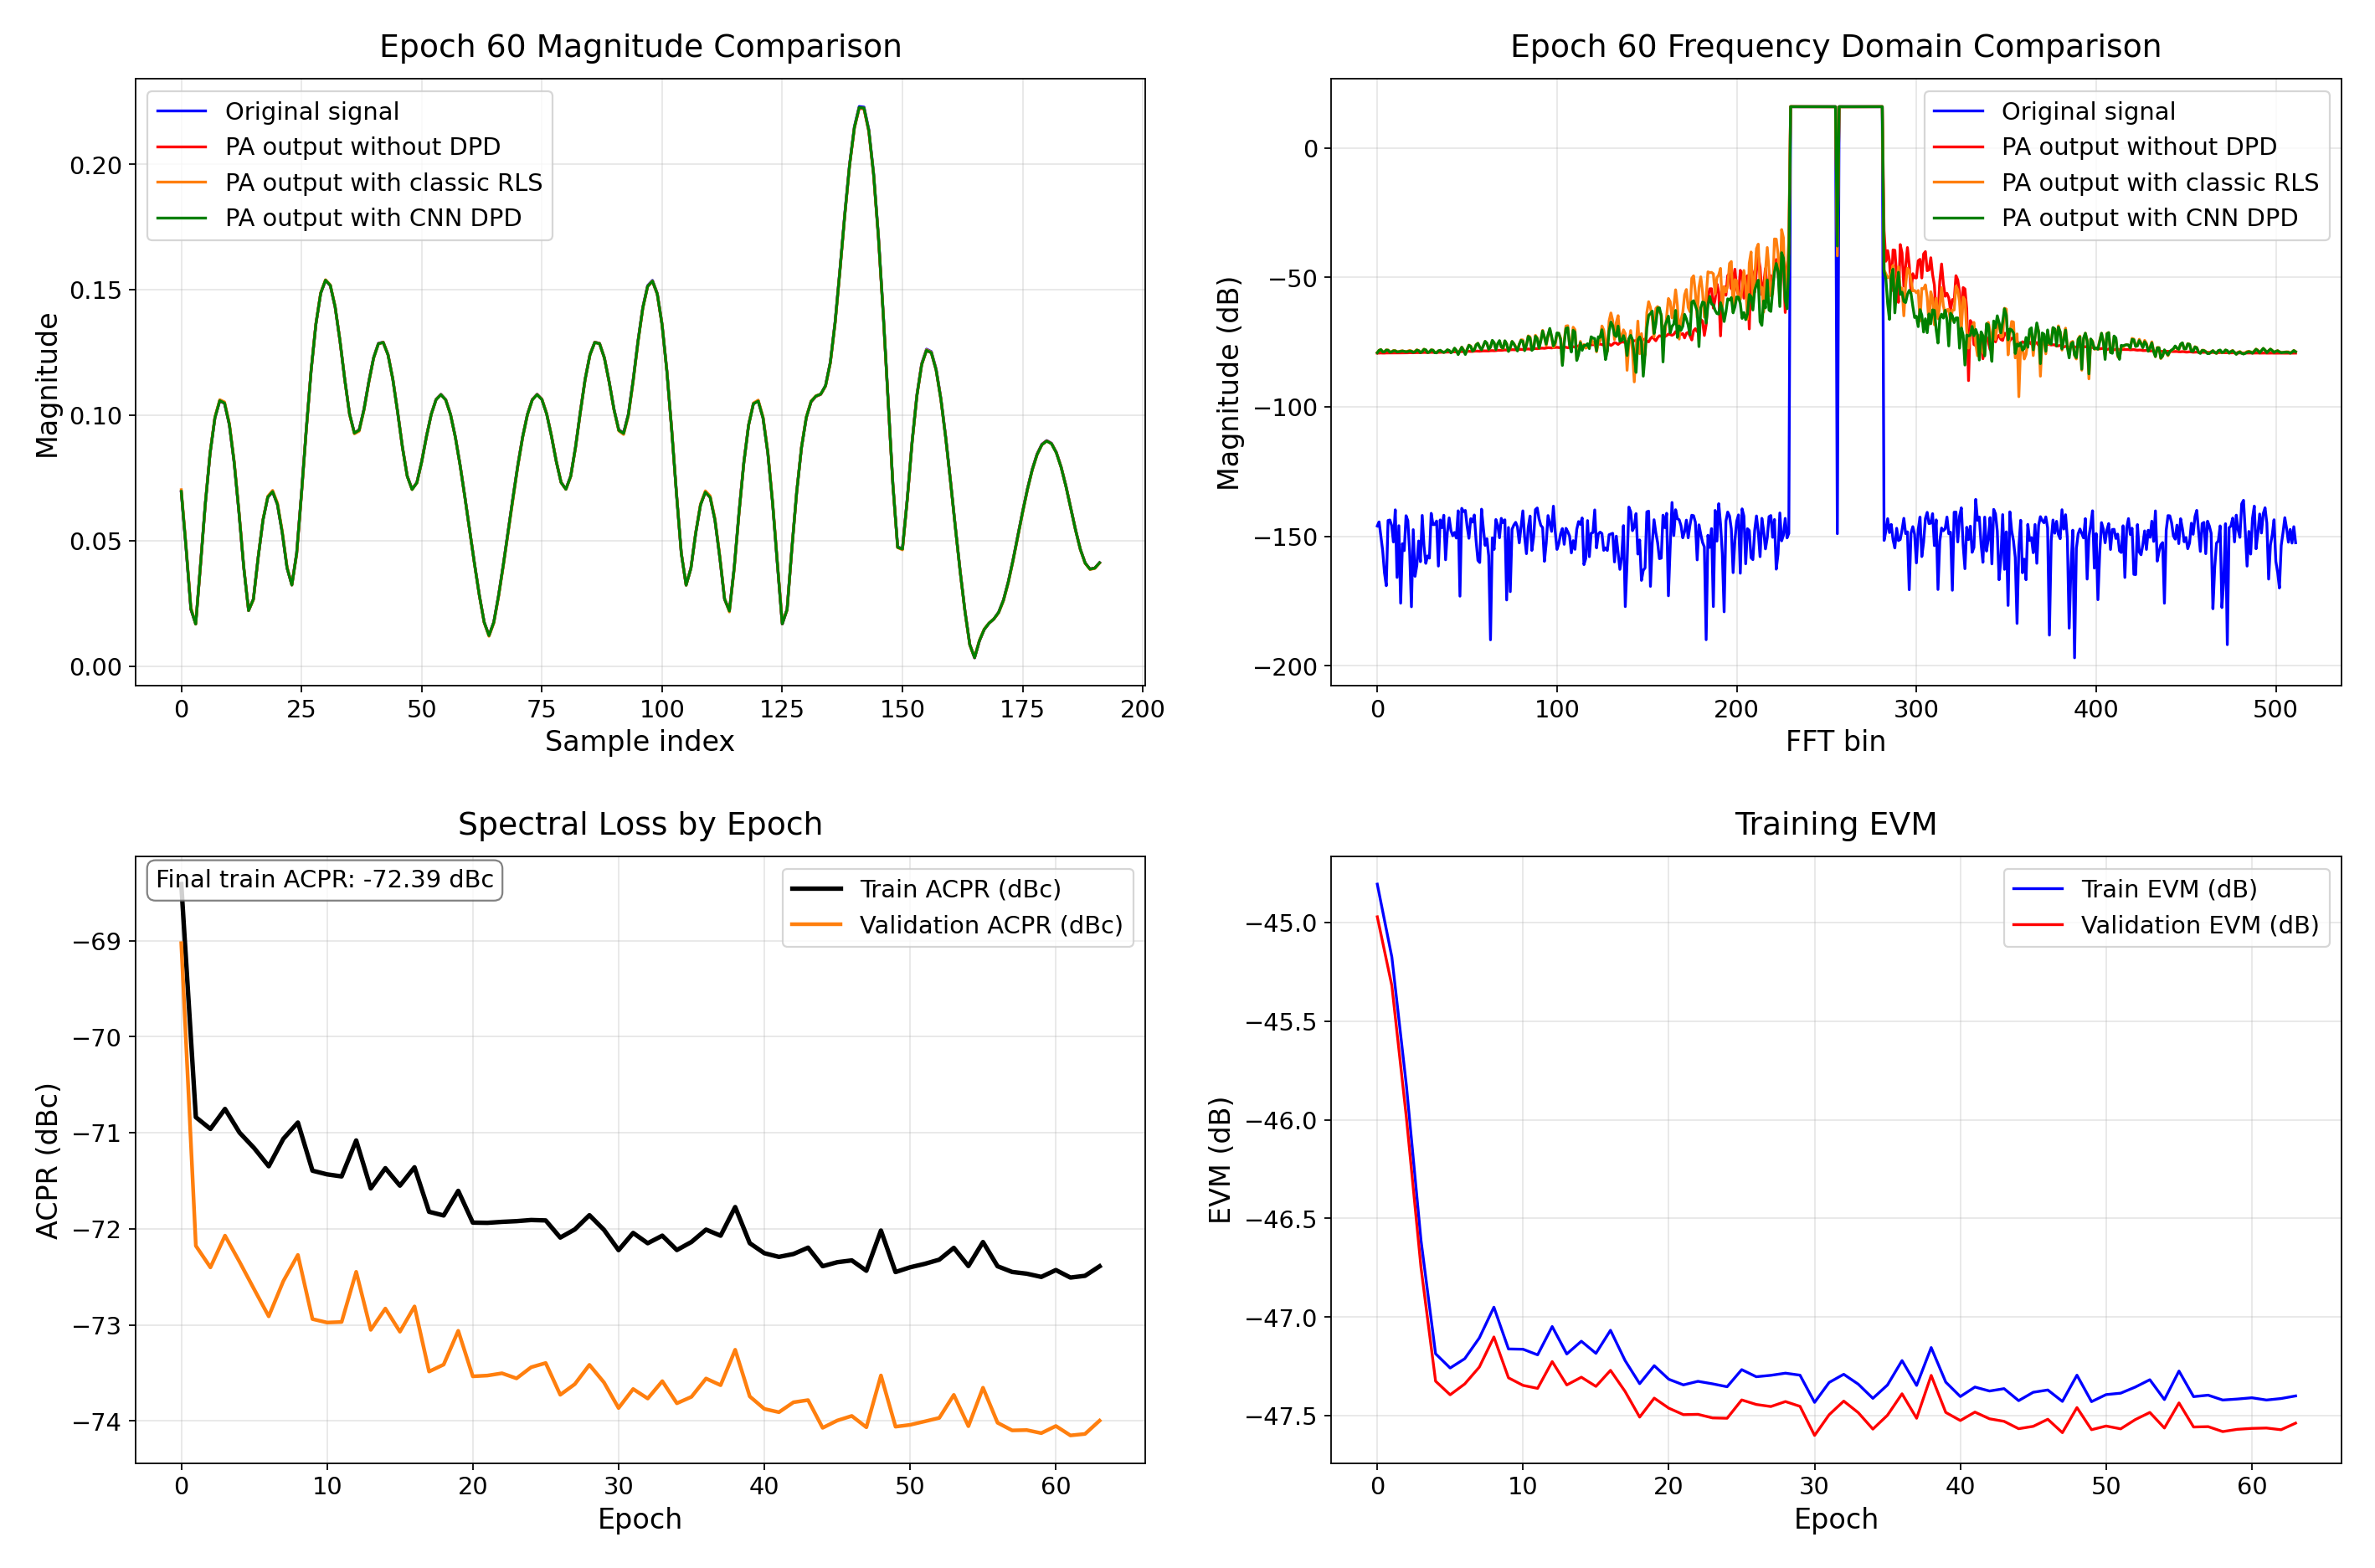

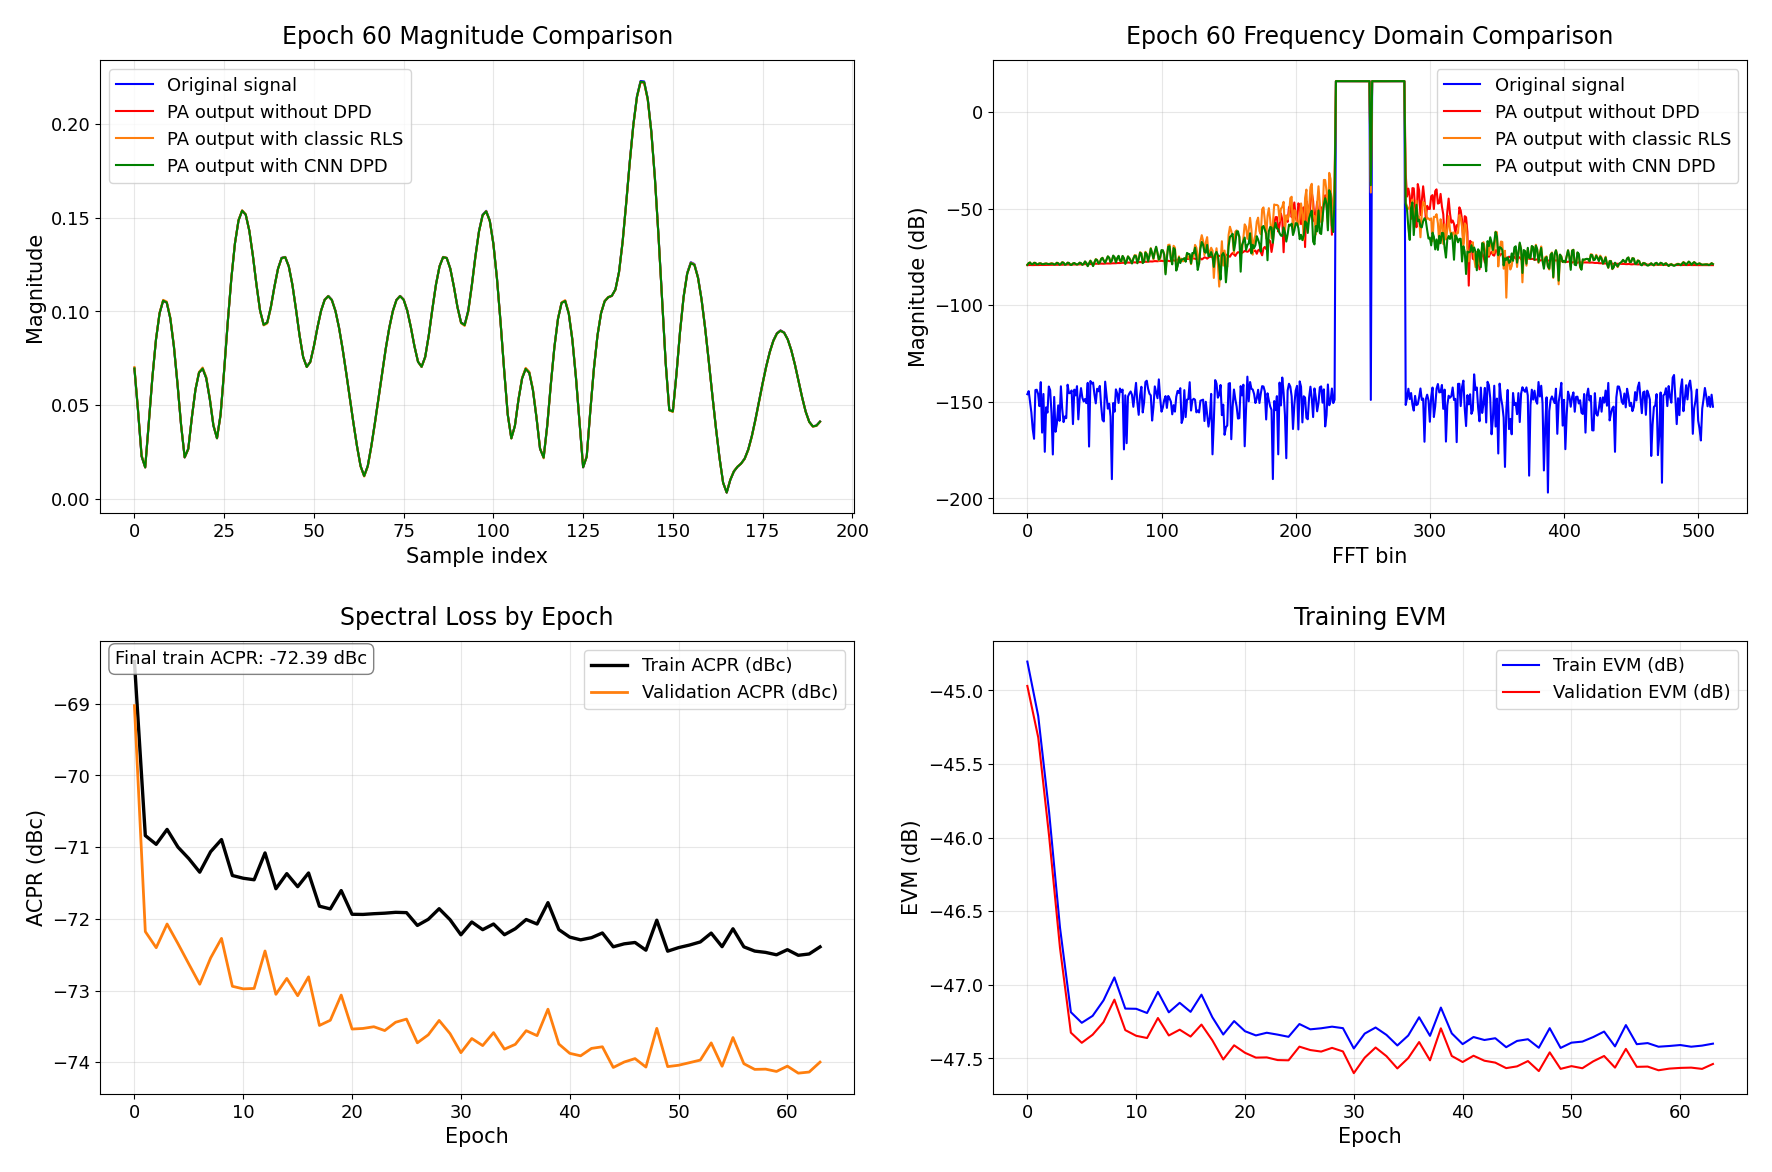

Saved held-out per-backoff spectral metrics to: /content/Model_based_ml/runs/2026-08-27_08-50-54/held_out_spectral_by_backoff.txt


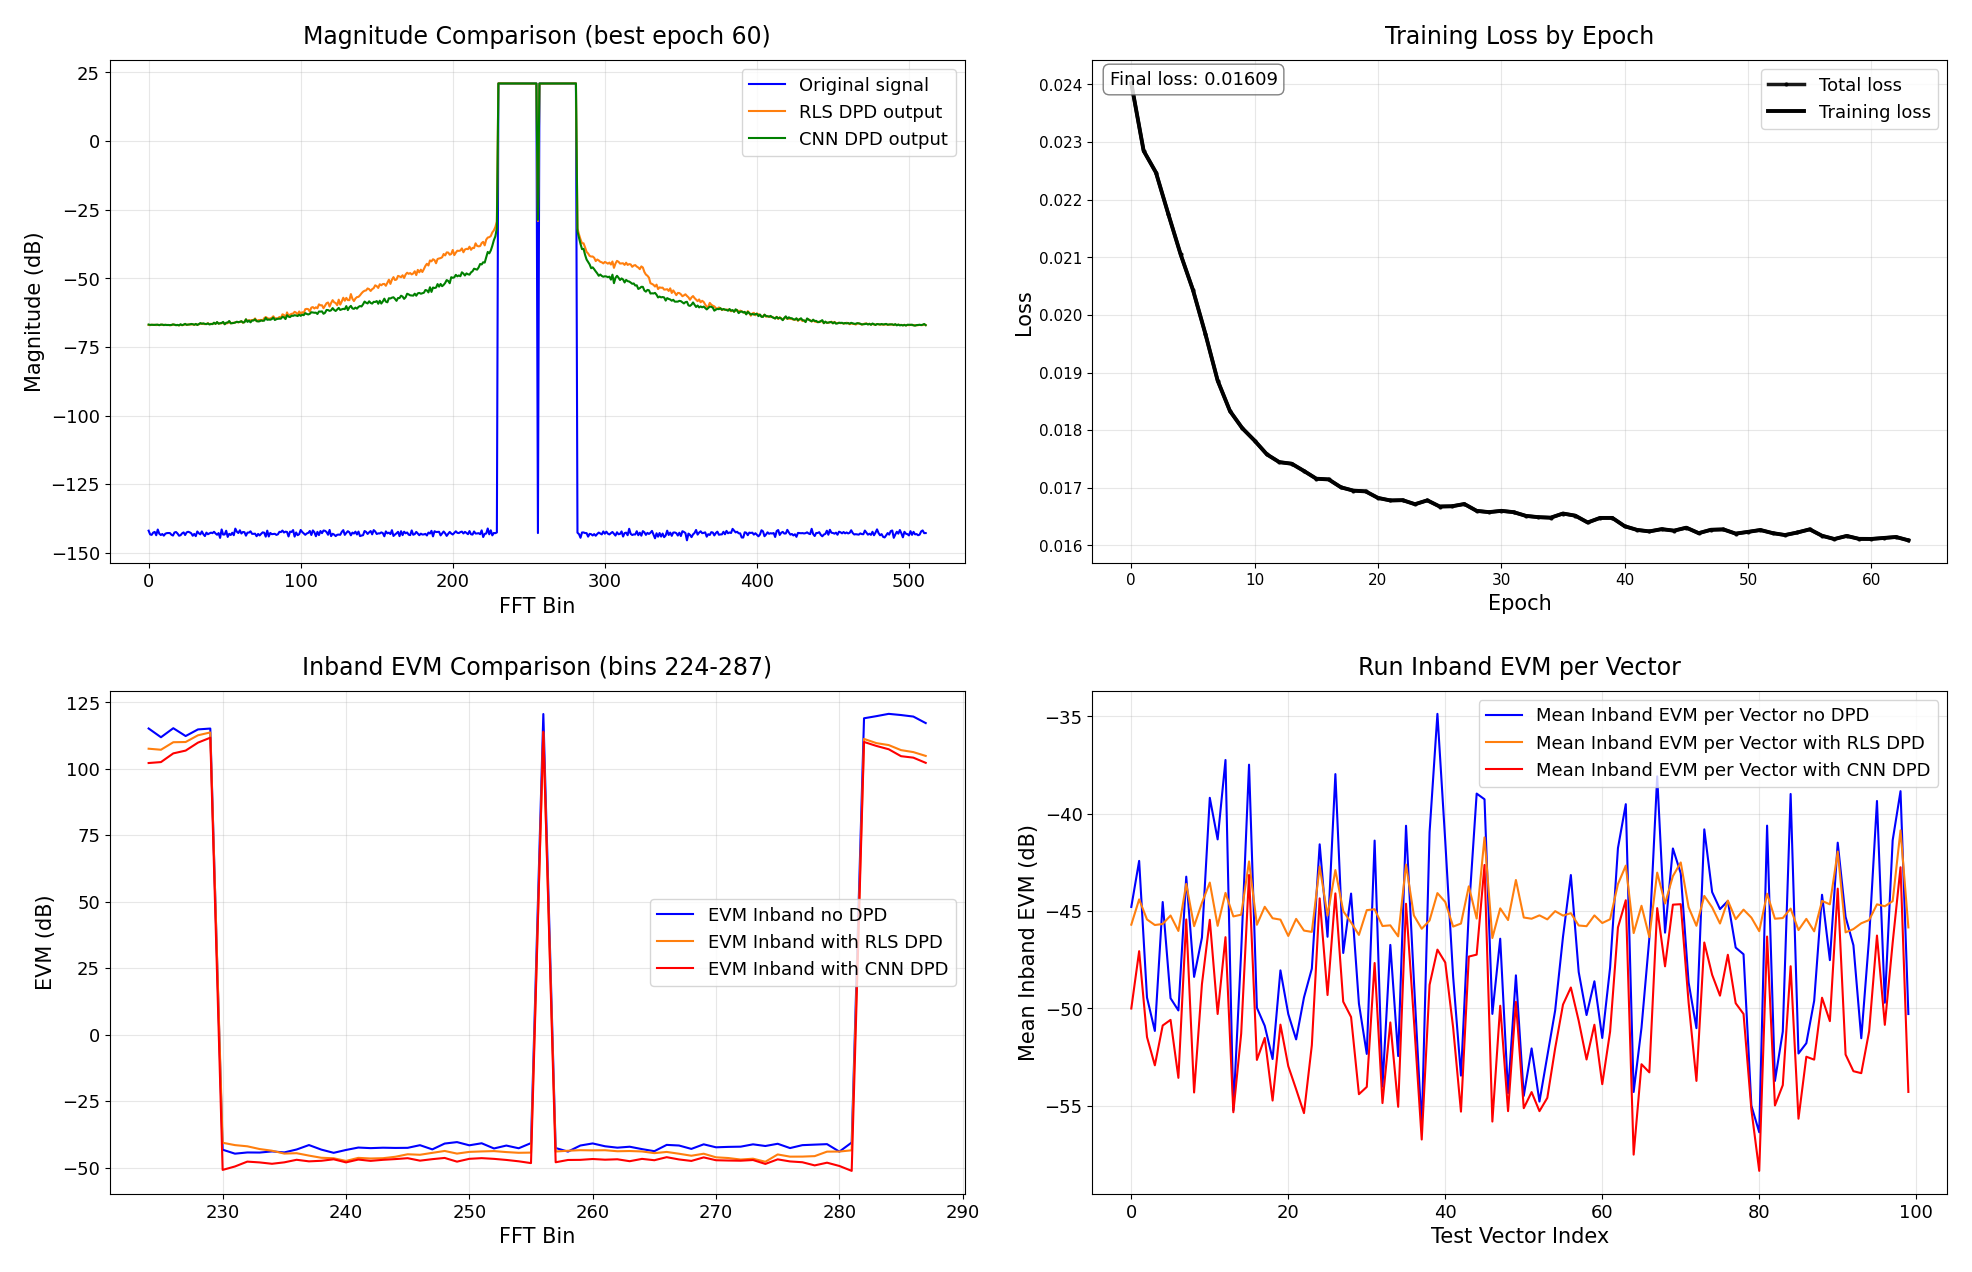

Saved combined loss/metrics plot to: /content/Model_based_ml/runs/2026-08-27_08-50-54/summary_4panel_plots.png
Saved magnitude comparison plot to: /content/Model_based_ml/runs/2026-08-27_08-50-54/magnitude_comparison.png
EVM time domain no DPD: -40.67402
EVM time domain with DPD: -47.026936
ACPR no DPD (dBc): -65.39259
ACPR with RLS DPD (dBc): -67.512596
ACPR with CNN DPD (dBc): -74.19046
Far Out of Band no DPD (dBc): -48.31242
Far Out of Band with RLS DPD (dBc): -58.64416
Far Out of Band with CNN DPD (dBc): -64.31906
Saved run figures under: /content/Model_based_ml/runs/2026-08-27_08-50-54
----- RUN SUMMARY -----
Epochs ran: 64
Best validation EVM: -47.57 dB (0.42%)
Best epoch: 60
Average RLS inband EVM over 100 signals: -44.24 dB
Average CNN inband EVM over 100 signals: -47.15 dB
Selected checkpoint loss: 0.016113
ACPR no DPD (dBc): -65.39
ACPR with DPD (dBc): -74.19
Far OOB no DPD (dBc): -48.31
Far OOB with DPD (dBc): -64.32
Saved run summary to: /content/Model_based_ml/runs/2026-08

In [16]:
# Reload the saved best checkpoint and regenerate the plots from it

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.titlepad": 12,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,
    "figure.titlesize": 20,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.25,
})

def _format_priority_tuple(value):
    if isinstance(value, (tuple, list)) and len(value) == 3:
        def _fmt_item(item):
            try:
                return f"{float(item):.2f}"
            except (TypeError, ValueError):
                return str(item)
        return f"({_fmt_item(value[0])}, {_fmt_item(value[1])}, {_fmt_item(value[2])})"
    return str(value)


def _write_run_summary_text(path, train_summary, acpr_no_predistorsion, acpr_with_predistorsion, acpr_rest_no_predistorsion, acpr_rest_with_predistorsion, held_out_spectral_by_backoff=None, model_complexity=None, scenario_info=None):
    train_loss_history = train_summary.get("train_loss_history", [])
    evm_term_history = train_summary.get("evm_term_history", [])
    selected_epoch = int(train_summary.get("best_epoch", -1))
    selected_index = selected_epoch - 1
    selected_loss_text = f"{train_loss_history[selected_index]:.6f}" if 0 <= selected_index < len(train_loss_history) else "RLS baseline (epoch 0)"
    selected_evm_term_text = f"{evm_term_history[selected_index]:.6f}" if 0 <= selected_index < len(evm_term_history) else "RLS baseline (epoch 0)"
    lines = [
        "----- RUN SUMMARY -----",
        f"Epochs ran: {train_summary.get('epochs_ran', 0)}",
        f"Best epoch: {train_summary.get('best_epoch', -1)}",
        f"Best validation EVM: {train_summary.get('best_val_evm_db', float('nan')):.2f} dB ({train_summary.get('best_val_evm_percent', float('nan')):.2f}%)",
        f"Selected checkpoint loss: {selected_loss_text}",
        f"Selected checkpoint EVM term: {selected_evm_term_text}",
        f"ACPR no DPD (dBc): {acpr_no_predistorsion:.2f}",
        f"ACPR with DPD (dBc): {acpr_with_predistorsion:.2f}",
        f"Far Out of Band no DPD (dBc): {acpr_rest_no_predistorsion:.2f}",
        f"Far Out of Band with DPD (dBc): {acpr_rest_with_predistorsion:.2f}",
    ]
    if scenario_info:
        lines.extend([
            f"Active RLS scenario: {scenario_info.get('display_name', 'RLS')}",
            f"Scenario description: {scenario_info.get('description', 'n/a')}",
        ])
    if model_complexity:
        lines.extend([
            f"RLS model: {model_complexity['rls_complex_coefficients']} active complex coefficients out of {model_complexity.get('rls_total_complex_coefficients', model_complexity['rls_complex_coefficients'])} total ({model_complexity['rls_real_degrees_of_freedom']} active real DOF), basis rank {model_complexity['rls_basis_rank']}",
            f"RLS estimator covariance: {model_complexity['rls_covariance_complex_values']} complex state values (not model parameters)",
            f"CNN model: {model_complexity['cnn_trainable_real_parameters']} trainable real parameters ({model_complexity['cnn_to_rls_real_dof_ratio']:.2f}x active RLS real DOF)",
        ])
    if held_out_spectral_by_backoff:
        lines.extend(["", "Held-out spectral metrics by RMS backoff"] )
        for backoff_db, metrics in held_out_spectral_by_backoff.items():
            rls_metrics = metrics["rls"]
            cnn_metrics = metrics["cnn"]
            lines.append(
                f"{backoff_db:+d} dB (n={metrics['count']}): "
                f"RLS ACPR/OOB {rls_metrics['acpr_db']:.2f}/{rls_metrics['oob_db']:.2f} dBc; "
                f"CNN {cnn_metrics['acpr_db']:.2f}/{cnn_metrics['oob_db']:.2f} dBc; "
                f"CNN-RLS {cnn_metrics['acpr_db'] - rls_metrics['acpr_db']:+.2f}/{cnn_metrics['oob_db'] - rls_metrics['oob_db']:+.2f} dB"
            )
    Path(path).write_text("\n".join(lines) + "\n", encoding="utf-8")


training_checkpoint = torch.load(TRAINING_CHECKPOINT_PATH, map_location=device)
train_state = training_checkpoint.get("train_state", {})
selected_metadata = dict(train_state.get("best_metadata", {}))
best_metadata = dict(selected_metadata)

selected_state_dict = train_state.get("best_state_dict")
selected_checkpoint_state_dict = train_state.get("best_acpr_state_dict")

if selected_state_dict is None:
    fallback_checkpoint = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
    selected_state_dict = fallback_checkpoint.get("model_state_dict")
    fallback_metadata = fallback_checkpoint.get("metadata", {})
    best_metadata = {**fallback_metadata, **best_metadata}

if selected_state_dict is None:
    raise RuntimeError("Could not find a selected checkpoint in TRAINING_CHECKPOINT_PATH or MODEL_WEIGHTS_PATH")

selected_epoch_for_plots = int(train_state.get("best_epoch", best_metadata.get("best_epoch", -1)))
best_epoch_for_plots = selected_epoch_for_plots
best_val_evm_db_for_plots = best_metadata.get("best_val_evm_db", train_state.get("best_val_evm_db", float("nan")))
if best_metadata.get("rls_baseline_coeffs") is not None:
    RLS_BASELINE_COEFFS = np.asarray(best_metadata.get("rls_baseline_coeffs"), dtype=complex).reshape(-1)
if best_metadata.get("rls_scenario_name") is not None:
    RLS_SCENARIO_NAME = str(best_metadata.get("rls_scenario_name")).strip().lower()
    RLS_SCENARIO_INFO = {
        "display_name": best_metadata.get("rls_scenario_display_name", RLS_SCENARIO_NAME),
        "description": best_metadata.get("rls_scenario_description", "n/a"),
        "keep_ratio": float(best_metadata.get("rls_reduction_keep_ratio", 1.0)),
        "reduction_strategy": best_metadata.get("rls_reduction_strategy", "full"),
        "baseline_coeffs": RLS_BASELINE_COEFFS,
    }
    RLS_ACTIVE_COEFF_SUMMARY = _summarize_rls_coeffs(RLS_BASELINE_COEFFS)
if selected_checkpoint_state_dict is None:
    selected_checkpoint_state_dict = selected_state_dict
    print("Warning: selected state dict missing; falling back to the best available checkpoint for plots.")

plot_model = DpdCnn(
    input_size=int(best_metadata.get("input_size", globals().get("input_size", 4))),
    hidden_size=int(best_metadata.get("hidden_size", globals().get("hidden_size", 32))),
    num_layers=int(best_metadata.get("num_layers", globals().get("num_cnn_layers", 2))),
    dropout=float(best_metadata.get("dropout", globals().get("dropout", 0.1))),
).to(device)
plot_model.load_state_dict(selected_state_dict)
plot_model.eval()
model = plot_model
run_model_complexity = dict(best_metadata.get("model_complexity", build_model_complexity_summary(plot_model, rls_coeffs=RLS_BASELINE_COEFFS)))
model_complexity_path = RUN_OUTPUT_DIR / "model_complexity.txt"
model_complexity_path.write_text(
    "\n".join([
        f"RLS complex coefficients: {run_model_complexity['rls_complex_coefficients']}",
        f"RLS real degrees of freedom: {run_model_complexity['rls_real_degrees_of_freedom']}",
        f"RLS GMP basis rank: {run_model_complexity['rls_basis_rank']}",
        f"RLS covariance complex state values: {run_model_complexity['rls_covariance_complex_values']} (not model parameters)",
        f"CNN trainable real parameters: {run_model_complexity['cnn_trainable_real_parameters']}",
        f"CNN/RLS real-DOF ratio: {run_model_complexity['cnn_to_rls_real_dof_ratio']:.2f}",
    ]) + "\n", encoding="utf-8"
)

train_summary = dict(train_state)
train_mse = train_state.get("train_mse", [])
valid_mse = train_state.get("valid_mse", [])
train_evm = train_state.get("train_evm", [])
valid_evm = train_state.get("valid_evm", [])
train_loss_history = train_state.get("train_loss_history", [])
train_spectral_db_history = train_state.get("train_spectral_db_history", [])
valid_spectral_db_history = train_state.get("valid_spectral_db_history", [])
evm_term_history = train_state.get("evm_term_history", [])
acpr_penalty_history = train_state.get("acpr_penalty_history", train_state.get("spectral_total_loss_history", []))
oob_penalty_history = train_state.get("oob_penalty_history", [])
lambda_ib_history = train_state.get("lambda_ib_history", [])
lambda_aclr_history = train_state.get("lambda_aclr_history", [])
lambda_oob_history = train_state.get("lambda_oob_history", [])
phase_history = train_state.get("phase_history", [])
IB_region_loss_raw_history = train_state.get("IB_region_loss_raw_history", [])
adjacent_region_loss_raw_history = train_state.get("adjacent_region_loss_raw_history", [])
FOOB_region_loss_raw_history = train_state.get("FOOB_region_loss_raw_history", [])
acpr_db_history = train_state.get("out_of_band_loss_db_history", [])
train_summary["train_loss_history"] = train_loss_history
train_summary["evm_term_history"] = evm_term_history
train_summary["acpr_penalty_history"] = acpr_penalty_history
train_summary["spectral_total_loss_history"] = acpr_penalty_history
train_summary["IB_region_loss_raw_history"] = IB_region_loss_raw_history
train_summary["adjacent_region_loss_raw_history"] = adjacent_region_loss_raw_history
train_summary["FOOB_region_loss_raw_history"] = FOOB_region_loss_raw_history
train_summary["out_of_band_loss_db_history"] = acpr_db_history
train_summary["test_mean_inband_evm_db"] = train_state.get("test_mean_inband_evm_db", float("nan"))

print("Reloaded training checkpoint from:", TRAINING_CHECKPOINT_PATH.resolve())
print("Plot epoch used for reconstruction:", selected_epoch_for_plots)
print("Best training epoch from checkpoint:", train_state.get("best_epoch", -1))
print("Best validation EVM from checkpoint:", best_val_evm_db_for_plots)

training_dashboard_figure = plt.figure(figsize=(18, 12))
training_dashboard_grid = training_dashboard_figure.add_gridspec(2, 2)
training_dashboard_axes = (
    training_dashboard_figure.add_subplot(training_dashboard_grid[0, 0]),
    training_dashboard_figure.add_subplot(training_dashboard_grid[0, 1]),
    training_dashboard_figure.add_subplot(training_dashboard_grid[1, 0]),
    training_dashboard_figure.add_subplot(training_dashboard_grid[1, 1]),
)
update_epoch_dashboard_plot(
    model,
    training_preview_symbol,
    training_dashboard_figure,
    training_dashboard_axes,
    best_epoch_for_plots,
    _NFFT,
    train_mse,
    valid_mse,
    train_evm,
    valid_evm,
    train_spectral_db_history,
    valid_spectral_db_history,
)
training_dashboard_figure.savefig(RUN_OUTPUT_DIR / "training_dashboard_final.png", dpi=180, bbox_inches="tight", pad_inches=0.25, facecolor="white")
plt.close(training_dashboard_figure)

cnn_eval_pairs = globals().get("test_data", test_data)
if cnn_eval_pairs is None or len(cnn_eval_pairs) == 0:
    raise NameError("No CNN evaluation signals are available.")
comparison_eval_count = min(100, len(cnn_eval_pairs))
if comparison_eval_count < 1:
    raise ValueError("Need at least one RLS/CNN evaluation signal to build the comparison summary.")
cnn_eval_pairs = cnn_eval_pairs[:comparison_eval_count]

reference_symbols = [np.asarray(symbol_pair[0], dtype=np.complex64).reshape(-1) for symbol_pair in cnn_eval_pairs]
reference_test_waveform = np.concatenate(reference_symbols)
no_dpd_pa_out_symbols = [apply_pa_model(symbol, bypass=False) for symbol in reference_symbols]
rls_predistorted_symbols = [
    np.asarray(apply_predistortion(symbol, RLS_BASELINE_COEFFS, bypass=False, active_basis_indices=_resolve_rls_active_basis_indices(RLS_BASELINE_COEFFS))[0], dtype=np.complex64)
    for symbol in reference_symbols
]
rls_pa_out_symbols = [apply_pa_model(symbol, bypass=False) for symbol in rls_predistorted_symbols]
pa_in_pred_reshaped = np.concatenate([
    predict_predistorted_waveform_for_symbol(model, symbol_pair, baseline_coeffs=RLS_BASELINE_COEFFS) for symbol_pair in cnn_eval_pairs
])
cnn_symbol_len = len(reference_symbols[0])
cnn_predistorted_symbols = pa_in_pred_reshaped.reshape(comparison_eval_count, cnn_symbol_len)
cnn_pa_out_symbols = [apply_pa_model(symbol, bypass=False) for symbol in cnn_predistorted_symbols]
no_dpd_pa_out_symbols = [align_complex_waveform_numpy(reference, measured) for reference, measured in zip(reference_symbols, no_dpd_pa_out_symbols)]
rls_pa_out_symbols = [align_complex_waveform_numpy(reference, measured) for reference, measured in zip(reference_symbols, rls_pa_out_symbols)]
cnn_pa_out_symbols = [align_complex_waveform_numpy(reference, measured) for reference, measured in zip(reference_symbols, cnn_pa_out_symbols)]
held_out_spectral_metrics = compute_aligned_spectral_metrics_by_backoff(
    np.stack(reference_symbols),
    {"no_dpd": np.stack(no_dpd_pa_out_symbols), "rls": np.stack(rls_pa_out_symbols), "cnn": np.stack(cnn_pa_out_symbols)},
    n_fft=_NFFT,
)
held_out_spectral_by_backoff = held_out_spectral_metrics["by_backoff"]
held_out_spectral_path = RUN_OUTPUT_DIR / "held_out_spectral_by_backoff.txt"
held_out_lines = [f"Backoff | Count | {RLS_SCENARIO_INFO['display_name']} ACPR | CNN ACPR | Delta | {RLS_SCENARIO_INFO['display_name']} OOB | CNN OOB | Delta"]
for backoff_db, metrics in held_out_spectral_by_backoff.items():
    rls_metrics, cnn_metrics = metrics["rls"], metrics["cnn"]
    held_out_lines.append(
        f"{backoff_db:+d} dB | {metrics['count']} | {rls_metrics['acpr_db']:.2f} | {cnn_metrics['acpr_db']:.2f} | "
        f"{cnn_metrics['acpr_db'] - rls_metrics['acpr_db']:+.2f} | {rls_metrics['oob_db']:.2f} | "
        f"{cnn_metrics['oob_db']:.2f} | {cnn_metrics['oob_db'] - rls_metrics['oob_db']:+.2f}"
    )
held_out_spectral_path.write_text("\n".join(held_out_lines) + "\n", encoding="utf-8")
print("Saved held-out per-backoff spectral metrics to:", held_out_spectral_path.resolve())
no_dpd_pa_out_waveform = np.concatenate(no_dpd_pa_out_symbols)
rls_pa_out_waveform = np.concatenate(rls_pa_out_symbols)
cnn_pa_out_waveform = np.concatenate(cnn_pa_out_symbols)

n_fft = _NFFT
inner_band_start_bin = 224
inner_band_stop_bin = 288
inband_bins = np.arange(inner_band_start_bin, inner_band_stop_bin)

reference_test_rs = reference_test_waveform.reshape(comparison_eval_count, -1)[:, _CP_LEN // 2:_NFFT + _CP_LEN // 2]
no_dpd_out_rs = np.asarray(no_dpd_pa_out_waveform, dtype=np.complex64).reshape(comparison_eval_count, -1)[:, _CP_LEN // 2:_NFFT + _CP_LEN // 2]
rls_out_rs = np.asarray(rls_pa_out_waveform, dtype=np.complex64).reshape(comparison_eval_count, -1)[:, _CP_LEN // 2:_NFFT + _CP_LEN // 2]
rf_out_rs = np.asarray(cnn_pa_out_waveform, dtype=np.complex64).reshape(comparison_eval_count, -1)[:, _CP_LEN // 2:_NFFT + _CP_LEN // 2]
reference_test_fd = np.fft.fftshift(np.fft.fft(reference_test_rs, axis=1), axes=1)
no_dpd_out_fd = np.fft.fftshift(np.fft.fft(no_dpd_out_rs, axis=1), axes=1)
rls_out_fd = np.fft.fftshift(np.fft.fft(rls_out_rs, axis=1), axes=1)
rf_out_fd = np.fft.fftshift(np.fft.fft(rf_out_rs, axis=1), axes=1)
reference_test_magdb_fd = 20 * np.log10(np.mean(np.abs(reference_test_fd), axis=0))
rls_out_magdb_fd = 20 * np.log10(np.mean(np.abs(rls_out_fd), axis=0))
rf_out_magdb_fd = 20 * np.log10(np.mean(np.abs(rf_out_fd), axis=0))

summary_fig = plt.figure(figsize=(20, 13))
gs = summary_fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0])
ax_mag = summary_fig.add_subplot(gs[0, 0])
ax_loss = summary_fig.add_subplot(gs[0, 1])
ax_evm = summary_fig.add_subplot(gs[1, 0])
ax_run_evm = summary_fig.add_subplot(gs[1, 1])

ax_mag.plot(reference_test_magdb_fd, label="Original signal", color="blue")
ax_mag.plot(rls_out_magdb_fd, label="RLS DPD output", color="tab:orange")
ax_mag.plot(rf_out_magdb_fd, label="CNN DPD output", color="green")
ax_mag.set_title(f"Magnitude Comparison (best epoch {best_epoch_for_plots})", fontsize=17, pad=12)
ax_mag.set_xlabel("FFT Bin", fontsize=15)
ax_mag.set_ylabel("Magnitude (dB)", fontsize=15)
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc="best", fontsize=13)

reference_ib_fd = reference_test_fd[:, inner_band_start_bin:inner_band_stop_bin]
rls_out_ib_fd = rls_out_fd[:, inner_band_start_bin:inner_band_stop_bin]
cnn_out_ib_fd = rf_out_fd[:, inner_band_start_bin:inner_band_stop_bin]
mse_ib_no_predistorsion = np.mean(np.abs(reference_ib_fd - no_dpd_out_fd[:, inner_band_start_bin:inner_band_stop_bin]) ** 2, axis=0)
evm_ib_db_no_predistorsion = 10 * np.log10(mse_ib_no_predistorsion / np.mean(np.abs(reference_ib_fd) ** 2, axis=0))
mse_ib_with_rls = np.mean(np.abs(reference_ib_fd - rls_out_fd[:, inner_band_start_bin:inner_band_stop_bin]) ** 2, axis=0)
evm_ib_db_with_rls = 10 * np.log10(mse_ib_with_rls / np.mean(np.abs(reference_ib_fd) ** 2, axis=0))
mse_ib_with_predistorsion = np.mean(np.abs(reference_ib_fd - cnn_out_ib_fd) ** 2, axis=0)
evm_ib_db_with_predistorsion = 10 * np.log10(mse_ib_with_predistorsion / np.mean(np.abs(reference_ib_fd) ** 2, axis=0))
run_evm_ib_db_no_predistorsion = compute_mean_inband_evm_db(reference_ib_fd, no_dpd_out_fd[:, inner_band_start_bin:inner_band_stop_bin])
run_evm_ib_db_with_rls = compute_mean_inband_evm_db(reference_ib_fd, rls_out_fd[:, inner_band_start_bin:inner_band_stop_bin])
run_evm_ib_db_with_predistorsion = compute_mean_inband_evm_db(reference_ib_fd, cnn_out_ib_fd)
cnn_test_mean_inband_evm_db_no_dpd = compute_aggregate_inband_evm_db(reference_ib_fd, no_dpd_out_fd[:, inner_band_start_bin:inner_band_stop_bin])
rls_test_mean_inband_evm_db = compute_aggregate_inband_evm_db(reference_ib_fd, rls_out_fd[:, inner_band_start_bin:inner_band_stop_bin])
cnn_test_mean_inband_evm_db = compute_aggregate_inband_evm_db(reference_ib_fd, cnn_out_ib_fd)

cp_half_len = _CP_LEN // 2
time_stop = -cp_half_len if cp_half_len > 0 else None
reference_test_td = reference_test_rs[:, cp_half_len:time_stop]
no_dpd_out_td = no_dpd_out_rs[:, cp_half_len:time_stop]
rls_out_td = rls_out_rs[:, cp_half_len:time_stop]
rf_out_td = rf_out_rs[:, cp_half_len:time_stop]
mse_td_no_predistorsion = np.mean(np.abs(reference_test_td - no_dpd_out_td) ** 2)
mse_td_with_rls = np.mean(np.abs(reference_test_td - rls_out_td) ** 2)
mse_td_with_predistorsion = np.mean(np.abs(reference_test_td - rf_out_td) ** 2)
evm_td_no_predistorsion = 10 * np.log10(mse_td_no_predistorsion / np.mean(np.abs(reference_test_td) ** 2))
evm_td_with_rls = 10 * np.log10(mse_td_with_rls / np.mean(np.abs(reference_test_td) ** 2))
evm_td_with_predistorsion = 10 * np.log10(mse_td_with_predistorsion / np.mean(np.abs(reference_test_td) ** 2))

ax_loss.plot(train_loss_history, label="Total loss", color="black", linewidth=2.5, marker="o", markersize=2, alpha=0.9)
ax_loss.plot(train_loss_history, label="Training loss", color="black", linewidth=2.8)
ax_loss.set_title("Training Loss by Epoch", fontsize=17, pad=12)
ax_loss.set_xlabel("Epoch", fontsize=15)
ax_loss.set_ylabel("Loss", fontsize=15)
ax_loss.set_yscale("linear")
ax_loss.tick_params(axis="both", labelsize=11)
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(loc="best", fontsize=13)
if train_loss_history:
    ax_loss.text(
        0.02,
        0.98,
        f"Final loss: {train_loss_history[-1]:.4g}",
        transform=ax_loss.transAxes,
        va="top",
        ha="left",
        fontsize=13,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.82, edgecolor="0.4"),
    )

ax_evm.plot(inband_bins, evm_ib_db_no_predistorsion, label="EVM Inband no DPD", color="blue")
ax_evm.plot(inband_bins, evm_ib_db_with_rls, label="EVM Inband with RLS DPD", color="tab:orange")
ax_evm.plot(inband_bins, evm_ib_db_with_predistorsion, label="EVM Inband with CNN DPD", color="red")
ax_evm.set_title(f"Inband EVM Comparison (bins {inner_band_start_bin}-{inner_band_stop_bin - 1})", fontsize=17, pad=12)
ax_evm.set_xlabel("FFT Bin", fontsize=15)
ax_evm.set_ylabel("EVM (dB)", fontsize=15)
ax_evm.grid(True, alpha=0.3)
ax_evm.legend(loc="best", fontsize=13)

ax_run_evm.plot(run_evm_ib_db_no_predistorsion, label="Mean Inband EVM per Vector no DPD", color="blue")
ax_run_evm.plot(run_evm_ib_db_with_rls, label="Mean Inband EVM per Vector with RLS DPD", color="tab:orange")
ax_run_evm.plot(run_evm_ib_db_with_predistorsion, label="Mean Inband EVM per Vector with CNN DPD", color="red")
ax_run_evm.set_title("Run Inband EVM per Vector", fontsize=17, pad=12)
ax_run_evm.set_xlabel("Test Vector Index", fontsize=15)
ax_run_evm.set_ylabel("Mean Inband EVM (dB)", fontsize=15)
ax_run_evm.grid(True, alpha=0.3)
ax_run_evm.legend(loc="best", fontsize=13)

summary_fig.tight_layout(pad=2.0)
summary_path = RUN_OUTPUT_DIR / "summary_4panel_plots.png"
summary_fig.savefig(summary_path, dpi=180, bbox_inches="tight", pad_inches=0.25, facecolor="white")
plt.show()
plt.close(summary_fig)
print("Saved combined loss/metrics plot to:", summary_path.resolve())

magnitude_compare_path = RUN_OUTPUT_DIR / "magnitude_comparison.png"
magnitude_fig, magnitude_ax = plt.subplots(figsize=(14, 6))
magnitude_ax.plot(reference_test_magdb_fd, label="Original signal", color="blue")
magnitude_ax.plot(rls_out_magdb_fd, label="RLS DPD output", color="tab:orange")
magnitude_ax.plot(rf_out_magdb_fd, label="CNN DPD output", color="green")
magnitude_ax.set_title(f"Magnitude Comparison (best epoch {best_epoch_for_plots})", fontsize=17, pad=12)
magnitude_ax.set_xlabel("FFT Bin", fontsize=15)
magnitude_ax.set_ylabel("Magnitude (dB)", fontsize=15)
magnitude_ax.grid(True, alpha=0.3)
magnitude_ax.legend(loc="best", fontsize=13)
magnitude_fig.tight_layout(pad=2.0)
magnitude_fig.savefig(magnitude_compare_path, dpi=180, bbox_inches="tight", pad_inches=0.25, facecolor="white")
plt.close(magnitude_fig)
print("Saved magnitude comparison plot to:", magnitude_compare_path.resolve())

acpr_no_predistorsion = float("nan")
acpr_with_predistorsion = float("nan")
acpr_rest_no_predistorsion = float("nan")
acpr_rest_with_predistorsion = float("nan")
try:
    acpr_no_predistorsion, acpr_rest_no_predistorsion = compute_acpr_db(no_dpd_out_rs, n_fft=n_fft, return_components=True)
    acpr_rls_with_predistorsion, acpr_rest_rls_with_predistorsion = compute_acpr_db(rls_out_rs, n_fft=n_fft, return_components=True)
    acpr_with_predistorsion, acpr_rest_with_predistorsion = compute_acpr_db(rf_out_rs, n_fft=n_fft, return_components=True)
    rls_mask_pass_count = sum(bool(check_relative_mask(measured=symbol, bypass=False)) for symbol in rls_pa_out_symbols)
    rls_summary_metrics = {
        **rls_summary_metrics,
        "iterations_ran": int(comparison_eval_count),
        "mean_evm_db": float(rls_test_mean_inband_evm_db),
        "best_evm_db": float(np.min(run_evm_ib_db_with_rls)),
        "worst_evm_db": float(np.max(run_evm_ib_db_with_rls)),
        "acpr_no_dpd_db": float(acpr_no_predistorsion),
        "acpr_with_dpd_db": float(acpr_rls_with_predistorsion),
        "far_oob_no_dpd_db": float(acpr_rest_no_predistorsion),
        "far_oob_with_dpd_db": float(acpr_rest_rls_with_predistorsion),
        "mask_pass_count": int(rls_mask_pass_count),
        "evaluation_scope": "held_out_cnn_test_symbols",
    }

    print("EVM time domain no DPD:", evm_td_no_predistorsion)
    print("EVM time domain with DPD:", evm_td_with_predistorsion)
    print("ACPR no DPD (dBc):", acpr_no_predistorsion)
    print("ACPR with RLS DPD (dBc):", acpr_rls_with_predistorsion)
    print("ACPR with CNN DPD (dBc):", acpr_with_predistorsion)
    print("Far Out of Band no DPD (dBc):", acpr_rest_no_predistorsion)
    print("Far Out of Band with RLS DPD (dBc):", acpr_rest_rls_with_predistorsion)
    print("Far Out of Band with CNN DPD (dBc):", acpr_rest_with_predistorsion)
except Exception as final_eval_exc:
    print("Final evaluation skipped or incomplete:", final_eval_exc)
finally:
    print("Saved run figures under:", RUN_OUTPUT_DIR.resolve())
    print("----- RUN SUMMARY -----")
    print(f"Epochs ran: {train_summary.get('epochs_ran', 0)}")
    print(f"Best validation EVM: {train_summary.get('best_val_evm_db', float('nan')):.2f} dB ({train_summary.get('best_val_evm_percent', float('nan')):.2f}%)")
    print(f"Best epoch: {train_summary.get('best_epoch', -1)}")
    print(f"Average RLS inband EVM over {comparison_eval_count} signals: {rls_test_mean_inband_evm_db:.2f} dB")
    print(f"Average CNN inband EVM over {comparison_eval_count} signals: {cnn_test_mean_inband_evm_db:.2f} dB")
    selected_epoch_idx = int(train_summary.get("best_epoch", -1)) - 1
    if 0 <= selected_epoch_idx < len(train_loss_history):
        print(f"Selected checkpoint loss: {train_loss_history[selected_epoch_idx]:.6f}")
    else:
        print("Selected checkpoint loss: RLS baseline (epoch 0)")
    print(f"ACPR no DPD (dBc): {acpr_no_predistorsion:.2f}")
    print(f"ACPR with DPD (dBc): {acpr_with_predistorsion:.2f}")
    print(f"Far OOB no DPD (dBc): {acpr_rest_no_predistorsion:.2f}")
    print(f"Far OOB with DPD (dBc): {acpr_rest_with_predistorsion:.2f}")
    summary_text_path = RUN_OUTPUT_DIR / "run_summary.txt"
    _write_run_summary_text(summary_text_path, train_summary, acpr_no_predistorsion, acpr_with_predistorsion, acpr_rest_no_predistorsion, acpr_rest_with_predistorsion, held_out_spectral_by_backoff, run_model_complexity, scenario_info=RLS_SCENARIO_INFO)
    print("Saved run summary to:", summary_text_path.resolve())

    cnn_summary_metrics = {
        "method": "CNN",
        "best_val_evm_db": float(train_summary.get("best_val_evm_db", float('nan'))),
        "best_val_evm_percent": float(train_summary.get("best_val_evm_percent", float('nan'))),
        "best_epoch": int(train_summary.get("best_epoch", -1)),
        "comparison_eval_count": int(comparison_eval_count),
        "test_mean_inband_evm_db": float(cnn_test_mean_inband_evm_db),
        "acpr_no_dpd_db": float(acpr_no_predistorsion),
        "acpr_with_dpd_db": float(acpr_with_predistorsion),
        "far_oob_no_dpd_db": float(acpr_rest_no_predistorsion),
        "far_oob_with_dpd_db": float(acpr_rest_with_predistorsion),
        "epochs_ran": int(train_summary.get("epochs_ran", 0)),
    }
    comparison_slide_path = RUN_OUTPUT_DIR / "method_comparison_slide.png"
    fig, (ax_text, ax_bar) = plt.subplots(1, 2, figsize=(20, 10), layout="constrained", gridspec_kw={"width_ratios": [1.2, 1.25]})
    scenario_display_name = RLS_SCENARIO_INFO["display_name"]
    fig.suptitle(f"LS vs {scenario_display_name} + CNN DPD Comparison", fontsize=22, fontweight="bold")
    ax_text.axis("off")
    ls_evm_display = f"Mean EVM: {ls_summary_metrics['mean_evm_db']:.2f} dB\nBest EVM: {ls_summary_metrics['best_evm_db']:.2f} dB\nWorst EVM: {ls_summary_metrics['worst_evm_db']:.2f} dB"
    rls_evm_display = f"Mean EVM: {rls_summary_metrics['mean_evm_db']:.2f} dB\nBest EVM: {rls_summary_metrics['best_evm_db']:.2f} dB\nWorst EVM: {rls_summary_metrics['worst_evm_db']:.2f} dB"
    cnn_evm_display = f"Average inband EVM over {comparison_eval_count} signals: {cnn_summary_metrics['test_mean_inband_evm_db']:.2f} dB\nBest validation EVM: {cnn_summary_metrics['best_val_evm_db']:.2f} dB ({cnn_summary_metrics['best_val_evm_percent']:.2f}%)"
    rls_active_display = f"{scenario_display_name}: {run_model_complexity['rls_complex_coefficients']} active complex coefficients out of {run_model_complexity.get('rls_total_complex_coefficients', run_model_complexity['rls_complex_coefficients'])} total ({run_model_complexity['rls_real_degrees_of_freedom']} active real DOF)"
    text_lines = [
        "Method Recap",
        "",
        "LS",
        f"Iterations: {ls_summary_metrics['iterations_ran']}",
        f"Signal RMS: {ls_summary_metrics['signal_rms_dbp']:.2f} dB",
        f"SNR: {ls_summary_metrics['snr_db']:.2f} dB",
        ls_evm_display,
        f"ACPR with DPD: {ls_summary_metrics['acpr_with_dpd_db']:.2f} dBc",
        f"Far OOB with DPD: {ls_summary_metrics['far_oob_with_dpd_db']:.2f} dBc",
        f"Mask pass: {ls_summary_metrics['mask_pass_count']}/{ls_summary_metrics['iterations_ran']}",
        "",
        scenario_display_name,
        rls_active_display,
        f"Held-out vectors: {rls_summary_metrics['iterations_ran']}",
        f"Signal RMS: {rls_summary_metrics['signal_rms_dbp']:.2f} dB",
        f"SNR: {rls_summary_metrics['snr_db']:.2f} dB",
        rls_evm_display,
        f"ACPR with DPD: {rls_summary_metrics['acpr_with_dpd_db']:.2f} dBc",
        f"Far OOB with DPD: {rls_summary_metrics['far_oob_with_dpd_db']:.2f} dBc",
        f"Mask pass: {rls_summary_metrics['mask_pass_count']}/{rls_summary_metrics['iterations_ran']}",
        "",
        "CNN",
        f"Model parameters: {run_model_complexity['cnn_trainable_real_parameters']} trainable real values ({run_model_complexity['cnn_to_rls_real_dof_ratio']:.2f}x RLS real DOF)",
        f"Epochs: {cnn_summary_metrics['epochs_ran']}",
        f"Best epoch: {cnn_summary_metrics['best_epoch']}",
        cnn_evm_display,
        f"ACPR with DPD: {cnn_summary_metrics['acpr_with_dpd_db']:.2f} dBc",
        f"Far OOB with DPD: {cnn_summary_metrics['far_oob_with_dpd_db']:.2f} dBc",
    ]
    ax_text.text(0.0, 0.98, "\n".join(text_lines), va="top", ha="left", fontsize=14, family="monospace", bbox=dict(boxstyle="round,pad=0.6", facecolor="#f7f7f7", edgecolor="0.75"))
    metric_labels = ["EVM (dB)", "ACPR w/ DPD", "Far OOB w/ DPD"]
    ls_values = [ls_summary_metrics['mean_evm_db'], ls_summary_metrics['acpr_with_dpd_db'], ls_summary_metrics['far_oob_with_dpd_db']]
    rls_values = [rls_summary_metrics['mean_evm_db'], rls_summary_metrics['acpr_with_dpd_db'], rls_summary_metrics['far_oob_with_dpd_db']]
    cnn_values = [cnn_summary_metrics['test_mean_inband_evm_db'], cnn_summary_metrics['acpr_with_dpd_db'], cnn_summary_metrics['far_oob_with_dpd_db']]
    x = np.arange(len(metric_labels))
    width = 0.24
    ax_bar.bar(x - width, ls_values, width, label="LS", color="#6c757d")
    ax_bar.bar(x, rls_values, width, label=scenario_display_name, color="#0d6efd")
    ax_bar.bar(x + width, cnn_values, width, label="CNN", color="#198754")
    ax_bar.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(metric_labels)
    ax_bar.set_ylabel("dB / dBc")
    ax_bar.set_title("Lower is better for all plotted metrics")
    ax_bar.grid(True, axis="y", alpha=0.25)
    ax_bar.legend(loc="best")
    y_min = min(ls_values + rls_values + cnn_values)
    y_max = max(ls_values + rls_values + cnn_values)
    ax_bar.set_ylim(y_min - 5, max(0.0, y_max + 2))
    for idx, value in enumerate(ls_values):
        ax_bar.text(idx - width, value - 0.8, f"{value:.2f}", ha="center", va="top", fontsize=13)
    for idx, value in enumerate(rls_values):
        ax_bar.text(idx, value - 0.8, f"{value:.2f}", ha="center", va="top", fontsize=13)
    for idx, value in enumerate(cnn_values):
        ax_bar.text(idx + width, value - 0.8, f"{value:.2f}", ha="center", va="top", fontsize=13)
    fig.text(0.5, 0.01, f"{scenario_display_name} and CNN use the same {comparison_eval_count} held-out symbols and evaluator; LS retains its calibration-run summary.", ha="center", fontsize=13, style="italic")
    fig.savefig(comparison_slide_path, dpi=180, bbox_inches="tight", pad_inches=0.25, facecolor="white")
    plt.close(fig)
    print("Saved comparison slide to:", comparison_slide_path.resolve())

    graphical_compare_path = RUN_OUTPUT_DIR / "method_comparison_three_way_graphical.png"
    graph_fig, graph_axes = plt.subplots(1, 3, figsize=(20, 7.5))
    metric_specs = [
        ("EVM (dB)", [ls_summary_metrics['mean_evm_db'], rls_summary_metrics['mean_evm_db'], cnn_summary_metrics['test_mean_inband_evm_db']], f"{scenario_display_name}/CNN mean over {comparison_eval_count} held-out symbols"),
        ("ACPR w/ DPD (dBc)", [ls_summary_metrics['acpr_with_dpd_db'], rls_summary_metrics['acpr_with_dpd_db'], cnn_summary_metrics['acpr_with_dpd_db']], "Lower is better"),
        ("Far OOB w/ DPD (dBc)", [ls_summary_metrics['far_oob_with_dpd_db'], rls_summary_metrics['far_oob_with_dpd_db'], cnn_summary_metrics['far_oob_with_dpd_db']], "Lower is better"),
    ]
    method_names = ["LS", scenario_display_name, "RLS + CNN"]
    method_colors = ["#6c757d", "#0d6efd", "#198754"]
    for ax, (title, values, subtitle) in zip(graph_axes, metric_specs):
        bars = ax.bar(method_names, values, color=method_colors, width=0.6)
        ax.set_title(f"{title}\n{subtitle}", fontsize=17, pad=14)
        ax.grid(True, axis="y", alpha=0.25)
        ax.set_ylabel("dB / dBc")
        y_min = min(values)
        y_max = max(values)
        ax.set_ylim(y_min - 5, max(0.0, y_max + 2))
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, value - 0.8, f"{value:.2f}", ha="center", va="top", fontsize=13)
    legend_handles = [graph_axes[0].patches[index] for index in range(len(method_names))]
    graph_fig.legend(legend_handles, method_names, loc="lower center", bbox_to_anchor=(0.5, 0.015), ncol=len(method_names), frameon=True, title="Method")
    graph_fig.suptitle(f"Method Comparison: LS vs {scenario_display_name} vs RLS + CNN", fontsize=22, fontweight="bold", y=0.98)
    graph_fig.tight_layout(rect=[0.015, 0.18, 0.985, 0.88], pad=1.8)
    graph_fig.savefig(graphical_compare_path, dpi=180, bbox_inches="tight", pad_inches=0.25, facecolor="white")
    graph_fig.savefig(graphical_compare_path.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.25, facecolor="white")
    plt.close(graph_fig)
    print("Saved graphical comparison to:", graphical_compare_path.resolve())
    comparison_text_path = RUN_OUTPUT_DIR / "method_comparison_summary.txt"
    comparison_lines = [
        "----- METHOD COMPARISON SUMMARY -----",
        f"Run folder: {RUN_OUTPUT_DIR.resolve()}",
        "",
        "LS",
        f"Iterations: {ls_summary_metrics['iterations_ran']}",
        f"Mean EVM: {ls_summary_metrics['mean_evm_db']:.2f} dB",
        f"Best EVM: {ls_summary_metrics['best_evm_db']:.2f} dB",
        f"ACPR with DPD: {ls_summary_metrics['acpr_with_dpd_db']:.2f} dBc",
        f"Far OOB with DPD: {ls_summary_metrics['far_oob_with_dpd_db']:.2f} dBc",
        f"Mask pass: {ls_summary_metrics['mask_pass_count']}/{ls_summary_metrics['iterations_ran']}",
        "",
        scenario_display_name,
        f"Parameters: {run_model_complexity['rls_complex_coefficients']} active complex coefficients out of {run_model_complexity.get('rls_total_complex_coefficients', run_model_complexity['rls_complex_coefficients'])} total ({run_model_complexity['rls_real_degrees_of_freedom']} active real DOF); basis rank {run_model_complexity['rls_basis_rank']}",
        f"Held-out vectors: {rls_summary_metrics['iterations_ran']}",
        f"Mean EVM: {rls_summary_metrics['mean_evm_db']:.2f} dB",
        f"Best EVM: {rls_summary_metrics['best_evm_db']:.2f} dB",
        f"ACPR with DPD: {rls_summary_metrics['acpr_with_dpd_db']:.2f} dBc",
        f"Far OOB with DPD: {rls_summary_metrics['far_oob_with_dpd_db']:.2f} dBc",
        f"Mask pass: {rls_summary_metrics['mask_pass_count']}/{rls_summary_metrics['iterations_ran']}",
        "",
        "CNN",
        f"Parameters: {run_model_complexity['cnn_trainable_real_parameters']} trainable real values ({run_model_complexity['cnn_to_rls_real_dof_ratio']:.2f}x RLS real DOF)",
        f"Epochs: {cnn_summary_metrics['epochs_ran']}",
        f"Best epoch: {cnn_summary_metrics['best_epoch']}",
        f"Average inband EVM over {comparison_eval_count} signals: {cnn_summary_metrics['test_mean_inband_evm_db']:.2f} dB",
        f"Best validation EVM: {cnn_summary_metrics['best_val_evm_db']:.2f} dB ({cnn_summary_metrics['best_val_evm_percent']:.2f}%)",
        f"ACPR with DPD: {cnn_summary_metrics['acpr_with_dpd_db']:.2f} dBc",
        f"Far OOB with DPD: {cnn_summary_metrics['far_oob_with_dpd_db']:.2f} dBc",
        "",
        f"CNN selection is spectral-first and requires >0.1 dB ACPR and OOB improvement over {scenario_display_name} at every validation backoff; EVM is the tie-breaker.",
    ]
    comparison_text_path.write_text("\n".join(comparison_lines) + "\n", encoding="utf-8")
    print("Saved method comparison summary to:", comparison_text_path.resolve())


In [17]:
# Matched classical RLS, RLS + CNN, and LS + CNN experiment runner


def _validate_ls_cnn_comparison_prerequisites():
    required_names = (
        "RLS_BASELINE_COEFFS",
        "run_model_complexity",
        "cnn_summary_metrics",
        "ls_itrs_results",
        "ls_summary_metrics",
    )
    missing_names = [name for name in required_names if globals().get(name) is None]
    if missing_names:
        missing_text = ", ".join(missing_names)
        raise RuntimeError(
            "The LS + CNN comparison depends on completed LS and RLS + CNN runs. "
            f"Missing: {missing_text}. After restarting the kernel, use 'Run All' (cells 1-30) "
            "before running this comparison cell."
        )


def run_ls_cnn_experiment():
    _validate_ls_cnn_comparison_prerequisites()
    if not ls_itrs_results:
        raise RuntimeError("The classical LS run did not produce coefficients.")
    ls_coeffs = np.asarray(ls_itrs_results[-1].cal_coeffs, dtype=complex).reshape(-1)
    if ls_coeffs.size != int(config.Config.Ncoeff):
        raise RuntimeError(f"Expected {config.Config.Ncoeff} LS coefficients, got {ls_coeffs.size}.")
    full_basis_indices = np.arange(config.Config.Ncoeff, dtype=int)
    ls_run_dir = RUN_OUTPUT_DIR / "ls_cnn"
    ls_run_dir.mkdir(parents=True, exist_ok=True)

    previous_active_basis_indices = globals().get("RLS_ACTIVE_BASIS_INDICES", None)
    previous_baseline_coeffs = globals().get("RLS_BASELINE_COEFFS", None)
    previous_train_loader = globals().get("train_loader", None)
    previous_valid_loader = globals().get("valid_loader", None)
    previous_test_loader = globals().get("test_loader", None)
    globals()["RLS_ACTIVE_BASIS_INDICES"] = full_basis_indices
    globals()["RLS_BASELINE_COEFFS"] = ls_coeffs

    try:
        cnn_results_source = ls_itrs_results
        if cnn_results_source is None or len(cnn_results_source) == 0:
            raise RuntimeError("No LS calibration results are available for the LS + CNN run.")

        cnn_dataset_symbols = int(globals().get("cnn_dataset_symbols", 1000))
        cnn_backoff_db = tuple(globals().get("cnn_backoff_db", (-12.0, -15.0, -18.0, -21.0)))
        cnn_dataset_seed = int(globals().get("cnn_dataset_seed", 10000))
        cnn_desired_symbols = np.stack([
            np.asarray(gen_lsig(
                bypass=False,
                signal_rms_dbp=cnn_backoff_db[symbol_idx % len(cnn_backoff_db)],
                repeat_bits_every_call=True,
                bits_seed=cnn_dataset_seed + symbol_idx,
            ), dtype=np.complex64)
            for symbol_idx in range(cnn_dataset_symbols)
        ])
        num_ofdm_sym = len(cnn_desired_symbols)
        cnn_symbol_pairs = np.stack((cnn_desired_symbols, cnn_desired_symbols), axis=1)
        split_rng = np.random.default_rng(cnn_dataset_seed + cnn_dataset_symbols)
        cnn_symbol_pairs = cnn_symbol_pairs[split_rng.permutation(num_ofdm_sym)]
        train_end = max(1, int(round(0.8 * num_ofdm_sym)))
        valid_end = max(train_end + 1, int(round(0.9 * num_ofdm_sym)))
        valid_end = min(valid_end, num_ofdm_sym - 1)
        train_data = cnn_symbol_pairs[:train_end]
        valid_data = cnn_symbol_pairs[train_end:valid_end]
        test_data = cnn_symbol_pairs[valid_end:]
        if len(valid_data) == 0:
            valid_data = cnn_symbol_pairs[train_end - 1:train_end]
        if len(test_data) == 0:
            test_data = cnn_symbol_pairs[-1:]

        symbols_per_batch = int(globals().get("cnn_symbols_per_batch", 16))
        train_loader = OfdmBatcher(train_data, symbols_per_batch=symbols_per_batch, baseline_coeffs=ls_coeffs, shuffle=True, seed=cnn_dataset_seed)
        valid_loader = OfdmBatcher(valid_data, symbols_per_batch=symbols_per_batch, baseline_coeffs=ls_coeffs, shuffle=False)
        test_loader = OfdmBatcher(test_data, symbols_per_batch=symbols_per_batch, baseline_coeffs=ls_coeffs, shuffle=False)
        globals().update({"train_loader": train_loader, "valid_loader": valid_loader, "test_loader": test_loader})

        feature_history_taps = globals().get("feature_history_taps", 4)
        spectral_first_experiment = globals().get("spectral_first_experiment", False)
        target_val_evm_db = globals().get("target_val_evm_db", -45.0)
        training_preview_symbol = np.asarray(valid_data[0], dtype=np.complex64)
        training_preview_pa_out = torch.stack((
            torch.as_tensor(training_preview_symbol[1].real, dtype=torch.float32, device=device),
            torch.as_tensor(training_preview_symbol[1].imag, dtype=torch.float32, device=device),
        ), dim=-1).view(1, -1, 2)
        training_preview_cnn_input = build_rls_residual_input_torch(training_preview_pa_out, baseline_coeffs=ls_coeffs)
        input_size = int(training_preview_cnn_input.shape[-1])

        hidden_size = int(globals().get("cnn_hidden_size", 32))
        num_cnn_layers = int(globals().get("cnn_num_layers", 2))
        dropout = float(globals().get("dropout", 0.1))
        initial_lr = float(globals().get("initial_lr", 1e-3))
        max_epochs = int(globals().get("cnn_max_epochs", 80))
        min_training_epochs = min(max_epochs, max(1, int(globals().get("cnn_min_epochs", 10))))
        early_stopping_patience = int(globals().get("cnn_early_stopping_patience", 14))
        evm_weight = float(globals().get("direct_dpd_evm_weight", 1.0))

        torch.manual_seed(int(globals().get("cnn_model_seed", 20260725)))
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(int(globals().get("cnn_model_seed", 20260725)))
        model = DpdCnn(input_size=input_size, hidden_size=hidden_size, num_layers=num_cnn_layers, dropout=dropout).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr, weight_decay=1e-6)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5)
        train_summary = train(
            model,
            optimizer,
            scheduler=scheduler,
            num_epochs=max_epochs,
            min_epochs=min_training_epochs,
            target_val_evm_db=target_val_evm_db,
            patience=early_stopping_patience,
            checkpoint_path=None,
            preview_symbol=training_preview_symbol,
            baseline_coeffs=ls_coeffs,
        )

        cnn_eval_pairs = test_data
        comparison_eval_count = min(100, len(cnn_eval_pairs))
        if comparison_eval_count < 1:
            raise RuntimeError("Need at least one reduced-scenario evaluation symbol.")
        cnn_eval_pairs = cnn_eval_pairs[:comparison_eval_count]
        reference_symbols = [np.asarray(symbol_pair[0], dtype=np.complex64).reshape(-1) for symbol_pair in cnn_eval_pairs]
        reference_test_waveform = np.concatenate(reference_symbols)
        no_dpd_pa_out_symbols = [apply_pa_model(symbol, bypass=False) for symbol in reference_symbols]
        rls_predistorted_symbols = [
            np.asarray(apply_predistortion(symbol, ls_coeffs, bypass=False, active_basis_indices=full_basis_indices)[0], dtype=np.complex64)
            for symbol in reference_symbols
        ]
        rls_pa_out_symbols = [apply_pa_model(symbol, bypass=False) for symbol in rls_predistorted_symbols]
        pa_in_pred_reshaped = np.concatenate([
            predict_predistorted_waveform_for_symbol(model, symbol_pair, baseline_coeffs=ls_coeffs) for symbol_pair in cnn_eval_pairs
        ])
        cnn_symbol_len = len(reference_symbols[0])
        cnn_predistorted_symbols = pa_in_pred_reshaped.reshape(comparison_eval_count, cnn_symbol_len)
        cnn_pa_out_symbols = [apply_pa_model(symbol, bypass=False) for symbol in cnn_predistorted_symbols]
        no_dpd_pa_out_symbols = [align_complex_waveform_numpy(reference, measured) for reference, measured in zip(reference_symbols, no_dpd_pa_out_symbols)]
        rls_pa_out_symbols = [align_complex_waveform_numpy(reference, measured) for reference, measured in zip(reference_symbols, rls_pa_out_symbols)]
        cnn_pa_out_symbols = [align_complex_waveform_numpy(reference, measured) for reference, measured in zip(reference_symbols, cnn_pa_out_symbols)]

        held_out_spectral_metrics = compute_aligned_spectral_metrics_by_backoff(
            np.stack(reference_symbols),
            {"no_dpd": np.stack(no_dpd_pa_out_symbols), "rls": np.stack(rls_pa_out_symbols), "cnn": np.stack(cnn_pa_out_symbols)},
            n_fft=_NFFT,
        )
        held_out_spectral_by_backoff = held_out_spectral_metrics["by_backoff"]
        held_out_spectral_path = ls_run_dir / "held_out_spectral_by_backoff.txt"
        held_out_lines = [f"Backoff | Count | Classical LS ACPR | LS + CNN ACPR | Delta | Classical LS OOB | LS + CNN OOB | Delta"]
        for backoff_db, metrics in held_out_spectral_by_backoff.items():
            rls_metrics, cnn_metrics = metrics["rls"], metrics["cnn"]
            held_out_lines.append(
                f"{backoff_db:+d} dB | {metrics['count']} | {rls_metrics['acpr_db']:.2f} | {cnn_metrics['acpr_db']:.2f} | "
                f"{cnn_metrics['acpr_db'] - rls_metrics['acpr_db']:+.2f} | {rls_metrics['oob_db']:.2f} | "
                f"{cnn_metrics['oob_db']:.2f} | {cnn_metrics['oob_db'] - rls_metrics['oob_db']:+.2f}"
            )
        held_out_spectral_path.write_text("\n".join(held_out_lines) + "\n", encoding="utf-8")

        n_fft = _NFFT
        reference_test_rs = reference_test_waveform.reshape(comparison_eval_count, -1)[:, _CP_LEN // 2:_NFFT + _CP_LEN // 2]
        no_dpd_out_rs = np.asarray(np.concatenate(no_dpd_pa_out_symbols), dtype=np.complex64).reshape(comparison_eval_count, -1)[:, _CP_LEN // 2:_NFFT + _CP_LEN // 2]
        rls_out_rs = np.asarray(np.concatenate(rls_pa_out_symbols), dtype=np.complex64).reshape(comparison_eval_count, -1)[:, _CP_LEN // 2:_NFFT + _CP_LEN // 2]
        cnn_out_rs = np.asarray(np.concatenate(cnn_pa_out_symbols), dtype=np.complex64).reshape(comparison_eval_count, -1)[:, _CP_LEN // 2:_NFFT + _CP_LEN // 2]
        acpr_no_predistorsion, acpr_rest_no_predistorsion = compute_acpr_db(no_dpd_out_rs, n_fft=n_fft, return_components=True)
        acpr_rls_with_predistorsion, acpr_rest_rls_with_predistorsion = compute_acpr_db(rls_out_rs, n_fft=n_fft, return_components=True)
        acpr_with_predistorsion, acpr_rest_with_predistorsion = compute_acpr_db(cnn_out_rs, n_fft=n_fft, return_components=True)
        _, cnn_test_mean_inband_evm_db, _ = get_mse_and_evm(model, test_loader, baseline_coeffs=ls_coeffs)
        # Canonical EVM evaluator used by every full and reduced scenario: FFT bins 224-287.
        reference_test_fd = np.fft.fftshift(np.fft.fft(reference_test_rs, axis=1), axes=1)
        rls_out_fd = np.fft.fftshift(np.fft.fft(rls_out_rs, axis=1), axes=1)
        cnn_out_fd = np.fft.fftshift(np.fft.fft(cnn_out_rs, axis=1), axes=1)
        active_bins = slice(_NFFT // 2 - 32, _NFFT // 2 + 32)
        rls_test_mean_inband_evm_db = compute_aggregate_inband_evm_db(reference_test_fd[:, active_bins], rls_out_fd[:, active_bins])
        cnn_test_mean_inband_evm_db = compute_aggregate_inband_evm_db(reference_test_fd[:, active_bins], cnn_out_fd[:, active_bins])
        rls_mask_pass_count = sum(bool(check_relative_mask(measured=symbol, bypass=False)) for symbol in rls_pa_out_symbols)
        cnn_mask_pass_count = sum(bool(check_relative_mask(measured=symbol, bypass=False)) for symbol in cnn_pa_out_symbols)

        ls_complex_coefficients = int(ls_coeffs.size)
        ls_real_dof = 2 * ls_complex_coefficients
        cnn_trainable_real_parameters = int(sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad))
        ls_model_complexity = {
            "ls_complex_coefficients": ls_complex_coefficients,
            "ls_real_degrees_of_freedom": ls_real_dof,
            "ls_basis_rank": int(GMP_BASIS_REPORT["basis_rank"]),
            "cnn_trainable_real_parameters": cnn_trainable_real_parameters,
            "cnn_total_real_parameters": int(sum(parameter.numel() for parameter in model.parameters())),
            "cnn_to_ls_real_dof_ratio": cnn_trainable_real_parameters / max(ls_real_dof, 1),
        }

        ls_run_summary = {
            "scenario": "ls_cnn",
            "ls_complex_coefficients": ls_complex_coefficients,
            "ls_real_dof": ls_real_dof,
            "cnn_trainable_real_parameters": cnn_trainable_real_parameters,
            "overall_real_cost": ls_real_dof + cnn_trainable_real_parameters,
            "comparison_eval_count": int(comparison_eval_count),
            "ls_mean_evm_db": float(rls_test_mean_inband_evm_db),
            "cnn_mean_evm_db": float(cnn_test_mean_inband_evm_db),
            "acpr_with_ls_db": float(acpr_rls_with_predistorsion),
            "acpr_with_cnn_db": float(acpr_with_predistorsion),
            "far_oob_with_ls_db": float(acpr_rest_rls_with_predistorsion),
            "far_oob_with_cnn_db": float(acpr_rest_with_predistorsion),
            "ls_mask_pass_count": int(rls_mask_pass_count),
            "cnn_mask_pass_count": int(cnn_mask_pass_count),
            "ls_model_complexity": ls_model_complexity,
            "train_summary": train_summary,
            "reference_symbols": np.stack(reference_symbols),
            "cnn_pa_out_symbols": np.stack(cnn_pa_out_symbols),
            "model": model,
            "ls_coeffs": ls_coeffs,
        }

        save_model_checkpoint(model, ls_run_dir / "cnn_dpd_weights.pt", {"baseline": "classical_ls", "ls_coeffs": ls_coeffs, "model_complexity": ls_model_complexity, "best_epoch": train_summary["best_epoch"]})
        summary_text_path = ls_run_dir / "run_summary.txt"
        summary_lines = [
            "----- CLASSICAL LS + CNN RUN SUMMARY -----",
            f"LS coefficients: {ls_complex_coefficients} complex ({ls_real_dof} real DOF)",
            f"CNN trainable real parameters: {cnn_trainable_real_parameters}",
            f"Overall LS + CNN real model cost: {ls_run_summary['overall_real_cost']}",
            "EVM evaluator: aggregate FFT-domain EVM over active bins 224-287",
            f"Average classical LS inband EVM over {comparison_eval_count} signals: {rls_test_mean_inband_evm_db:.2f} dB",
            f"Average LS + CNN inband EVM over {comparison_eval_count} signals: {cnn_test_mean_inband_evm_db:.2f} dB",
            f"ACPR with classical LS DPD (dBc): {acpr_rls_with_predistorsion:.2f}",
            f"ACPR with LS + CNN DPD (dBc): {acpr_with_predistorsion:.2f}",
            f"Far OOB with classical LS DPD (dBc): {acpr_rest_rls_with_predistorsion:.2f}",
            f"Far OOB with LS + CNN DPD (dBc): {acpr_rest_with_predistorsion:.2f}",
            f"Mask pass, classical LS / LS + CNN: {rls_mask_pass_count}/{comparison_eval_count} / {cnn_mask_pass_count}/{comparison_eval_count}",
        ]
        summary_text_path.write_text("\n".join(summary_lines) + "\n", encoding="utf-8")

        comparison_text_path = ls_run_dir / "method_comparison_summary.txt"
        comparison_lines = [
            "----- METHOD COMPARISON SUMMARY -----",
            f"Run folder: {ls_run_dir.resolve()}",
            "",
            "Classical LS baseline",
            f"Parameters: {ls_complex_coefficients} complex coefficients ({ls_real_dof} real DOF)",
            f"Calibration iterations: {ls_summary_metrics['iterations_ran']}",
            f"ACPR with DPD: {acpr_rls_with_predistorsion:.2f} dBc",
            f"Far OOB with DPD: {acpr_rest_rls_with_predistorsion:.2f} dBc",
            "",
            "LS + CNN",
            f"Parameters: {cnn_trainable_real_parameters} trainable real values ({ls_model_complexity['cnn_to_ls_real_dof_ratio']:.2f}x LS real DOF)",
            f"Epochs: {train_summary['epochs_ran']}",
            f"Average inband EVM over {comparison_eval_count} signals: {cnn_test_mean_inband_evm_db:.2f} dB",
            f"ACPR with DPD: {acpr_with_predistorsion:.2f} dBc",
            f"Far OOB with DPD: {acpr_rest_with_predistorsion:.2f} dBc",
        ]
        comparison_text_path.write_text("\n".join(comparison_lines) + "\n", encoding="utf-8")

        return ls_run_summary
    finally:
        globals()["RLS_ACTIVE_BASIS_INDICES"] = previous_active_basis_indices
        globals()["RLS_BASELINE_COEFFS"] = previous_baseline_coeffs
        globals()["train_loader"] = previous_train_loader
        globals()["valid_loader"] = previous_valid_loader
        globals()["test_loader"] = previous_test_loader


if globals().get("RUN_LS_CNN_COMPARISON", True):
    ls_run_summary = run_ls_cnn_experiment()
    combined_summary_path = RUN_OUTPUT_DIR / "three_method_comparison_summary.txt"
    rls_cnn_cost = int(run_model_complexity["rls_real_degrees_of_freedom"]) + int(run_model_complexity["cnn_trainable_real_parameters"])
    ls_cnn_cost = int(ls_run_summary["overall_real_cost"])

    def _synchronize_execution_device():
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    def _benchmark_symbol_method(method, symbol_pairs, warmup_symbols=5, repeats=3):
        symbol_pairs = list(symbol_pairs)
        for symbol_pair in symbol_pairs[:min(warmup_symbols, len(symbol_pairs))]:
            method(symbol_pair)
        _synchronize_execution_device()
        latencies_ns = []
        total_samples = 0
        total_start_ns = time.perf_counter_ns()
        for _ in range(repeats):
            for symbol_pair in symbol_pairs:
                _synchronize_execution_device()
                start_ns = time.perf_counter_ns()
                method(symbol_pair)
                _synchronize_execution_device()
                latencies_ns.append(time.perf_counter_ns() - start_ns)
                total_samples += int(np.asarray(symbol_pair[0]).size)
        total_elapsed_s = (time.perf_counter_ns() - total_start_ns) / 1e9
        latencies_ns = np.asarray(latencies_ns, dtype=float)
        samples_per_symbol = int(np.asarray(symbol_pairs[0][0]).size)
        return {
            "median_us_per_symbol": float(np.median(latencies_ns) / 1e3),
            "p95_us_per_symbol": float(np.percentile(latencies_ns, 95) / 1e3),
            "median_ns_per_sample": float(np.median(latencies_ns) / samples_per_symbol),
            "throughput_msamples_per_s": float(total_samples / max(total_elapsed_s, 1e-12) / 1e6),
            "measured_symbols": int(latencies_ns.size),
        }

    benchmark_pairs = list(globals()["cnn_eval_pairs"][:min(50, len(globals()["cnn_eval_pairs"]))])
    execution_measurements = {
        "Classical RLS": _benchmark_symbol_method(lambda pair: apply_predistortion(np.asarray(pair[0]), RLS_BASELINE_COEFFS, bypass=False, active_basis_indices=_resolve_rls_active_basis_indices(RLS_BASELINE_COEFFS))[0], benchmark_pairs),
        "RLS + CNN": _benchmark_symbol_method(lambda pair: predict_predistorted_waveform_for_symbol(model, pair, baseline_coeffs=RLS_BASELINE_COEFFS), benchmark_pairs),
        "LS + CNN": _benchmark_symbol_method(lambda pair: predict_predistorted_waveform_for_symbol(ls_run_summary["model"], pair, baseline_coeffs=ls_run_summary["ls_coeffs"]), benchmark_pairs),
    }
    execution_lines = ["Method | Median us/symbol | p95 us/symbol | Median ns/sample | Throughput MSamples/s"]
    for method_name, measurements in execution_measurements.items():
        execution_lines.append(f"{method_name} | {measurements['median_us_per_symbol']:.2f} | {measurements['p95_us_per_symbol']:.2f} | {measurements['median_ns_per_sample']:.2f} | {measurements['throughput_msamples_per_s']:.3f}")
    execution_measurements_path = RUN_OUTPUT_DIR / "execution_measurements_all_methods.txt"
    execution_measurements_path.write_text("\n".join(execution_lines) + "\n", encoding="utf-8")
    combined_lines = [
        "----- THREE-METHOD COMPARISON -----",
        f"Classical RLS: {run_model_complexity['rls_real_degrees_of_freedom']} real DOF",
        f"RLS + CNN model cost: {rls_cnn_cost} real parameters/DOF",
        f"LS + CNN model cost: {ls_cnn_cost} real parameters/DOF",
        "",
        f"Classical RLS EVM / ACPR / far OOB: {rls_summary_metrics['mean_evm_db']:.2f} dB / {rls_summary_metrics['acpr_with_dpd_db']:.2f} dBc / {rls_summary_metrics['far_oob_with_dpd_db']:.2f} dBc",
        f"RLS + CNN EVM / ACPR / far OOB: {cnn_summary_metrics['test_mean_inband_evm_db']:.2f} dB / {cnn_summary_metrics['acpr_with_dpd_db']:.2f} dBc / {cnn_summary_metrics['far_oob_with_dpd_db']:.2f} dBc",
        f"LS + CNN EVM / ACPR / far OOB: {ls_run_summary['cnn_mean_evm_db']:.2f} dB / {ls_run_summary['acpr_with_cnn_db']:.2f} dBc / {ls_run_summary['far_oob_with_cnn_db']:.2f} dBc",
        "",
        "End-to-end batch-size-1 execution measurements:",
        *execution_lines,
    ]
    combined_summary_path.write_text("\n".join(combined_lines) + "\n", encoding="utf-8")

    def _average_psd_db(symbols, normalization_power):
        symbols = np.asarray(symbols, dtype=np.complex64)
        useful = symbols[:, _CP_LEN // 2:_CP_LEN // 2 + _NFFT]
        spectra = np.fft.fftshift(np.fft.fft(useful, n=_NFFT, axis=1, norm="ortho"), axes=1)
        return 10.0 * np.log10(np.mean(np.abs(spectra) ** 2, axis=0) / normalization_power + 1e-15)

    reference_for_plot = np.asarray(ls_run_summary["reference_symbols"], dtype=np.complex64)
    current_reference_for_plot = np.asarray(globals()["reference_symbols"], dtype=np.complex64)
    if current_reference_for_plot.shape != reference_for_plot.shape or not np.allclose(current_reference_for_plot, reference_for_plot):
        raise RuntimeError("RLS + CNN and LS + CNN must be evaluated on identical reference symbols.")
    useful_reference = reference_for_plot[:, _CP_LEN // 2:_CP_LEN // 2 + _NFFT]
    reference_spectra = np.fft.fftshift(np.fft.fft(useful_reference, n=_NFFT, axis=1, norm="ortho"), axes=1)
    normalization_power = max(float(np.max(np.mean(np.abs(reference_spectra) ** 2, axis=0))), 1e-15)
    frequency_mhz = np.fft.fftshift(np.fft.fftfreq(_NFFT, d=1.0 / config.Config.dpd_sample_rate)) / 1e6
    frequency_figure, frequency_axis = plt.subplots(figsize=(13, 7))
    frequency_axis.plot(frequency_mhz, _average_psd_db(reference_for_plot, normalization_power), color="black", linestyle="--", linewidth=1.2, label="Reference")
    frequency_axis.plot(frequency_mhz, _average_psd_db(np.stack(globals()["no_dpd_pa_out_symbols"]), normalization_power), color="#d62728", linewidth=1.2, label="No DPD")
    frequency_axis.plot(frequency_mhz, _average_psd_db(np.stack(globals()["rls_pa_out_symbols"]), normalization_power), label="Classical RLS")
    frequency_axis.plot(frequency_mhz, _average_psd_db(np.stack(globals()["cnn_pa_out_symbols"]), normalization_power), label="RLS + CNN")
    frequency_axis.plot(frequency_mhz, _average_psd_db(ls_run_summary["cnn_pa_out_symbols"], normalization_power), label="LS + CNN")
    frequency_axis.set_title("Frequency-Domain DPD Comparison")
    frequency_axis.set_xlabel("Frequency (MHz)")
    frequency_axis.set_ylabel("Average PSD relative to reference peak (dB)")
    frequency_axis.set_ylim(-110, 5)
    frequency_axis.grid(True, alpha=0.3)
    frequency_axis.legend(loc="best")
    frequency_figure.tight_layout()
    all_methods_frequency_path = RUN_OUTPUT_DIR / "frequency_comparison_all_methods.png"
    frequency_figure.savefig(all_methods_frequency_path, dpi=180)
    plt.close(frequency_figure)
    print("Saved LS + CNN summary to:", (RUN_OUTPUT_DIR / "ls_cnn" / "run_summary.txt").resolve())
    print("Saved three-method comparison to:", combined_summary_path.resolve())
    print("Saved execution measurements to:", execution_measurements_path.resolve())
    print("Saved all-method frequency comparison to:", all_methods_frequency_path.resolve())


Training target: max 80 epochs
Validation EVM is tracked for logging and spectral-score tie-breaking.
EVM loss weight: 1.0000
Training uses full-symbol direct DPD loss against the clean waveform.
Canonical NumPy RLS validation baseline: ACPR -60.44 dBc; far OOB -49.78 dBc
Epoch 1; Loss -28.44 dB; Val EVM -43.90 dB; canonical Val ACPR -60.58 dBc; Val OOB -49.97 dBc; worst-backoff deltas ACPR/OOB -0.06/-0.00 dB; spectral feasible=False; plateau=0/14
Epoch 2; Loss -28.96 dB; Val EVM -44.04 dB; canonical Val ACPR -61.09 dBc; Val OOB -50.42 dBc; worst-backoff deltas ACPR/OOB -0.34/-0.25 dB; spectral feasible=True; plateau=0/14
Epoch 3; Loss -29.21 dB; Val EVM -44.10 dB; canonical Val ACPR -61.22 dBc; Val OOB -50.49 dBc; worst-backoff deltas ACPR/OOB -0.43/-0.31 dB; spectral feasible=True; plateau=0/14
Epoch 4; Loss -29.43 dB; Val EVM -44.33 dB; canonical Val ACPR -61.45 dBc; Val OOB -50.71 dBc; worst-backoff deltas ACPR/OOB -0.57/-0.42 dB; spectral feasible=True; plateau=0/14
Epoch 5; Loss 

In [18]:
# Train a reduced CNN companion for every CNN-backed baseline and expand the reports.
# Reload explicitly so a long-lived Jupyter kernel cannot reuse an older helper.
import importlib
import dpd_ml_project.reduced_cnn_experiments as reduced_cnn_experiments
reduced_cnn_experiments = importlib.reload(reduced_cnn_experiments)
run_all_reduced_cnn_scenarios = reduced_cnn_experiments.run_all_reduced_cnn_scenarios

if globals().get("RUN_REDUCED_CNN_COMPARISON", True):
    reduced_cnn_results = run_all_reduced_cnn_scenarios(globals())
    print("Saved reduced RLS + CNN summary to:", (RUN_OUTPUT_DIR / "reduced_rls_cnn" / "run_summary.txt").resolve())
    print("Saved reduced LS + CNN summary to:", (RUN_OUTPUT_DIR / "reduced_ls_cnn" / "run_summary.txt").resolve())
    print("Saved five-method comparison to:", (RUN_OUTPUT_DIR / "five_method_comparison_summary.txt").resolve())


ModuleNotFoundError: No module named 'dpd_ml_project.reduced_cnn_experiments'